# Trabajo Práctico N° 2 — Análisis de Series Temporales

**Maestría en Ciencia de Datos, Universidad Austral (sede Buenos Aires)**

**Docente:** Rodrigo Del Rosso

**Integrantes:** Carlos Aular · Juan Martín Pedrozo


## Propósito de este notebook

Este notebook es el acompañamiento en código del informe (`informe/informe.pdf`): reproduce, en un único archivo autocontenido, el análisis completo de las fases 01 a 06 del trabajo práctico para las series `alb` (tráfico total del *load balancer*) y `store_service` (tráfico por *target* del grupo `store-service`), más una tercera serie pública (`wikipedia_es`, visitas horarias de usuarios a Wikipedia en español) evaluada como contraste con seis modelos rápidos en la Sección 3. Las consignas del curso permiten subir como máximo dos archivos por integrante (el informe en PDF y un script o notebook), por lo que este archivo no puede depender del repositorio, del paquete `tsa_final/` ni de las carpetas `results/`/`data/` tal como existen en el repositorio de trabajo -- todo el código que ese paquete contenía está **inlineado** en la Sección 1, dentro del propio notebook, en el mismo orden de dependencias que tenía como paquete. No hay ninguna línea `import tsa_final` en todo el archivo (las únicas menciones a `tsa_final` son texto, en celdas Markdown o en comentarios, y no afectan la ejecución).

## Cómo ejecutar

1. Colocar este notebook junto a las carpetas `data/` y `results/` (o editar `RUTA_DATOS`/`RUTA_RESULTADOS` en la celda de configuración de abajo).
2. `Kernel > Restart & Run All`. Con `REENTRENAR = False` (el valor por defecto) el notebook **no** vuelve a entrenar ningún modelo: reutiliza las tablas de resultados ya calculadas (`results/0X_*.csv`, `results/06_final_forecast.csv`) y las figuras del informe (`informe/figuras/`) para reconstruir tablas, rankings y gráficos. El tiempo de ejecución con `REENTRENAR = False` es de unos pocos minutos (ver `status/07-notebook.md` para el tiempo medido).
3. Con `REENTRENAR = True`, cada fase vuelve a correr el entrenamiento real -- las mismas llamadas, semillas y presupuestos de tiempo que las fases 02 a 06 documentaron -- y **sobrescribe** `results/0X_*.csv` con resultados nuevos. Esto es costoso: solo la fase 04 (Deep Learning) ya toma ~28 minutos de ajuste (~31 minutos de notebook) y la fase 05 (Prophet/AutoML/híbridos) ~17 minutos de ajuste (~22 de notebook); sumando las fases 02, 03 y 06 el total estimado para todo el notebook con `REENTRENAR = True` es de aproximadamente una hora (ver `status/07-notebook.md`, sección Evidencia, para el desglose). No es necesario activarlo para revisar el análisis: todo el contenido reportable (tablas, rankings, figuras, selección, pronóstico final) se recalcula en el propio notebook a partir de esas tablas persistidas, con `REENTRENAR` en cualquiera de los dos valores.


## Paquetes utilizados

Python `>=3.12,<3.13` (entorno de desarrollo: Python 3.12). Versiones mínimas declaradas en `pyproject.toml` del repositorio de trabajo:

| Paquete | Versión mínima declarada |
|---|---|
| `autogluon.timeseries` | >= 1.6.3 |
| `autots` | >= 1.0.4 |
| `catboost` | >= 1.2.10 |
| `chronos-forecasting` | >= 2.3.2 |
| `darts` | >= 0.47.0 |
| `holidays` | >= 0.105 |
| `ipykernel` | >= 7.3.0 |
| `lightgbm` | >= 4.7.0 |
| `matplotlib` | >= 3.11.1 |
| `mlforecast` | >= 0.14.0 |
| `neuralforecast` | >= 3.2.2 |
| `neuralprophet` | >= 0.9.0 |
| `notebook` | >= 7.6.2 |
| `numpy` | >= 1.26,<2 |
| `optuna` | >= 5.0.0 |
| `pandas` | >= 2.3,<3 |
| `prophet` | >= 1.4.0 |
| `pymavlink` | >= 2.4.49 |
| `scikit-learn` | >= 1.9.1 |
| `seaborn` | >= 0.13.2 |
| `shap` | >= 0.49.1 |
| `skforecast` | >= 0.25.0 |
| `statsforecast` | >= 2.0.1 |
| `statsmodels` | >= 0.14.6 |
| `torch` | >= 2.10.0 |
| `xgboost` (marcador: `sys_platform == 'darwin'`) | >= 3.3.0 |
| `xgboost-cpu` (marcador: `sys_platform != 'darwin'`) | >= 3.3.0 |
| `yfinance` | >= 1.6.0 |

La celda de código siguiente imprime las versiones efectivamente instaladas en el entorno donde se ejecuta este notebook, para verificar contra la tabla de arriba.


In [1]:
import importlib.metadata as _importlib_metadata
import sys

print(f"Python {sys.version.split()[0]}")
for _pkg in [
    "numpy", "pandas", "scipy", "statsmodels", "statsforecast", "scikit-learn",
    "skforecast", "lightgbm", ("xgboost", "xgboost-cpu"), "catboost", "shap", "torch", "darts",
    "pytorch-lightning", "prophet", "neuralprophet", "autogluon.timeseries", "autots",
    "chronos-forecasting", "optuna", "matplotlib", "holidays", "nbformat", "nbconvert",
]:
    _candidatos = _pkg if isinstance(_pkg, tuple) else (_pkg,)
    for _candidato in _candidatos:
        try:
            print(f"{_candidato}: {_importlib_metadata.version(_candidato)}")
            break
        except _importlib_metadata.PackageNotFoundError:
            continue
    else:
        print(f"{_candidatos[0]}: no instalado en este entorno")


Python 3.12.3
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
statsmodels: 0.14.6
statsforecast: 2.0.1
scikit-learn: 1.9.1
skforecast: 0.25.0
lightgbm: 4.7.0
xgboost-cpu: 3.3.0
catboost: 1.2.10
shap: 0.49.1
torch: 2.10.0
darts: 0.47.0
pytorch-lightning: 2.5.6
prophet: 1.4.0
neuralprophet: 0.9.0
autogluon.timeseries: 1.6.3
autots: 1.0.4
chronos-forecasting: 2.3.2
optuna: 5.0.0
matplotlib: 3.11.1
holidays: 0.105
nbformat: 5.11.1
nbconvert: 7.17.1


## Configuración

`REENTRENAR` controla si cada fase reentrena modelos reales (`True`) o reutiliza los resultados ya persistidos (`False`, por defecto). `RUTA_DATOS`/`RUTA_RESULTADOS` apuntan, por defecto, a `../data` y `../results` relativas a este notebook (la misma convención `Path.cwd().parent / "..."` que usaban los notebooks de cada fase, ya que este archivo también vive en una subcarpeta de `tp-final/`) -- se pueden editar para apuntar a otra ubicación si el notebook se mueve.


In [2]:
import types
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

REENTRENAR = False  # True => reentrena todo con las llamadas/semillas/presupuestos originales

RUTA_DATOS = Path("../data")
RUTA_RESULTADOS = Path("../results")
RUTA_FIGURAS_INFORME = Path("../informe/figuras")  # solo lectura: nunca se escribe aquí

RUTA_DATOS = RUTA_DATOS.resolve()
RUTA_RESULTADOS = RUTA_RESULTADOS.resolve()
RUTA_FIGURAS_INFORME = RUTA_FIGURAS_INFORME.resolve()

SERIES_NAMES = ["alb", "store_service"]  # series de BodegaAI (fases 01 a 06); la serie pública se trata en la Sección 3
SERIES_LABELS = {
    "alb": "ALB — tráfico total (RequestCount)",
    "store_service": "store-service — tráfico por target (RequestCountPerTarget)",
}

print(f"REENTRENAR = {REENTRENAR}")
print(f"RUTA_DATOS = {RUTA_DATOS} (existe: {RUTA_DATOS.exists()})")
print(f"RUTA_RESULTADOS = {RUTA_RESULTADOS} (existe: {RUTA_RESULTADOS.exists()})")
print(f"RUTA_FIGURAS_INFORME = {RUTA_FIGURAS_INFORME} (existe: {RUTA_FIGURAS_INFORME.exists()})")


REENTRENAR = False
RUTA_DATOS = /home/juanma/development/university/AU-MCD/temporal-series-analysis/mcd-ua-tsa/tp-final/data (existe: True)
RUTA_RESULTADOS = /home/juanma/development/university/AU-MCD/temporal-series-analysis/mcd-ua-tsa/tp-final/results (existe: True)
RUTA_FIGURAS_INFORME = /home/juanma/development/university/AU-MCD/temporal-series-analysis/mcd-ua-tsa/tp-final/informe/figuras (existe: True)


# 1. Módulos auxiliares (código de `tsa_final/`, inlineado)

Las siete celdas de código siguientes contienen, **sin modificar su lógica**, el contenido completo de los siete módulos que formaban el paquete `tsa_final/` en el repositorio de trabajo (`data.py`, `evaluation.py`, `baselines.py`, `ml_models.py`, `dl_models.py`, `hybrid_models.py`, `selection.py`), en el mismo orden de dependencias que tenían como paquete. Cada docstring de módulo se conserva íntegro.

**Cómo se resolvieron las importaciones internas.** El código original importaba entre sí con sintaxis de paquete (`from . import data as _data`, `from .evaluation import Fit, Predictor, ...`), que no tiene sentido sin un paquete `tsa_final` real. Se optó por la alternativa más legible entre las dos consideradas: en vez de reescribir cada llamada calificada (`_data.calendar_features(...)` -> `calendar_features(...)`) en los siete archivos, se eliminan únicamente las líneas de importación (reemplazadas por un comentario) y se agrega, después de la celda de código de `data.py`, `baselines.py` y `hybrid_models.py`, una pequeña celda que construye un `types.SimpleNamespace` (`_data`, `_baselines`, `_hybrid`) con los mismos nombres que el módulo original exponía -- de modo que las llamadas calificadas de las celdas siguientes (`_data.load_clean(...)`, `_baselines.auto_arima_fit`, `_hybrid.chronos_zero_shot_fit`) funcionan exactamente igual que en el paquete, sin tocar el cuerpo de ninguna función. Los nombres importados sin calificar (`from .evaluation import Fit, split, ...`) no necesitan ningún shim: una vez que la celda de `evaluation.py` corrió, esos nombres ya son globales de este notebook.

Dos colisiones de nombres que el paquete original evitaba automáticamente (cada módulo tenía su propio espacio de nombres) se vuelven reales al compartir un solo namespace, y se resuelven con renombres puntuales, documentados en el comentario de la celda donde ocurren: `MSTL` (`baselines.py` importa la clase de StatsForecast; `hybrid_models.py` importa, con el mismo nombre, la clase de descomposición de statsmodels -- se renombra a `_SF_MSTL` solo en `baselines.py`) y los helpers privados `_exog`/`_future_exog`/`_window_features`/`_EXOG_DTYPES` (definidos, casi idénticos, tanto en `ml_models.py` como en `hybrid_models.py` -- se renombran a `_ml_*`/`_hy_*` respectivamente). `DATA_DIR` y `RESULTS_DIR`, que en el paquete se derivaban de `Path(__file__)` (sin sentido en una celda de notebook), se redirigen a `RUTA_DATOS`/`RUTA_RESULTADOS` (sección de configuración, arriba).


### `data.py` — carga, limpieza e imputación de las series

Registro de las dos series (`SERIES_REGISTRY`), las constantes de fecha acordadas en la fase 01 (`STEADY_STATE_START`, ventana de intervención, ventana de test) y las funciones `load_raw`, `load_clean`, `impute_intervention` y `calendar_features`.


In [3]:
"""Loading, cleaning and calendar-feature helpers for the TP Final series.

The three project series are hourly metrics exported as CSV with columns
``load_balancer, target_group, metric_name, period_start_utc, period_end_utc,
value``. This module centralizes:

- a small registry mapping a short series name to its CSV file and metric,
- the dated constants decided during the phase 01 EDA (go-live, steady-state
  start, the known intervention window, and the phase 02 test window),
- ``load_raw`` / ``load_clean`` to get a model-ready ``pd.Series``,
- ``impute_intervention`` to repair the known client-behaviour intervention,
- ``calendar_features`` to derive local-time calendar/holiday regressors.
"""

from __future__ import annotations

from pathlib import Path

import holidays
import pandas as pd

# ---------------------------------------------------------------------------
# Series registry
# ---------------------------------------------------------------------------

DATA_DIR = RUTA_DATOS  # override: en el paquete original era Path(__file__).resolve().parent.parent / "data";
# una celda de notebook no tiene __file__, así que se usa la ruta configurada arriba
# en la celda de configuración (RUTA_DATOS).


# name -> {"file": csv filename under DATA_DIR, "metric": metric_name to keep}
# Add a new entry here to register a series; load_raw/load_clean work for any
# registry entry without further changes (optional "intervention": "no" skips the
# deployment-intervention imputation).
SERIES_REGISTRY: dict[str, dict[str, str]] = {
    "alb": {
        "file": "alb-request-count-hourly-since-2026-05-01.csv",
        "metric": "RequestCount",
    },
    "store_service": {
        "file": "store-service-request-count-per-target-hourly-since-2026-05-01.csv",
        "metric": "RequestCountPerTarget",
    },
    # Public series (CC0): es.wikipedia user pageviews, same hourly grid. It has no
    # deployment intervention, so it must not go through ``impute_intervention``.
    "wikipedia_es": {
        "file": "wikipedia-es-pageviews-hourly-since-2026-05-01.csv",
        "metric": "Pageviews",
        "intervention": "no",
    },
}

# ---------------------------------------------------------------------------
# Dated constants agreed upon in the phase 01 EDA (see status/01-data-eda.md)
# ---------------------------------------------------------------------------

# Local timezone used for calendar features (business hours, holidays).
LOCAL_TZ = "America/Argentina/Buenos_Aires"

# The load balancer went live around 2026-06-26 12:00 UTC; traffic ramps up
# until steady state is reached. Series before this timestamp are dropped.
STEADY_STATE_START = pd.Timestamp("2026-07-03 00:00", tz="UTC")

# Known deployment that changed client behaviour and was later rolled back.
# Window is inclusive on both ends (116 hourly observations).
INTERVENTION_START = pd.Timestamp("2026-09-17 18:00", tz="UTC")
INTERVENTION_END = pd.Timestamp("2026-09-22 13:00", tz="UTC")

# Phase 02 held-out test window: observed, post-rollback data only.
TEST_START = pd.Timestamp("2026-09-22 14:00", tz="UTC")
TEST_END = pd.Timestamp("2026-09-26 22:00", tz="UTC")


# ---------------------------------------------------------------------------
# Loading
# ---------------------------------------------------------------------------


def load_raw(name: str) -> pd.Series:
    """Load the full raw hourly series for a registered series name.

    Reads the CSV, keeps only rows matching the registered metric, parses
    ``period_start_utc`` as a UTC ``DatetimeIndex`` with hourly frequency,
    and returns a float ``pd.Series`` named ``name``.
    """
    if name not in SERIES_REGISTRY:
        raise ValueError(f"Unknown series '{name}'. Known series: {sorted(SERIES_REGISTRY)}")

    entry = SERIES_REGISTRY[name]
    df = pd.read_csv(DATA_DIR / entry["file"])
    df = df[df["metric_name"] == entry["metric"]].copy()
    df["period_start_utc"] = pd.to_datetime(df["period_start_utc"], utc=True)
    df = df.sort_values("period_start_utc")

    series = pd.Series(
        df["value"].astype(float).to_numpy(),
        index=pd.DatetimeIndex(df["period_start_utc"], name="timestamp"),
        name=name,
    )
    series = series.asfreq("h")
    return series


def intervention_mask(index: pd.DatetimeIndex) -> pd.Series:
    """Boolean mask, True for hours inside the known intervention window."""
    mask = (index >= INTERVENTION_START) & (index <= INTERVENTION_END)
    return pd.Series(mask, index=index, name="is_intervention")


def impute_intervention(series: pd.Series) -> pd.Series:
    """Replace intervention-window values with a level-corrected same-hour-last-week value.

    Method: for each hour ``t`` inside [INTERVENTION_START, INTERVENTION_END],
    the imputed value is ``series[t - 168h] * ratio``, where ``ratio`` is a
    single scalar level-correction factor shared across the whole window:

        ratio = mean(series[INTERVENTION_START - 168h : INTERVENTION_START - 1h])
              / mean(series[INTERVENTION_START - 336h : INTERVENTION_START - 169h])

    i.e. the ratio between the mean of the 168 hours immediately preceding the
    intervention and the mean of the same 168 hours one week earlier. This
    captures the organic week-over-week growth/level trend so the imputed
    values are consistent with the series' level right before the
    intervention, while still reusing the previous week's hourly shape
    (weekday/weekend, time of day) for the replaced hours.
    """
    recent_window = series.loc[
        INTERVENTION_START - pd.Timedelta(hours=168) : INTERVENTION_START - pd.Timedelta(hours=1)
    ]
    prior_window = series.loc[
        INTERVENTION_START - pd.Timedelta(hours=336) : INTERVENTION_START - pd.Timedelta(hours=169)
    ]
    ratio = recent_window.mean() / prior_window.mean()

    imputed = series.copy()
    mask = intervention_mask(series.index)
    for ts in series.index[mask]:
        imputed.loc[ts] = series.loc[ts - pd.Timedelta(hours=168)] * ratio
    return imputed


def load_clean(name: str, impute: bool = True) -> pd.Series:
    """Load, slice to steady state, optionally impute the intervention, and validate.

    Steps: ``load_raw`` -> slice from ``STEADY_STATE_START`` onward -> if
    ``impute`` is True, apply ``impute_intervention``. Raises ``ValueError``
    if the result does not have hourly frequency, contains NaNs or zeros, or
    is not monotonically increasing.
    """
    series = load_raw(name)
    series = series.loc[STEADY_STATE_START:]

    if impute and SERIES_REGISTRY[name].get("intervention", "yes") == "yes":
        series = impute_intervention(series)

    if series.index.freq != pd.tseries.frequencies.to_offset("h"):
        raise ValueError(f"'{name}' clean series does not have hourly frequency.")
    if series.isna().any():
        raise ValueError(f"'{name}' clean series contains NaN values.")
    if (series == 0).any():
        raise ValueError(f"'{name}' clean series contains zero values.")
    if not series.index.is_monotonic_increasing:
        raise ValueError(f"'{name}' clean series index is not monotonically increasing.")

    return series


# ---------------------------------------------------------------------------
# Calendar features
# ---------------------------------------------------------------------------


def calendar_features(index: pd.DatetimeIndex) -> pd.DataFrame:
    """Build local-time calendar and intervention features for a UTC index.

    Columns: ``hour`` (0-23, local time), ``dayofweek`` (0=Monday), ``is_weekend``,
    ``is_holiday`` (Argentina, via the ``holidays`` package) and ``is_intervention``
    (the known intervention dummy, computed on the original UTC timestamps).
    """
    local_index = index.tz_convert(LOCAL_TZ)
    ar_holidays = holidays.Argentina(years=range(local_index.year.min(), local_index.year.max() + 1))

    features = pd.DataFrame(
        {
            "hour": local_index.hour,
            "dayofweek": local_index.dayofweek,
            "is_weekend": local_index.dayofweek >= 5,
            "is_holiday": [d.date() in ar_holidays for d in local_index],
            "is_intervention": intervention_mask(index).to_numpy(),
        },
        index=index,
    )
    return features


In [4]:
_data = types.SimpleNamespace(**{nombre: globals()[nombre] for nombre in [
    "DATA_DIR",
    "SERIES_REGISTRY",
    "LOCAL_TZ",
    "STEADY_STATE_START",
    "INTERVENTION_START",
    "INTERVENTION_END",
    "TEST_START",
    "TEST_END",
    "load_raw",
    "intervention_mask",
    "impute_intervention",
    "load_clean",
    "calendar_features",
]})
# Namespace-shim: emula el objeto de módulo que el código original importaba como
# `from . import data as _data`, para que las llamadas calificadas
# (_data.algo(...)) de las celdas siguientes funcionen sin cambios en este notebook
# de una sola celda por módulo (ver el docstring de este script para el porqué).


### `evaluation.py` — protocolo de evaluación compartido

El contrato `fit(train) -> predictor(horizon)` que respeta cada modelo del proyecto, el split fijo train/validación/test (`split`, `train_and_val`), las métricas MAE/RMSE/MAPE/MASE (`m=24`) y `evaluate()`, que ajusta dos veces (validación, test) y registra cada fila en un `ResultsTable`.


In [5]:
"""Shared evaluation protocol for the TP Final forecasting models.

Implements the phase 02 protocol from `status/02-evaluation-baselines.md`: a
single train/validation/test split (not expanding-window backtesting, which
was dropped 2026-09-27 to keep total training time in hours rather than days
across the ~15 models planned for phases 03-06), a metrics function (MAE,
RMSE, MAPE, MASE m=24), and a shared results table every phase appends to.

Every forecaster, from phase 02's baselines through phase 06's final
selection, conforms to a single calling convention so this module never
branches on which library produced the model::

    predictor = fit(train)          # fit(train: pd.Series) -> Predictor
    forecast = predictor(horizon)   # Predictor(horizon: int) -> np.ndarray, len == horizon

``evaluate`` fits a model twice (once on ``train`` for the validation
forecast, once on the full pre-test history for the test forecast) and logs
both rows into a ``ResultsTable``.
"""

from __future__ import annotations

import time
from dataclasses import dataclass, field
from typing import Callable, Protocol

import numpy as np
import pandas as pd

# `_data` ya quedó definido arriba, justo después de la celda de código de `data.py`
# (namespace-shim -- ver la celda de código intermedia). Este notebook no tiene un
# paquete `tsa_final` del que importar.

VALIDATION_HOURS = 48
SEASONAL_PERIOD = 24

# Single validation window: 48h ending immediately before INTERVENTION_START,
# so its scored horizon never overlaps the imputed intervention (see
# status/02-evaluation-baselines.md).
VAL_START = _data.INTERVENTION_START - pd.Timedelta(hours=VALIDATION_HOURS)
VAL_END = _data.INTERVENTION_START - pd.Timedelta(hours=1)


class Predictor(Protocol):
    def __call__(self, horizon: int) -> np.ndarray: ...


Fit = Callable[[pd.Series], Predictor]


# ---------------------------------------------------------------------------
# Split
# ---------------------------------------------------------------------------


def split(series: pd.Series) -> tuple[pd.Series, pd.Series, pd.Series]:
    """Split a clean series into (train, val, test) per the phase 02 protocol.

    ``val`` is the single 48h window ``[VAL_START, VAL_END]`` (never
    expanding-window folds). ``test`` is the fixed ``[TEST_START, TEST_END]``
    window. ``train`` is everything strictly before ``val``. Raises
    ``ValueError`` if ``series`` does not cover the required range.

    Use `train_and_val(series)` (not `pd.concat([train, val])`) when refitting
    for the test forecast: it includes the imputed intervention window that
    sits between ``val`` and ``test``, which `val` deliberately excludes from
    its *scored* horizon but which is still real history the model should train on.
    """
    if series.index.min() > VAL_START or series.index.max() < _data.TEST_END:
        raise ValueError(
            f"series range [{series.index.min()}, {series.index.max()}] does not cover "
            f"the required [{VAL_START}, {_data.TEST_END}] train/val/test range"
        )

    train = series.loc[: VAL_START - pd.Timedelta(hours=1)]
    val = series.loc[VAL_START:VAL_END]
    test = series.loc[_data.TEST_START : _data.TEST_END]

    if len(val) != VALIDATION_HOURS:
        raise ValueError(f"validation window has {len(val)} hours, expected {VALIDATION_HOURS}")
    expected_test_hours = int((_data.TEST_END - _data.TEST_START) / pd.Timedelta(hours=1)) + 1
    if len(test) != expected_test_hours:
        raise ValueError(f"test window has {len(test)} hours, expected {expected_test_hours}")

    return train, val, test


def train_and_val(series: pd.Series) -> pd.Series:
    """Continuous history up to (not including) the test window.

    Covers train + val + the imputed intervention window in between, with no
    gap in the hourly index — the data a model should be refit on before
    forecasting the test window.
    """
    return series.loc[: _data.TEST_START - pd.Timedelta(hours=1)]


# ---------------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------------


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float))))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    errors = np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean(errors**2)))


def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(y_true == 0, np.nan, y_true)
    return float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100)


def _seasonal_naive_in_sample_mae(train: pd.Series, m: int = SEASONAL_PERIOD) -> float:
    """In-sample MAE of the seasonal-naive (period m) forecast on `train` — MASE's scale."""
    values = train.to_numpy(dtype=float)
    return float(np.mean(np.abs(values[m:] - values[:-m])))


def mase(y_true: np.ndarray, y_pred: np.ndarray, train: pd.Series, m: int = SEASONAL_PERIOD) -> float:
    """Mean Absolute Scaled Error (Hyndman-Koehler), scaled by seasonal-naive in-sample MAE.

    ``train`` is always the phase 02 ``train`` split (not ``train_and_val``),
    for both the validation and the test row of a given model, so the two
    rows share the same scale and are comparable to each other.
    """
    scale = _seasonal_naive_in_sample_mae(train, m=m)
    return mae(y_true, y_pred) / scale


def metrics(y_true: np.ndarray, y_pred: np.ndarray, train: pd.Series, m: int = SEASONAL_PERIOD) -> dict[str, float]:
    """MAE, RMSE, MAPE (%) and MASE (m) for one forecast, in the original scale."""
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
        "MASE": mase(y_true, y_pred, train, m=m),
    }


# ---------------------------------------------------------------------------
# Results table
# ---------------------------------------------------------------------------


@dataclass
class ResultsTable:
    """Accumulates one row per (model, family, series, split); shared across phases 02-06."""

    rows: list[dict] = field(default_factory=list)

    def append_result(
        self,
        *,
        model: str,
        family: str,
        series: str,
        split_name: str,
        y_true: np.ndarray,
        y_pred: np.ndarray,
        mase_train: pd.Series,
        fit_time_s: float,
        m: int = SEASONAL_PERIOD,
    ) -> None:
        row = {
            "model": model,
            "family": family,
            "series": series,
            "split": split_name,
            **metrics(y_true, y_pred, mase_train, m=m),
            "fit_time_s": fit_time_s,
        }
        self.rows.append(row)

    def to_frame(self) -> pd.DataFrame:
        return pd.DataFrame(self.rows)


# ---------------------------------------------------------------------------
# Evaluation loop
# ---------------------------------------------------------------------------


def evaluate(
    fit: Fit,
    *,
    model: str,
    family: str,
    series_name: str,
    series: pd.Series,
    table: ResultsTable,
) -> None:
    """Score one model on `series` and log val + test rows into `table`.

    Two fits, per the phase 02 protocol (single split, not N-fold
    backtesting): ``fit`` runs once on ``train`` for the validation forecast
    (model selection), and once more on ``train_and_val(series)`` for the
    test forecast (final table). MASE always scales by `train` (see `mase`).
    """
    train, val, test = split(series)

    t0 = time.perf_counter()
    val_predictor = fit(train)
    val_fit_time = time.perf_counter() - t0
    val_pred = val_predictor(len(val))
    table.append_result(
        model=model,
        family=family,
        series=series_name,
        split_name="val",
        y_true=val.to_numpy(),
        y_pred=val_pred,
        mase_train=train,
        fit_time_s=val_fit_time,
    )

    fit_data = train_and_val(series)
    t0 = time.perf_counter()
    test_predictor = fit(fit_data)
    test_fit_time = time.perf_counter() - t0
    test_pred = test_predictor(len(test))
    table.append_result(
        model=model,
        family=family,
        series=series_name,
        split_name="test",
        y_true=test.to_numpy(),
        y_pred=test_pred,
        mase_train=train,
        fit_time_s=test_fit_time,
    )


### `baselines.py` — familia *naive*, refit SARIMA de TP1 y extras clásicos

Los modelos más simples posibles (`naive`, `seasonal_naive_m24`, `drift`, `average`), el refit de las especificaciones SARIMA de TP1 y tres extras clásicos (Holt-Winters, MSTL+ARIMA, AutoARIMA).


In [6]:
"""Baseline forecasters for the TP Final phase 02 sweep.

Naive family (naive, seasonal-naive, drift, average), the TP1 SARIMA refit,
and classical extras (Holt-Winters/ETS, MSTL+ARIMA, AutoARIMA) — each a
``fit(train) -> predictor(horizon)`` pair per ``tsa_final.evaluation``'s
model-agnostic contract, so all of them are scored by the same
``evaluation.evaluate`` loop.
"""

from __future__ import annotations

from typing import Callable

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA as _SFAutoARIMA
from statsforecast.models import MSTL as _SF_MSTL  # renombrado: hybrid_models.py importa statsmodels.tsa.seasonal.MSTL bajo el mismo
# nombre 'MSTL' -- en un notebook de una sola celda por módulo esa importación posterior
# pisaría esta, así que aquí se usa el alias _SF_MSTL en vez de MSTL (ver docstring de
# build_deliverable_notebook.py). El literal 'forecast["MSTL"]' más abajo es un nombre
# de columna que asigna la propia librería StatsForecast, no este alias, y no se toca.
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# SEASONAL_PERIOD, Fit y Predictor ya son nombres globales de este notebook (celda de
# `evaluation.py`, más arriba); se usan sin calificar, no hace falta importarlos.

# ---------------------------------------------------------------------------
# Naive family
# ---------------------------------------------------------------------------


def naive_fit(train: pd.Series) -> Predictor:
    """All forecasts equal the last observed value."""
    last = float(train.iloc[-1])

    def predict(horizon: int) -> np.ndarray:
        return np.full(horizon, last)

    return predict


def seasonal_naive_fit(train: pd.Series, m: int = SEASONAL_PERIOD) -> Predictor:
    """Each forecast equals the value from the same hour one season (m) ago; the primary naive baseline."""
    season = train.iloc[-m:].to_numpy()

    def predict(horizon: int) -> np.ndarray:
        reps = int(np.ceil(horizon / m))
        return np.tile(season, reps)[:horizon]

    return predict


def drift_fit(train: pd.Series) -> Predictor:
    """Extrapolates the straight line from the first to the last training observation."""
    y1 = float(train.iloc[0])
    y_t = float(train.iloc[-1])
    slope = (y_t - y1) / (len(train) - 1)

    def predict(horizon: int) -> np.ndarray:
        return y_t + slope * np.arange(1, horizon + 1)

    return predict


def average_fit(train: pd.Series) -> Predictor:
    """All forecasts equal the training mean."""
    mean = float(train.mean())

    def predict(horizon: int) -> np.ndarray:
        return np.full(horizon, mean)

    return predict


NAIVE_MODELS: dict[str, Fit] = {
    "naive": naive_fit,
    "seasonal_naive_m24": seasonal_naive_fit,
    "drift": drift_fit,
    "average": average_fit,
}


# ---------------------------------------------------------------------------
# TP1 SARIMA refit
# ---------------------------------------------------------------------------


def make_sarima_fit(order: tuple[int, int, int], seasonal_order: tuple[int, int, int, int]) -> Fit:
    """Build a `fit` function for a fixed SARIMA(order)x(seasonal_order) spec."""

    def fit(train: pd.Series) -> Predictor:
        model = sm.tsa.SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        result = model.fit(disp=False)

        def predict(horizon: int) -> np.ndarray:
            return result.get_forecast(steps=horizon).predicted_mean.to_numpy()

        return predict

    return fit


# TP1 specs, refit on the TP Final data (status/02-evaluation-baselines.md, task 02.3):
# ALB reuses TP1's own ALB spec; store_service reuses TP1's POS-API spec (no
# TP1 store_service model exists, POS API is the closest TP1 comparison).
SARIMA_SPECS: dict[str, tuple[tuple[int, int, int], tuple[int, int, int, int]]] = {
    "alb": ((1, 1, 1), (1, 1, 1, 24)),
    "store_service": ((1, 1, 1), (1, 0, 1, 24)),
}


# ---------------------------------------------------------------------------
# Classical extras
# ---------------------------------------------------------------------------


def holt_winters_fit(train: pd.Series, m: int = SEASONAL_PERIOD) -> Predictor:
    model = ExponentialSmoothing(
        train, trend="add", seasonal="add", seasonal_periods=m, initialization_method="estimated"
    )
    result = model.fit()

    def predict(horizon: int) -> np.ndarray:
        return result.forecast(horizon).to_numpy()

    return predict


def _to_statsforecast_frame(train: pd.Series) -> pd.DataFrame:
    return pd.DataFrame({"unique_id": "series", "ds": train.index.tz_convert(None), "y": train.to_numpy()})


def mstl_arima_fit(train: pd.Series) -> Predictor:
    """MSTL decomposition (periods 24, 168) with an AutoARIMA trend forecaster."""
    df = _to_statsforecast_frame(train)
    model = _SF_MSTL(season_length=[24, 168], trend_forecaster=_SFAutoARIMA())
    sf = StatsForecast(models=[model], freq="h")
    sf.fit(df)

    def predict(horizon: int) -> np.ndarray:
        forecast = sf.predict(h=horizon)
        return forecast["MSTL"].to_numpy()

    return predict


def auto_arima_fit(train: pd.Series, m: int = SEASONAL_PERIOD) -> Predictor:
    df = _to_statsforecast_frame(train)
    model = _SFAutoARIMA(season_length=m)
    sf = StatsForecast(models=[model], freq="h")
    sf.fit(df)

    def predict(horizon: int) -> np.ndarray:
        forecast = sf.predict(h=horizon)
        return forecast["AutoARIMA"].to_numpy()

    return predict


CLASSICAL_MODELS: dict[str, Fit] = {
    "holt_winters": holt_winters_fit,
    "mstl_arima": mstl_arima_fit,
    "auto_arima": auto_arima_fit,
}


In [7]:
_baselines = types.SimpleNamespace(**{nombre: globals()[nombre] for nombre in [
    "naive_fit",
    "seasonal_naive_fit",
    "drift_fit",
    "average_fit",
    "NAIVE_MODELS",
    "make_sarima_fit",
    "SARIMA_SPECS",
    "holt_winters_fit",
    "_to_statsforecast_frame",
    "mstl_arima_fit",
    "auto_arima_fit",
    "CLASSICAL_MODELS",
]})
# Namespace-shim: emula el objeto de módulo que el código original importaba como
# `from . import baselines as _baselines`, para que las llamadas calificadas
# (_baselines.algo(...)) de las celdas siguientes funcionen sin cambios en este notebook
# de una sola celda por módulo (ver el docstring de este script para el porqué).


### `ml_models.py` — forecasters de Machine Learning (skforecast)

Features de lags/calendario compartidas, cinco forecasters recursivos (LightGBM, XGBoost, CatBoost, RandomForest, Ridge), la variante *direct* del mejor de ellos, el tuneo con Optuna y un stacking de los tres mejores modelos tuneados.


In [8]:
"""ML forecasters for the TP Final phase 03 sweep.

Feature engineering is delegated to skforecast's own machinery rather than a
hand-built feature matrix: lags 1-24/48/168/336 and rolling mean/std at
windows 24/168 are configured on each ``ForecasterRecursive``/``ForecasterDirect``
via ``lags=``/``window_features=``, and calendar features (hour, dayofweek,
is_weekend, is_holiday, is_intervention) from ``tsa_final.data.calendar_features``
are passed as ``exog``. Every ``fit(train) -> predictor(horizon)`` closure
derives the future exog from the forecast index internally (calendar features
are a deterministic function of the timestamp), so the phase 02
``Predictor(horizon)`` contract in ``tsa_final.evaluation`` never changes. No
ALB exogenous is used for store_service (see ``status/03-ml-models.md``).

``ForecasterDirect`` trains one sub-model per horizon step, so it must be
constructed with the exact horizon it will be asked to predict; unlike the
recursive models, its fit cost cannot be measured inside a `fit(train)`
closure that does not yet know the horizon. ``evaluate_direct`` mirrors
``tsa_final.evaluation.evaluate``'s two-fit structure directly (val fit on
``train``, test fit on ``train_and_val``) so fit time is still recorded
correctly.
"""

from __future__ import annotations

import time
from typing import Callable

import numpy as np
import optuna
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold, bayesian_search_forecaster
from skforecast.preprocessing import RollingFeatures
from skforecast.recursive import ForecasterRecursive
from xgboost import XGBRegressor

# `_data` ya quedó definido arriba (namespace-shim tras la celda de `data.py`).
# Fit, Predictor, ResultsTable, split y train_and_val ya son nombres globales de este
# notebook (celda de `evaluation.py`, más arriba).

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ---------------------------------------------------------------------------
# Shared feature configuration (task 2.1, 2.2)
# ---------------------------------------------------------------------------

LAGS: list[int] = list(range(1, 25)) + [48, 168, 336]
_ROLLING_STATS = ["mean", "std", "mean", "std"]
_ROLLING_WINDOWS = [24, 24, 168, 168]

_ml_EXOG_DTYPES = {
    "hour": "int32",
    "dayofweek": "int32",
    "is_weekend": "int32",
    "is_holiday": "int32",
    "is_intervention": "int32",
}


def _ml_window_features() -> RollingFeatures:
    return RollingFeatures(stats=list(_ROLLING_STATS), window_sizes=list(_ROLLING_WINDOWS))


def _ml_exog(index: pd.DatetimeIndex) -> pd.DataFrame:
    """Calendar exog (task 2.3), cast to numeric dtypes skforecast can consume."""
    return _data.calendar_features(index).astype(_ml_EXOG_DTYPES)


def _ml_future_exog(train: pd.Series, horizon: int) -> pd.DataFrame:
    """Calendar exog for the `horizon` hours right after `train` (task 2.4).

    No ALB or other non-deterministic exogenous is ever included here (task 2.5)
    — only calendar features, which are computable for any future timestamp.
    """
    future_index = pd.date_range(train.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq="h")
    return _ml_exog(future_index)


# ---------------------------------------------------------------------------
# Recursive ML forecasters, default hyperparameters (task 3.1)
# ---------------------------------------------------------------------------


def _make_forecaster_fit(build_estimator: Callable[[], object]) -> Fit:
    """Build a `fit(train) -> predictor(horizon)` closure around a recursive forecaster."""

    def fit(train: pd.Series) -> Predictor:
        forecaster = ForecasterRecursive(
            estimator=build_estimator(), lags=list(LAGS), window_features=_ml_window_features()
        )
        forecaster.fit(y=train, exog=_ml_exog(train.index))

        def predict(horizon: int) -> np.ndarray:
            forecast = forecaster.predict(steps=horizon, exog=_ml_future_exog(train, horizon))
            return forecast.to_numpy()

        return predict

    return fit


# name -> (estimator class, fixed (non-tuned) kwargs, Optuna search space)
#
# `search_space` returns ONLY the keys produced by `trial.suggest_*` —
# skforecast's `bayesian_search_forecaster` requires the returned dict's keys
# to match the suggested names exactly. Fixed kwargs (random_state, verbosity)
# live on the estimator instance itself (`_default_builder` below), which
# Optuna's `set_params(**search_space_dict)` only partially overrides.
MODEL_SPECS: dict[str, tuple[type, dict, Callable[["optuna.Trial"], dict]]] = {
    "lightgbm": (
        LGBMRegressor,
        {"random_state": 42, "verbose": -1},
        lambda trial: {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        },
    ),
    "xgboost": (
        XGBRegressor,
        {"random_state": 42, "verbosity": 0},
        lambda trial: {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        },
    ),
    "catboost": (
        CatBoostRegressor,
        {"random_state": 42, "verbose": 0},
        lambda trial: {
            "iterations": trial.suggest_int("iterations", 50, 500),
            "depth": trial.suggest_int("depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        },
    ),
    "random_forest": (
        RandomForestRegressor,
        {"random_state": 42, "n_jobs": -1},
        lambda trial: {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        },
    ),
    "ridge": (
        Ridge,
        {},
        lambda trial: {"alpha": trial.suggest_float("alpha", 1e-3, 100.0, log=True)},
    ),
}


def _default_builder(estimator_cls: type, fixed_kwargs: dict) -> Callable[[], object]:
    return lambda: estimator_cls(**fixed_kwargs)


RECURSIVE_MODELS: dict[str, Fit] = {
    name: _make_forecaster_fit(_default_builder(estimator_cls, fixed_kwargs))
    for name, (estimator_cls, fixed_kwargs, _) in MODEL_SPECS.items()
}


# ---------------------------------------------------------------------------
# Direct multi-step strategy, time-boxed (task 4)
# ---------------------------------------------------------------------------


def evaluate_direct(
    build_estimator: Callable[[], object],
    *,
    model: str,
    series_name: str,
    series: pd.Series,
    table: ResultsTable,
    n_jobs: int | str = -1,
) -> None:
    """Score a `ForecasterDirect` version of `build_estimator` under the shared protocol.

    Mirrors `tsa_final.evaluation.evaluate`'s two-fit structure (val fit on
    `train`, test fit on `train_and_val`), but `ForecasterDirect` needs its
    exact horizon (`steps`) at construction time, so — unlike the recursive
    closures — the forecaster is built fresh, with the correct `steps`, inside
    this function rather than inside a horizon-agnostic `Predictor` closure.
    This keeps `fit_time_s` accurate (one `ForecasterDirect` trains one
    sub-model per step, so its cost must be timed around the real `.fit()`
    call, not a lazily-deferred one).
    """
    train, val, test = split(series)

    t0 = time.perf_counter()
    val_forecaster = ForecasterDirect(
        estimator=build_estimator(), steps=len(val), lags=list(LAGS), window_features=_ml_window_features(), n_jobs=n_jobs
    )
    val_forecaster.fit(y=train, exog=_ml_exog(train.index))
    val_fit_time = time.perf_counter() - t0
    val_pred = val_forecaster.predict(steps=len(val), exog=_ml_future_exog(train, len(val))).to_numpy()
    table.append_result(
        model=model,
        family="ML (direct)",
        series=series_name,
        split_name="val",
        y_true=val.to_numpy(),
        y_pred=val_pred,
        mase_train=train,
        fit_time_s=val_fit_time,
    )

    fit_data = train_and_val(series)
    t0 = time.perf_counter()
    test_forecaster = ForecasterDirect(
        estimator=build_estimator(), steps=len(test), lags=list(LAGS), window_features=_ml_window_features(), n_jobs=n_jobs
    )
    test_forecaster.fit(y=fit_data, exog=_ml_exog(fit_data.index))
    test_fit_time = time.perf_counter() - t0
    test_pred = test_forecaster.predict(steps=len(test), exog=_ml_future_exog(fit_data, len(test))).to_numpy()
    table.append_result(
        model=model,
        family="ML (direct)",
        series=series_name,
        split_name="test",
        y_true=test.to_numpy(),
        y_pred=test_pred,
        mase_train=train,
        fit_time_s=test_fit_time,
    )


# ---------------------------------------------------------------------------
# Hyperparameter tuning, gated and time-boxed (task 5)
# ---------------------------------------------------------------------------


def tune_hyperparameters(
    name: str,
    series: pd.Series,
    *,
    horizon: int = 48,
    n_trials: int = 20,
    timeout_s: float = 180.0,
    metric: str = "mean_absolute_error",
    random_state: int = 42,
) -> dict:
    """Bayesian-search `name`'s hyperparameters on a single train/val fold.

    Uses a `TimeSeriesFold` configured with `initial_train_size` at the
    train/val boundary and `refit=False`: with `series` truncated to
    train+val and no data left afterwards, this produces exactly one fold
    (fit on train, score on val) — the phase 02 single-split protocol, not
    N-fold backtesting. Capped at `n_trials` trials or `timeout_s` seconds,
    whichever is reached first (task 5.2/5.3's time-box).
    """
    estimator_cls, fixed_kwargs, search_space = MODEL_SPECS[name]
    train, val, _test = split(series)
    train_and_val_series = pd.concat([train, val])

    forecaster = ForecasterRecursive(
        estimator=estimator_cls(**fixed_kwargs), lags=list(LAGS), window_features=_ml_window_features()
    )
    cv = TimeSeriesFold(steps=horizon, initial_train_size=len(train), refit=False)

    _results, study = bayesian_search_forecaster(
        forecaster=forecaster,
        y=train_and_val_series,
        cv=cv,
        search_space=search_space,
        metric=metric,
        exog=_ml_exog(train_and_val_series.index),
        n_trials=n_trials,
        random_state=random_state,
        return_best=False,
        n_jobs=-1,
        show_progress=False,
        suppress_warnings=True,
        kwargs_study_optimize={"timeout": timeout_s},
    )
    return dict(study.best_params)


def make_tuned_fit(name: str, best_params: dict) -> Fit:
    """`fit(train) -> predictor(horizon)` for `name` refit with `best_params` (task 5.4)."""
    estimator_cls, fixed_kwargs, _ = MODEL_SPECS[name]
    return _make_forecaster_fit(lambda: estimator_cls(**fixed_kwargs, **best_params))


def default_builder(name: str) -> Callable[[], object]:
    """Public accessor for `name`'s default (untuned) estimator builder, e.g. for `evaluate_direct`."""
    estimator_cls, fixed_kwargs, _ = MODEL_SPECS[name]
    return _default_builder(estimator_cls, fixed_kwargs)


# ---------------------------------------------------------------------------
# Stacking ensemble as a recursive forecaster (task 6)
# ---------------------------------------------------------------------------


def make_stacking_fit(estimators: list[tuple[str, object]], *, cv: int = 3) -> Fit:
    """Stack `estimators` (name, unfitted-template) with sklearn `StackingRegressor`.

    `cv` is set explicitly (sklearn's `StackingRegressor` default is 5, which
    would silently refit every base learner ~5-6x to build meta-features —
    task 6.2's time-box). The stack is wrapped as a `ForecasterRecursive`
    estimator (task 6.3), not fit flat, so it produces a genuine multi-step
    recursive forecast: each step's lags can depend on the stack's own
    earlier predictions, not on ground truth.
    """

    def build_stack() -> StackingRegressor:
        cloned = [(name, clone(estimator)) for name, estimator in estimators]
        return StackingRegressor(estimators=cloned, cv=cv, n_jobs=-1)

    return _make_forecaster_fit(build_stack)


# ---------------------------------------------------------------------------
# Feature importance for the single best model (task 7)
# ---------------------------------------------------------------------------


def training_matrix(name: str, estimator: object, train: pd.Series) -> tuple[pd.DataFrame, pd.Series]:
    """Rebuild the (X, y) matrix a fitted forecaster trained on, for SHAP (task 7.1-7.2)."""
    forecaster = ForecasterRecursive(estimator=estimator, lags=list(LAGS), window_features=_ml_window_features())
    X_train, y_train = forecaster.create_train_X_y(y=train, exog=_ml_exog(train.index))
    return X_train, y_train


### `dl_models.py` — arquitecturas de Deep Learning (darts)

Seis arquitecturas de redes (LSTM, N-BEATS, N-HiTS, TCN, TiDE, TFT) con `darts`, escalado `log1p` + `Scaler`, covariables de calendario y el cierre con estado `DlModelFit` que fija la mejor época en el ajuste de validación y la reutiliza, sin *early stopping*, en el refit de test.


In [9]:
"""Deep-learning forecasters for the TP Final phase 04 sweep.

One library (darts) for every architecture so covariate handling, scaling and
the `fit(train) -> predictor(horizon)` contract in `tsa_final.evaluation` stay
identical across models — the same reason phase 03 kept every ML forecaster
inside skforecast.

Leakage rule (see `status/04-dl-models.md` Decisions): phase 03's Optuna tuning
scored trials on the *same* 48h window later used to rank/select models, which
let tuned models overfit that window (win validation, lose badly on test). For
DL, early stopping is deliberately kept off the selection window:

- The "tuning" window is the `ES_WINDOW_HOURS` (168h) immediately before
  `evaluation.VAL_START`, carved from the *end* of whatever `train` is passed
  into `fit`. The model is trained on `train` minus that window and monitors
  `val_loss` on it, stopping with patience.
- The best epoch (lowest monitored `val_loss`) is recorded. `evaluation.evaluate`
  calls `fit` a second time on `train_and_val(series)` for the test refit; that
  second call trains for the fixed recorded epoch count with no early stopping
  and no validation split at all — there is nothing left to leak into, because
  the model never sees `VAL_START:VAL_END` labels during training in either call.

`DlModelFit` (below) is the small stateful closure the module docstring in
`tsa_final.evaluation` anticipates: it stores `best_epoch` from the first call
and reuses it, unmodified, on the second.

Scaling: `darts.dataprocessing.transformers.Scaler` fit on the exact data each
call trains on (never on val/test) — `train` minus the tuning window on the
first call, `train_and_val(series)` on the second. Series are first mapped
through `np.log1p` (traffic counts are strictly positive and heavy-tailed;
log1p compresses the growth/ramp and the intervention-adjacent spikes before
the linear scaler sees them) and predictions are mapped back with `np.expm1`
after `Scaler.inverse_transform`.

Covariates: calendar features from `tsa_final.data.calendar_features`, cast to
cyclical `hour_sin/cos` and `dayofweek_sin/cos` plus `is_holiday`. The
`is_intervention` dummy is dropped (task instruction: it is always 0 in every
future window, so it carries no information a future-covariate model can use).
Whether a covariate series is passed as `future_covariates` or
`past_covariates` is decided once per model from its own
`supports_future_covariates`/`supports_past_covariates` flags (`_covariate_kwargs`),
so every architecture is wired the same way instead of branching by name.
"""

from __future__ import annotations

import logging
import tempfile
import warnings

import numpy as np
import pandas as pd
import torch
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import BlockRNNModel, NBEATSModel, NHiTSModel, TCNModel, TFTModel, TiDEModel
from pytorch_lightning import seed_everything
from pytorch_lightning.callbacks import Callback, EarlyStopping

# `_data` ya quedó definido arriba (namespace-shim tras la celda de `data.py`).
# Predictor ya es un nombre global de este notebook (celda de `evaluation.py`).

warnings.filterwarnings("ignore", module="pytorch_lightning")
warnings.filterwarnings("ignore", module="lightning")
for _logger_name in ("pytorch_lightning", "lightning", "lightning.pytorch", "darts"):
    logging.getLogger(_logger_name).setLevel(logging.ERROR)
torch.set_float32_matmul_precision("high")

# ---------------------------------------------------------------------------
# Shared sizing (task 04.1) and time budget (status/04-dl-models.md)
# ---------------------------------------------------------------------------

INPUT_CHUNK_LENGTH = 168  # one week of hourly history
OUTPUT_CHUNK_LENGTH = 48  # matches the phase 02 validation window / TP1 horizon
ES_WINDOW_HOURS = 168  # early-stopping monitor window, carved from train's tail
MAX_EPOCHS = 100
PATIENCE = 12
# darts' default batch_size (32) was measured faster wall-clock than 128 for the slowest
# architecture (TFT): a larger batch needs more epochs to reach the same val_loss with the
# same learning rate, which more than offset the fewer batches/epoch on this ~1,500-sample
# training set. Kept explicit (not just relying on the darts default) so the decision is visible.
BATCH_SIZE = 32
SEEDS = [42, 43]  # fixed 2 seeds, no 3rd seed (status/04-dl-models.md time budget)

_WORK_DIR = tempfile.mkdtemp(prefix="tsa_final_darts_")

# ---------------------------------------------------------------------------
# Covariates (shared across every architecture)
# ---------------------------------------------------------------------------


def _covariate_frame(index: pd.DatetimeIndex) -> pd.DataFrame:
    """Cyclical calendar covariates for `index`; drops `is_intervention` (always 0 in the future)."""
    features = _data.calendar_features(index)
    hour = features["hour"].to_numpy(dtype=float)
    dow = features["dayofweek"].to_numpy(dtype=float)
    return pd.DataFrame(
        {
            "hour_sin": np.sin(2 * np.pi * hour / 24),
            "hour_cos": np.cos(2 * np.pi * hour / 24),
            "dow_sin": np.sin(2 * np.pi * dow / 7),
            "dow_cos": np.cos(2 * np.pi * dow / 7),
            "is_holiday": features["is_holiday"].to_numpy(dtype=float),
        },
        index=index,
    )


def _covariate_series(index: pd.DatetimeIndex) -> TimeSeries:
    return TimeSeries.from_dataframe(_covariate_frame(index), freq="h")


def _covariate_kwargs(model: object, index: pd.DatetimeIndex) -> dict[str, TimeSeries]:
    """Route the same covariate series to whichever kwarg `model` actually supports."""
    if model.supports_future_covariates:
        return {"future_covariates": _covariate_series(index)}
    if model.supports_past_covariates:
        return {"past_covariates": _covariate_series(index)}
    return {}


def _log_series(values: pd.Series) -> TimeSeries:
    return TimeSeries.from_series(np.log1p(values), freq="h")


# ---------------------------------------------------------------------------
# Best-epoch tracking for the leakage-safe early-stopping rule
# ---------------------------------------------------------------------------


class _BestEpochTracker(Callback):
    """Records the epoch with the lowest monitored `val_loss` and a copy of its weights.

    `EarlyStopping` stops `PATIENCE` epochs after the best one and keeps the
    last weights; `best_state` lets the caller restore the best epoch's weights
    so the validation forecast comes from the same epoch the test refit trains to.
    """

    def __init__(self) -> None:
        self.best_val_loss = float("inf")
        self.best_epoch = 0
        self.best_state: dict[str, torch.Tensor] | None = None

    def on_validation_end(self, trainer, pl_module) -> None:  # noqa: ANN001 - pytorch_lightning hook signature
        if trainer.sanity_checking:
            return
        val_loss = trainer.callback_metrics.get("val_loss")
        if val_loss is None:
            return
        val_loss = float(val_loss)
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.best_epoch = trainer.current_epoch
            self.best_state = {k: v.detach().clone() for k, v in pl_module.state_dict().items()}


# ---------------------------------------------------------------------------
# Architecture registry (task 04.2-04.4): (darts class, architecture kwargs)
# ---------------------------------------------------------------------------

ARCHITECTURES: dict[str, tuple[type, dict]] = {
    "lstm": (BlockRNNModel, {"model": "LSTM", "hidden_dim": 64, "n_rnn_layers": 2, "dropout": 0.1}),
    "nbeats": (
        NBEATSModel,
        {"num_stacks": 3, "num_blocks": 1, "num_layers": 2, "layer_widths": 128, "dropout": 0.1},
    ),
    "nhits": (
        NHiTSModel,
        {"num_stacks": 3, "num_blocks": 1, "num_layers": 2, "layer_widths": 128, "dropout": 0.1},
    ),
    "tcn": (TCNModel, {"kernel_size": 3, "num_filters": 32, "dilation_base": 2, "weight_norm": True, "dropout": 0.1}),
    "tide": (TiDEModel, {"num_encoder_layers": 2, "num_decoder_layers": 2, "hidden_size": 128, "dropout": 0.1}),
    "tft": (
        TFTModel,
        {"hidden_size": 64, "lstm_layers": 1, "num_attention_heads": 4, "dropout": 0.1, "add_relative_index": True},
    ),
}


# ---------------------------------------------------------------------------
# fit(train) -> predictor(horizon) closure with leakage-safe early stopping
# ---------------------------------------------------------------------------


class DlModelFit:
    """`Fit` closure for one (architecture, seed) pair, reused across the two `evaluate` calls.

    The first call (`evaluation.evaluate`'s validation fit, argument `train`)
    trains with early stopping on the tuning window and records `best_epoch`.
    Every later call (the test refit on `train_and_val(series)`) trains for
    exactly `best_epoch` epochs with no early stopping and no validation
    split, per the phase 04 leakage rule.
    """

    def __init__(self, name: str, seed: int) -> None:
        self.name = name
        self.seed = seed
        self.model_cls, self.extra_kwargs = ARCHITECTURES[name]
        self.best_epoch: int | None = None

    def __call__(self, train: pd.Series) -> Predictor:
        if self.best_epoch is None:
            return self._fit_with_early_stopping(train)
        return self._fit_fixed_epochs(train)

    # -- model construction -------------------------------------------------

    def _build(self, *, n_epochs: int, callbacks: list) -> object:
        trainer_kwargs = {
            "accelerator": "gpu",
            "devices": 1,
            "enable_progress_bar": False,
            "enable_model_summary": False,
            "enable_checkpointing": False,
            "logger": False,
            "callbacks": callbacks,
        }
        return self.model_cls(
            input_chunk_length=INPUT_CHUNK_LENGTH,
            output_chunk_length=OUTPUT_CHUNK_LENGTH,
            n_epochs=n_epochs,
            batch_size=BATCH_SIZE,
            random_state=self.seed,
            pl_trainer_kwargs=trainer_kwargs,
            work_dir=_WORK_DIR,
            model_name=f"{self.name}_{self.seed}",
            save_checkpoints=False,
            force_reset=True,
            **self.extra_kwargs,
        )

    # -- first call: early-stopping fit on train minus the tuning window ----

    def _fit_with_early_stopping(self, train: pd.Series) -> Predictor:
        seed_everything(self.seed, workers=False, verbose=False)

        fit_part = train.iloc[:-ES_WINDOW_HOURS]
        val_part = train.iloc[-(INPUT_CHUNK_LENGTH + ES_WINDOW_HOURS) :]

        scaler = Scaler()
        fit_ts = scaler.fit_transform(_log_series(fit_part))
        val_ts = scaler.transform(_log_series(val_part))

        tracker = _BestEpochTracker()
        model = self._build(
            n_epochs=MAX_EPOCHS,
            callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE, mode="min"), tracker],
        )

        fit_cov = _covariate_kwargs(model, fit_part.index)
        val_cov = {f"val_{k}": v for k, v in _covariate_kwargs(model, val_part.index).items()}
        model.fit(series=fit_ts, val_series=val_ts, **fit_cov, **val_cov, verbose=False)
        if tracker.best_state is not None:
            model.model.load_state_dict(tracker.best_state)

        self.best_epoch = tracker.best_epoch + 1  # epochs are 0-indexed; run that many on the refit
        context = scaler.transform(_log_series(train))
        return self._make_predictor(model, scaler, context, train.index[0], train.index[-1])

    # -- second+ call: fixed epochs, no early stopping, no val split --------

    def _fit_fixed_epochs(self, train: pd.Series) -> Predictor:
        seed_everything(self.seed, workers=False, verbose=False)

        scaler = Scaler()
        context = scaler.fit_transform(_log_series(train))
        model = self._build(n_epochs=self.best_epoch, callbacks=[])
        cov = _covariate_kwargs(model, train.index)
        model.fit(series=context, **cov, verbose=False)

        return self._make_predictor(model, scaler, context, train.index[0], train.index[-1])

    # -- prediction -----------------------------------------------------------

    @staticmethod
    def _make_predictor(
        model: object, scaler: Scaler, context: TimeSeries, context_start: pd.Timestamp, context_end: pd.Timestamp
    ) -> Predictor:
        def predict(horizon: int) -> np.ndarray:
            # `context_start`/`context_end` come from the original tz-aware UTC pandas
            # index (darts strips tz internally), so covariates stay computable via
            # `data.calendar_features`, which requires a tz-aware UTC index.
            cov_index = pd.date_range(context_start, context_end + pd.Timedelta(hours=horizon), freq="h")
            cov = _covariate_kwargs(model, cov_index)
            pred_ts = model.predict(n=horizon, series=context, **cov, verbose=False, show_warnings=False)
            pred_log = scaler.inverse_transform(pred_ts)
            return np.expm1(pred_log.values().reshape(-1))

        return predict


def make_fit(name: str, seed: int) -> DlModelFit:
    """Public constructor for one (architecture, seed) `Fit` closure."""
    return DlModelFit(name, seed)


### `hybrid_models.py` — Prophet/NeuralProphet, híbrido, ensamble, AutoML y Chronos

Prophet (por defecto y tuneado), NeuralProphet, el híbrido MSTL+LightGBM, un ensamble de peso igual, AutoGluon TimeSeries, AutoTS y Chronos-Bolt zero-shot.


In [10]:
"""Prophet family, hybrid, ensemble, AutoML and foundation-model forecasters for phase 05.

Every model plugs into the same `fit(train) -> predictor(horizon)` contract used by
`tsa_final.evaluation`, `tsa_final.baselines`, `tsa_final.ml_models` and
`tsa_final.dl_models`, and is scored by the unmodified `evaluation.evaluate` (two fits:
`train` for the validation forecast, `train_and_val(series)` for the test forecast). Where
a library cannot expose that contract directly (AutoGluon TimeSeries needs its horizon at
construction time, like `skforecast.ForecasterDirect` in phase 03), a thin two-fit mirror is
used instead (`evaluate_autogluon`, mirroring `ml_models.evaluate_direct`).

Leakage rule (from phase 04, applies to every model here): nothing may tune
hyperparameters, early-stop, or fit ensemble weights on the 48h selection window
`[evaluation.VAL_START, evaluation.VAL_END]`. Any tuning instead uses the 168h immediately
before that window, carved from the end of whatever `train` is passed into `fit` -- the same
`ES_WINDOW_HOURS` pattern `dl_models.DlModelFit` uses. Only Prophet (05.1) needs this: its
`ProphetTunedFit` is a stateful closure that tunes once (on the first `fit` call, over the
carved tuning window) and reuses the chosen priors, unmodified, on the second (refit) call --
mirroring `DlModelFit`'s `best_epoch` pattern. Every other model here either has no
hyperparameters to tune (NeuralProphet, the MSTL+LightGBM hybrid, the equal-weight ensemble,
Chronos zero-shot) or does its own internal, time-boxed search that never sees the selection
window (AutoGluon TimeSeries, AutoTS).

Family labels used when logging into a `ResultsTable`: "Prophet", "AutoML", "Hybrid",
"Foundation", "Ensemble" (see `status/05-hybrid-automl-foundation.md`).
"""

from __future__ import annotations

import tempfile
import time
import warnings

import numpy as np
import optuna
import pandas as pd
import torch
from autots import AutoTS
from lightgbm import LGBMRegressor
from neuralprophet import NeuralProphet, set_random_seed
from prophet import Prophet
from skforecast.preprocessing import RollingFeatures
from skforecast.recursive import ForecasterRecursive
from statsmodels.tsa.seasonal import MSTL

# `_data` ya quedó definido arriba (namespace-shim tras la celda de `data.py`).
# Fit, Predictor, ResultsTable, SEASONAL_PERIOD, split y train_and_val ya son nombres
# globales de este notebook (celda de `evaluation.py`, más arriba).

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", module="chronos")
warnings.filterwarnings("ignore", module="neuralprophet")
warnings.filterwarnings("ignore", module="prophet")

# ---------------------------------------------------------------------------
# Shared helpers (calendar exog, reused from the same convention as ml_models.py)
# ---------------------------------------------------------------------------

_LAGS: list[int] = list(range(1, 25)) + [48, 168, 336]
_hy_EXOG_DTYPES = {
    "hour": "int32",
    "dayofweek": "int32",
    "is_weekend": "int32",
    "is_holiday": "int32",
    "is_intervention": "int32",
}


def _hy_window_features() -> RollingFeatures:
    return RollingFeatures(stats=["mean", "std", "mean", "std"], window_sizes=[24, 24, 168, 168])


def _hy_exog(index: pd.DatetimeIndex) -> pd.DataFrame:
    return _data.calendar_features(index).astype(_hy_EXOG_DTYPES)


def _hy_future_exog(train: pd.Series, horizon: int) -> pd.DataFrame:
    future_index = pd.date_range(train.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq="h")
    return _hy_exog(future_index)


def _naive_frame(series: pd.Series, value_col: str) -> pd.DataFrame:
    """A (ds, <value_col>) frame with tz-naive timestamps, the format Prophet/NeuralProphet expect."""
    return pd.DataFrame({"ds": series.index.tz_convert(None), value_col: series.to_numpy()})


# ---------------------------------------------------------------------------
# 05.1 -- Prophet: daily seasonality, Argentine holidays, tuned + untuned
# ---------------------------------------------------------------------------

PROPHET_TUNING_WINDOW_HOURS = 168  # leakage-safe tuning window, same convention as dl_models.ES_WINDOW_HOURS


def _build_prophet(changepoint_prior_scale: float = 0.05, seasonality_prior_scale: float = 10.0) -> Prophet:
    """Prophet with daily seasonality and Argentine holidays; no weekly/yearly component.

    Weekly seasonality is dropped (phase 01: negligible after go-live, weekday means differ
    <3%). Yearly seasonality is dropped: the clean series only covers ~13 weeks, far short of
    a year, so Prophet cannot estimate a yearly Fourier term from this range.
    """
    model = Prophet(
        growth="linear",
        daily_seasonality=True,
        weekly_seasonality=False,
        yearly_seasonality=False,
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale,
    )
    model.add_country_holidays(country_name="AR")
    return model


def _prophet_predict(model: Prophet, horizon: int) -> np.ndarray:
    future = model.make_future_dataframe(periods=horizon, freq="h", include_history=False)
    forecast = model.predict(future)
    return forecast["yhat"].to_numpy()


def prophet_default_fit(train: pd.Series) -> Predictor:
    """Untuned Prophet (default `changepoint_prior_scale`/`seasonality_prior_scale`), for reference."""
    model = _build_prophet()
    model.fit(_naive_frame(train, "y"))

    def predict(horizon: int) -> np.ndarray:
        return _prophet_predict(model, horizon)

    return predict


class ProphetTunedFit:
    """Stateful `fit(train) -> predictor(horizon)`: tunes Prophet's priors once, reuses them after.

    First call: carves the `PROPHET_TUNING_WINDOW_HOURS` immediately before the end of `train`
    (which, on `evaluation.evaluate`'s first call, is exactly the 168h before `VAL_START` --
    the leakage-safe window, never the 48h selection window itself), fits an Optuna study that
    scores `changepoint_prior_scale`/`seasonality_prior_scale` on that carved-out slice, and
    stores `best_params`. Every later call (the test refit on `train_and_val`) reuses
    `best_params` unchanged and never re-tunes -- the same `best_epoch` pattern
    `dl_models.DlModelFit` uses for early stopping.
    """

    def __init__(self, n_trials: int = 18, tuning_window_hours: int = PROPHET_TUNING_WINDOW_HOURS, seed: int = 42):
        self.n_trials = n_trials
        self.tuning_window_hours = tuning_window_hours
        self.seed = seed
        self.best_params: dict | None = None

    def __call__(self, train: pd.Series) -> Predictor:
        if self.best_params is None:
            self.best_params = self._tune(train)
        model = _build_prophet(**self.best_params)
        model.fit(_naive_frame(train, "y"))

        def predict(horizon: int) -> np.ndarray:
            return _prophet_predict(model, horizon)

        return predict

    def _tune(self, train: pd.Series) -> dict:
        tune_fit_part = train.iloc[: -self.tuning_window_hours]
        tune_eval_part = train.iloc[-self.tuning_window_hours :]

        def objective(trial: optuna.Trial) -> float:
            params = {
                "changepoint_prior_scale": trial.suggest_float("changepoint_prior_scale", 0.001, 0.5, log=True),
                "seasonality_prior_scale": trial.suggest_float("seasonality_prior_scale", 0.01, 10.0, log=True),
            }
            model = _build_prophet(**params)
            model.fit(_naive_frame(tune_fit_part, "y"))
            y_pred = _prophet_predict(model, len(tune_eval_part))
            return float(np.mean(np.abs(y_pred - tune_eval_part.to_numpy())))

        sampler = optuna.samplers.TPESampler(seed=self.seed)
        study = optuna.create_study(direction="minimize", sampler=sampler)
        study.optimize(objective, n_trials=self.n_trials, show_progress_bar=False)
        return dict(study.best_params)


def make_prophet_tuned_fit() -> Fit:
    """Public constructor for a fresh `ProphetTunedFit` closure (one per series/evaluation run)."""
    return ProphetTunedFit()


# ---------------------------------------------------------------------------
# 05.2 -- NeuralProphet: AR lags + daily seasonality
# ---------------------------------------------------------------------------

NEURALPROPHET_N_LAGS = 24
# n_forecasts is fixed to the largest horizon this phase ever needs (the 105h test window) so
# ONE model construction/training serves both `evaluate`'s calls: predicting `horizon` hours
# always means requesting the full 105-step direct multi-output forecast and slicing to
# `horizon` -- the model never needs its output length to match the requested horizon exactly.
NEURALPROPHET_MAX_HORIZON = 105
NEURALPROPHET_EPOCHS = 40
NEURALPROPHET_SEED = 42


def neuralprophet_fit(train: pd.Series) -> Predictor:
    """NeuralProphet with `n_lags` AR lags and daily seasonality (task 05.2).

    `n_forecasts=NEURALPROPHET_MAX_HORIZON` makes the model a direct multi-output AR model
    (like `skforecast.ForecasterDirect`, but one network with `NEURALPROPHET_MAX_HORIZON`
    output heads instead of one sub-model per step). Predicting 48h (validation) or 105h
    (test) both go through the exact same trained model: `make_future_dataframe` is always
    asked for `NEURALPROPHET_MAX_HORIZON` future rows, and the forecast dataframe returned by
    `predict` has one `yhat<k>` column per output step, with exactly one non-NaN value per
    future row -- the value at column `yhat<k>` for the k-th future row (there is only one
    valid origin, the last historical timestamp, once the future block has no historic rows
    mixed in). That single per-row value is extracted via the anti-diagonal of the `yhat*`
    matrix, then the first `horizon` values are kept.
    """
    set_random_seed(NEURALPROPHET_SEED)
    model = NeuralProphet(
        n_lags=NEURALPROPHET_N_LAGS,
        n_forecasts=NEURALPROPHET_MAX_HORIZON,
        daily_seasonality=True,
        weekly_seasonality=False,
        yearly_seasonality=False,
        epochs=NEURALPROPHET_EPOCHS,
        # collect_metrics=False turns off NeuralProphet's internal metrics logger, which is
        # what makes the PyTorch Lightning trainer write a `lightning_logs/` directory with
        # tfevents/hparams files to the current working directory; no metrics from training
        # are used here (only the final forecast), so nothing is lost by disabling it.
        collect_metrics=False,
    )
    df = _naive_frame(train, "y")
    model.fit(df, freq="h", progress=None)

    def predict(horizon: int) -> np.ndarray:
        future = model.make_future_dataframe(df, periods=NEURALPROPHET_MAX_HORIZON)
        forecast = model.predict(future).tail(NEURALPROPHET_MAX_HORIZON).reset_index(drop=True)
        diag = np.array([forecast.loc[j, f"yhat{j + 1}"] for j in range(NEURALPROPHET_MAX_HORIZON)])
        return diag[:horizon]

    return predict


# ---------------------------------------------------------------------------
# 05.3 -- Hybrid: MSTL (period 24) decomposition + LightGBM on the deseasonalized series
# ---------------------------------------------------------------------------


def hybrid_mstl_lightgbm_fit(train: pd.Series) -> Predictor:
    """MSTL (period 24 only -- weekly seasonality negligible, phase 01) + LightGBM on the residual.

    `statsmodels.tsa.seasonal.MSTL` decomposes `train` into trend, a single seasonal-24
    component and a remainder, fit on `train` only (no lookahead). LightGBM (default
    hyperparameters -- no tuning, so no leakage risk) is then fit with the same lag/rolling
    feature set as `ml_models` on `train` minus the extracted seasonal component ("the
    deseasonalized series"), not on the raw MSTL residual: the deseasonalized series still
    carries the trend, which the recursive lag features can track, so LightGBM only has to
    learn what the fixed 24h seasonal shape does not explain. The future seasonal component is
    deterministic (period 24), so it is reconstructed by tiling the last 24 extracted seasonal
    values across the horizon; the final forecast adds that tile back to LightGBM's
    deseasonalized forecast.
    """
    values = train.to_numpy(dtype=float)
    decomposition = MSTL(values, periods=SEASONAL_PERIOD).fit()
    seasonal = pd.Series(np.asarray(decomposition.seasonal), index=train.index)
    deseasonalized = train - seasonal

    forecaster = ForecasterRecursive(
        estimator=LGBMRegressor(random_state=42, verbose=-1), lags=list(_LAGS), window_features=_hy_window_features()
    )
    forecaster.fit(y=deseasonalized, exog=_hy_exog(deseasonalized.index))

    season_tail = seasonal.iloc[-SEASONAL_PERIOD:].to_numpy()

    def predict(horizon: int) -> np.ndarray:
        deseason_fc = forecaster.predict(steps=horizon, exog=_hy_future_exog(train, horizon)).to_numpy()
        reps = int(np.ceil(horizon / SEASONAL_PERIOD))
        season_fc = np.tile(season_tail, reps)[:horizon]
        return deseason_fc + season_fc

    return predict


# ---------------------------------------------------------------------------
# 05.4 -- Ensemble: equal-weight average of the best model per earlier family
# ---------------------------------------------------------------------------


def make_ensemble_fit(member_fits: list[Fit]) -> Fit:
    """Equal-weight average of `member_fits`' forecasts (task 05.4).

    Weights are fixed at `1/len(member_fits)` on purpose, never fitted: any weight search on
    the validation window would be exactly the ensemble-weight leakage the phase 05 protocol
    bans. Each member's own `fit` is called with whatever `train`/`train_and_val` `evaluate`
    passes in, so every member is refit through its *own* existing `fit(train) ->
    predictor(horizon)` closure from `baselines.py` / `ml_models.py` / `dl_models.py` (imported,
    not modified) -- the composed closure below adds no fitting logic of its own.
    """

    def fit(train: pd.Series) -> Predictor:
        predictors = [member(train) for member in member_fits]

        def predict(horizon: int) -> np.ndarray:
            forecasts = np.stack([predictor(horizon) for predictor in predictors], axis=0)
            return forecasts.mean(axis=0)

        return predict

    return fit


# ---------------------------------------------------------------------------
# 05.5a -- AutoML: AutoGluon TimeSeries (needs prediction_length at construction, like
# skforecast.ForecasterDirect in phase 03 -- mirrors ml_models.evaluate_direct's two-fit shape)
# ---------------------------------------------------------------------------

AUTOGLUON_TIME_LIMIT_S = 300.0  # per fit call; two calls (val, test) = 600s/series, the teammate's budget


def fit_autogluon(train: pd.Series, *, prediction_length: int, time_limit: float) -> dict:
    """Fit one AutoGluon `TimeSeriesPredictor` and return its prediction, fit time and chosen model.

    Public (not underscore-prefixed): `evaluate_autogluon` below calls it twice (once per
    horizon), and the notebook's own test-forecast plotting cell calls it a third time to get
    an actual prediction array for the figure -- the same "refit once more for the plot"
    pattern `04_dl_models.ipynb` uses for its own winner.
    """
    from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

    frame = pd.DataFrame(
        {"item_id": "series", "timestamp": train.index.tz_convert(None), "y": train.to_numpy()}
    )
    ts_df = TimeSeriesDataFrame.from_data_frame(frame, id_column="item_id", timestamp_column="timestamp")

    with tempfile.TemporaryDirectory(prefix="tsa_final_autogluon_") as tmp_path:
        predictor = TimeSeriesPredictor(
            prediction_length=prediction_length, target="y", freq="h", path=tmp_path, verbosity=0, eval_metric="MAE"
        )
        t0 = time.perf_counter()
        predictor.fit(train_data=ts_df, time_limit=time_limit)
        fit_time_s = time.perf_counter() - t0
        forecast = predictor.predict(ts_df)
        y_pred = forecast["mean"].to_numpy()
        model_best = predictor.model_best

    return {"y_pred": y_pred, "fit_time_s": fit_time_s, "model_best": model_best}


def evaluate_autogluon(
    series: pd.Series, *, series_name: str, table: ResultsTable, time_limit: float = AUTOGLUON_TIME_LIMIT_S
) -> dict[str, str]:
    """Score AutoGluon TimeSeries under the shared protocol; mirrors `ml_models.evaluate_direct`.

    `TimeSeriesPredictor` needs `prediction_length` (the horizon) fixed at construction, so --
    like `ForecasterDirect` in phase 03 -- it cannot sit behind a horizon-agnostic `Predictor`
    closure. Two separate predictors are trained: one for the 48h validation horizon (`time_limit`
    seconds), one for the 105h test horizon (`time_limit` seconds), keeping the phase 02
    two-fit pattern -- and giving AutoGluon a validation row comparable to every other model,
    which its own internal validation does not otherwise produce.
    """
    train, val, test = split(series)

    val_result = fit_autogluon(train, prediction_length=len(val), time_limit=time_limit)
    table.append_result(
        model="autogluon_timeseries",
        family="AutoML",
        series=series_name,
        split_name="val",
        y_true=val.to_numpy(),
        y_pred=val_result["y_pred"],
        mase_train=train,
        fit_time_s=val_result["fit_time_s"],
    )

    fit_data = train_and_val(series)
    test_result = fit_autogluon(fit_data, prediction_length=len(test), time_limit=time_limit)
    table.append_result(
        model="autogluon_timeseries",
        family="AutoML",
        series=series_name,
        split_name="test",
        y_true=test.to_numpy(),
        y_pred=test_result["y_pred"],
        mase_train=train,
        fit_time_s=test_result["fit_time_s"],
    )

    return {"val_model": val_result["model_best"], "test_model": test_result["model_best"]}


# ---------------------------------------------------------------------------
# 05.5b -- AutoML: AutoTS (bounded search, fits the plain Fit/Predictor contract directly)
# ---------------------------------------------------------------------------

AUTOTS_MODEL_LIST = "superfast"
AUTOTS_MAX_GENERATIONS = 3
AUTOTS_NUM_VALIDATIONS = 1
AUTOTS_SEED = 42


def autots_fit(train: pd.Series) -> Predictor:
    """Bounded AutoTS search (task 05.5, time budget in `status/05-hybrid-automl-foundation.md`).

    Unlike AutoGluon, `AutoTS.predict(forecast_length=...)` accepts any horizon after a single
    `fit` (its own internal validation slicing during `fit` uses `forecast_length` from
    construction, but does not restrict `predict`), so this plugs into the shared
    `fit(train) -> predictor(horizon)` contract directly -- no two-fit mirror needed, and no
    risk of AutoTS re-validating against the phase 02 selection window since its internal
    `num_validations` folds are carved from `train` alone, never from `val`/`test`.
    """
    df = pd.DataFrame({"ds": train.index.tz_convert(None), "y": train.to_numpy(), "series_id": "series"})
    model = AutoTS(
        forecast_length=SEASONAL_PERIOD * 2,
        frequency="h",
        model_list=AUTOTS_MODEL_LIST,
        max_generations=AUTOTS_MAX_GENERATIONS,
        num_validations=AUTOTS_NUM_VALIDATIONS,
        ensemble=None,
        verbose=-1,
        n_jobs=1,
        random_seed=AUTOTS_SEED,
    )
    model = model.fit(df, date_col="ds", value_col="y", id_col="series_id")

    def predict(horizon: int) -> np.ndarray:
        prediction = model.predict(forecast_length=horizon, verbose=-1)
        return prediction.forecast["series"].to_numpy()

    return predict


# ---------------------------------------------------------------------------
# 05.6 -- Foundation model: Chronos zero-shot (no fit/tuning, GPU inference)
# ---------------------------------------------------------------------------

CHRONOS_MODEL_ID = "amazon/chronos-bolt-base"

_chronos_pipeline = None  # lazily loaded once, reused across every series/split/call


def _get_chronos_pipeline():
    global _chronos_pipeline
    if _chronos_pipeline is None:
        from chronos import BaseChronosPipeline

        device = "cuda" if torch.cuda.is_available() else "cpu"
        dtype = torch.bfloat16 if device == "cuda" else torch.float32
        _chronos_pipeline = BaseChronosPipeline.from_pretrained(CHRONOS_MODEL_ID, device_map=device, torch_dtype=dtype)
    return _chronos_pipeline


def chronos_zero_shot_fit(train: pd.Series) -> Predictor:
    """Zero-shot Chronos-Bolt: `fit` only stores the context series, no training happens.

    `predict` asks for the 0.5 quantile (the median, per task 05.6) via `predict_df`, which
    handles horizons beyond the model's optimized <=64-step range internally (with a quality
    caveat the library itself warns about, recorded in `status/05-hybrid-automl-foundation.md`
    rather than worked around, since no tuning is allowed for a zero-shot model anyway).
    """
    pipeline = _get_chronos_pipeline()
    context_df = pd.DataFrame(
        {"item_id": "series", "timestamp": train.index.tz_convert(None), "target": train.to_numpy()}
    )

    def predict(horizon: int) -> np.ndarray:
        forecast = pipeline.predict_df(context_df, prediction_length=horizon, quantile_levels=[0.5])
        return forecast["0.5"].to_numpy()

    return predict


# ---------------------------------------------------------------------------
# 05.7 -- TimeGPT: skipped
# ---------------------------------------------------------------------------
#
# TimeGPT (Nixtla) requires sending the series to an external API with a key. No explicit
# user approval was granted for this project (see `status/index.md` "Open decisions" and
# `status/05-hybrid-automl-foundation.md`), so it is skipped entirely -- no code, no API call.


Importing plotly failed. Interactive plots will not work.


Importing plotly failed. Interactive plots will not work.


In [11]:
_hybrid = types.SimpleNamespace(**{nombre: globals()[nombre] for nombre in [
    "_LAGS",
    "_hy_EXOG_DTYPES",
    "_hy_window_features",
    "_hy_exog",
    "_hy_future_exog",
    "_naive_frame",
    "PROPHET_TUNING_WINDOW_HOURS",
    "_build_prophet",
    "_prophet_predict",
    "prophet_default_fit",
    "ProphetTunedFit",
    "make_prophet_tuned_fit",
    "NEURALPROPHET_N_LAGS",
    "NEURALPROPHET_MAX_HORIZON",
    "NEURALPROPHET_EPOCHS",
    "NEURALPROPHET_SEED",
    "neuralprophet_fit",
    "hybrid_mstl_lightgbm_fit",
    "make_ensemble_fit",
    "AUTOGLUON_TIME_LIMIT_S",
    "fit_autogluon",
    "evaluate_autogluon",
    "AUTOTS_MODEL_LIST",
    "AUTOTS_MAX_GENERATIONS",
    "AUTOTS_NUM_VALIDATIONS",
    "AUTOTS_SEED",
    "autots_fit",
    "CHRONOS_MODEL_ID",
    "_chronos_pipeline",
    "_get_chronos_pipeline",
    "chronos_zero_shot_fit",
]})
# Namespace-shim: emula el objeto de módulo que el código original importaba como
# `from . import hybrid_models as _hybrid`, para que las llamadas calificadas
# (_hybrid.algo(...)) de las celdas siguientes funcionen sin cambios en este notebook
# de una sola celda por módulo (ver el docstring de este script para el porqué).


### `selection.py` — consolidación, contaminación de validación, selección y pronóstico final

La consolidación de los 32 modelos por serie en un solo tablero, las banderas de contaminación de validación, la regla de selección, la consistencia validación/test (Spearman), la tabla de sensibilidad y el pronóstico final a 48 h con intervalos.


In [12]:
"""Phase 06 -- model selection, validation/test consistency, and final forecast.

Consolidates the results tables produced by phases 02-05 (32 models per series:
naive/classical/SARIMA baselines, ML, DL, and the Prophet/hybrid/AutoML/foundation
family), flags the models whose validation score is optimistic because it was used
to tune hyperparameters or choose ensemble members (contaminated models, see
`CONTAMINATED_MODELS`), and implements the selection rule agreed with the user:

    selected model per series = lowest validation MAE among the *eligible*
    (non-contaminated) models. Test metrics are reported for every model but
    never used to select.

Also implements the final 48h forecast: each selected/worst/TP1-foundational/
foundation-model role is refit on ALL available clean data (`data.load_clean`)
and forecast 48h beyond the last observed hour, with prediction intervals (native
where the model has them, empirical from validation-window residuals otherwise).

Every `fit(train) -> predictor(horizon)` closure reused here comes unmodified
from `tsa_final.baselines`/`tsa_final.hybrid_models` -- this module adds no new
model code, only selection/consistency logic and thin interval-computation
wrappers around the same libraries those modules already use (statsforecast,
statsmodels, chronos).
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import spearmanr
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA as _SFAutoARIMA

# `_baselines` ya quedó definido arriba (namespace-shim tras la celda de `baselines.py`).
# `_data` ya quedó definido arriba (namespace-shim tras la celda de `data.py`).
# `_hybrid` ya quedó definido arriba (namespace-shim tras la celda de `hybrid_models.py`).
# Fit, SEASONAL_PERIOD, split y train_and_val ya son nombres globales de este notebook
# (celda de `evaluation.py`, más arriba).

RESULTS_DIR = RUTA_RESULTADOS  # override: idem DATA_DIR, ver la celda de configuración inicial (RUTA_RESULTADOS).


PHASE_RESULT_FILES: dict[int, str] = {
    2: "02_baselines.csv",
    3: "03_ml.csv",
    4: "04_dl.csv",
    5: "05_hybrid.csv",
}

SERIES_NAMES: list[str] = ["alb", "store_service"]

# ---------------------------------------------------------------------------
# Pool loading and contamination flags
# ---------------------------------------------------------------------------


def load_pool(results_dir: Path = RESULTS_DIR) -> pd.DataFrame:
    """Concatenate the phase 02-05 results tables into one 32-models-per-series pool."""
    frames = []
    for phase, fname in PHASE_RESULT_FILES.items():
        df = pd.read_csv(results_dir / fname)
        df["phase"] = phase
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


# Models whose validation score was measured on the same window used to tune
# their hyperparameters or choose their members -- decided with the user
# (see status/06-selection-forecast.md "Decisions"). Verified against
# tsa_final.ml_models.tune_hyperparameters (scores on a TimeSeriesFold at the
# train/val boundary, i.e. the selection window itself), notebooks/03_ml_models.ipynb
# (stacking_top3 built from the top-3 *_tuned models, selected and parameterized
# using that same validation MAE) and status/05-hybrid-automl-foundation.md
# ("Ensemble members selected... best-by-validation-MAE"). Prophet's `prophet_tuned`
# is NOT included: it is tuned on a separate 168h leakage-safe window, never on
# the selection window (status/05-hybrid-automl-foundation.md task 05.1).
_TUNED_REASON = (
    "Hyperparameters tuned with Optuna (tsa_final.ml_models.tune_hyperparameters), "
    "scored on a TimeSeriesFold at the train/val boundary -- the same 48h window "
    "later used to rank and select models. Wins validation, then frequently loses "
    "on test (status/03-ml-models.md)."
)
_STACKING_REASON = (
    "Built from the top-3 *_tuned models by validation MAE (notebooks/03_ml_models.ipynb): "
    "inherits their validation-window leakage and additionally selects its own members "
    "by the same validation MAE metric being scored."
)
_ENSEMBLE_REASON = (
    "Equal-weight average of the best-by-validation-MAE model from phases 02/03/04 "
    "(status/05-hybrid-automl-foundation.md): its members are chosen using the same "
    "validation MAE metric this table ranks models by, so its own validation score is optimistic."
)

CONTAMINATED_MODELS: dict[str, dict[str, str]] = {
    "alb": {
        "catboost_tuned": _TUNED_REASON,
        "random_forest_tuned": _TUNED_REASON,
        "lightgbm_tuned": _TUNED_REASON,
        "stacking_top3": _STACKING_REASON,
        "ensemble_equal_weight": _ENSEMBLE_REASON,
    },
    "store_service": {
        "ridge_tuned": _TUNED_REASON,
        "lightgbm_tuned": _TUNED_REASON,
        "xgboost_tuned": _TUNED_REASON,
        "stacking_top3": _STACKING_REASON,
        "ensemble_equal_weight": _ENSEMBLE_REASON,
    },
}


def add_contamination_flags(pool: pd.DataFrame) -> pd.DataFrame:
    """Add `val_contaminated` (bool) and `contamination_reason` (str) columns.

    Applied to every row (val and test) of a flagged model, so the flag is
    visible everywhere that model appears, even though only the val split is
    actually excluded from the selection rule.
    """
    pool = pool.copy()

    def _reason(row: pd.Series) -> str:
        return CONTAMINATED_MODELS.get(row["series"], {}).get(row["model"], "")

    pool["contamination_reason"] = pool.apply(_reason, axis=1)
    pool["val_contaminated"] = pool["contamination_reason"] != ""
    return pool


# ---------------------------------------------------------------------------
# Ranking, selection, best-per-family
# ---------------------------------------------------------------------------


def add_rank_columns(pool: pd.DataFrame) -> pd.DataFrame:
    """Add `val_rank`/`test_rank` (1 = best, i.e. lowest MAE) within each series."""
    pool = pool.copy()
    pool["val_rank"] = np.nan
    pool["test_rank"] = np.nan
    for series_name in pool["series"].unique():
        for split_name, col in (("val", "val_rank"), ("test", "test_rank")):
            mask = (pool["series"] == series_name) & (pool["split"] == split_name)
            pool.loc[mask, col] = pool.loc[mask, "MAE"].rank(method="min")
    pool["val_rank"] = pool["val_rank"].astype("Int64")
    pool["test_rank"] = pool["test_rank"].astype("Int64")
    return pool


def eligible_val(pool: pd.DataFrame, series: str) -> pd.DataFrame:
    """Non-contaminated validation rows for `series`, sorted by MAE ascending."""
    sub = pool[(pool["series"] == series) & (pool["split"] == "val") & (~pool["val_contaminated"])]
    return sub.sort_values("MAE").reset_index(drop=True)


@dataclass
class SelectionResult:
    series: str
    selected: pd.Series
    runner_up: pd.Series
    worst: pd.Series


def select_model(pool: pd.DataFrame, series: str) -> SelectionResult:
    """Selected model = lowest validation MAE among eligible models (the adopted rule).

    Also returns the runner-up (2nd lowest) and the worst performer (highest
    validation MAE), both restricted to eligible models -- a contaminated model
    is never reported as "the worst" either, since its score is optimistic, not
    pessimistic, and reporting it as worst would misrepresent it.
    """
    elig = eligible_val(pool, series)
    if len(elig) < 2:
        raise ValueError(f"fewer than 2 eligible models for series '{series}'")
    return SelectionResult(series=series, selected=elig.iloc[0], runner_up=elig.iloc[1], worst=elig.iloc[-1])


def best_per_family(pool: pd.DataFrame, series: str, split_name: str = "val") -> pd.DataFrame:
    """Best (lowest-MAE) model of each family, `split_name` rows only, all models (contaminated included, flagged)."""
    sub = pool[(pool["series"] == series) & (pool["split"] == split_name)]
    idx = sub.groupby("family")["MAE"].idxmin()
    return sub.loc[idx].sort_values("MAE").reset_index(drop=True)


def tp1_and_foundation_reference(pool: pd.DataFrame, series: str, split_name: str = "val") -> pd.DataFrame:
    """The TP1 SARIMA refit ("foundational") and Chronos-Bolt ("foundation model") rows for `series`."""
    sub = pool[(pool["series"] == series) & (pool["split"] == split_name)]
    return sub[sub["family"].isin(["SARIMA (TP1 refit)", "Foundation"])].reset_index(drop=True)


def pct_improvement(baseline_mae: float, model_mae: float) -> float:
    """% reduction in MAE of `model_mae` over `baseline_mae` (negative = model is worse)."""
    return (baseline_mae - model_mae) / baseline_mae * 100.0


# ---------------------------------------------------------------------------
# Validation vs. test consistency
# ---------------------------------------------------------------------------


@dataclass
class ConsistencyResult:
    rho: float
    p_value: float
    table: pd.DataFrame  # model, val_rank, test_rank, rank_diff, sorted by |rank_diff| desc


def _consistency_table(pool: pd.DataFrame, series: str, models: list[str] | None = None) -> pd.DataFrame:
    val = pool[(pool["series"] == series) & (pool["split"] == "val")][["model", "MAE"]]
    test = pool[(pool["series"] == series) & (pool["split"] == "test")][["model", "MAE"]]
    merged = val.merge(test, on="model", suffixes=("_val", "_test"))
    if models is not None:
        merged = merged[merged["model"].isin(models)]
    merged["val_rank"] = merged["MAE_val"].rank(method="min")
    merged["test_rank"] = merged["MAE_test"].rank(method="min")
    merged["rank_diff"] = (merged["test_rank"] - merged["val_rank"]).astype(int)
    return merged.sort_values("rank_diff", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)


def val_test_consistency(pool: pd.DataFrame, series: str, eligible_only: bool = False) -> ConsistencyResult:
    """Spearman rank correlation between validation and test MAE ranking for `series`.

    `eligible_only=False` (default) uses all 32 models; `True` restricts to the
    non-contaminated pool used by the selection rule. Either way this is
    reported for context only -- per the phase 02/03/04/05 evidence, the single
    48h validation window is noisy, which is a limitation, not a reason to
    select by test.
    """
    models = eligible_val(pool, series)["model"].tolist() if eligible_only else None
    table = _consistency_table(pool, series, models=models)
    rho, p = spearmanr(table["val_rank"], table["test_rank"])
    return ConsistencyResult(rho=float(rho), p_value=float(p), table=table)


# ---------------------------------------------------------------------------
# Sensitivity table (informational -- NOT the selection rule)
# ---------------------------------------------------------------------------


def sensitivity_table(pool: pd.DataFrame, series: str) -> pd.DataFrame:
    """Who would win under three criteria; only (a) is the adopted selection rule.

    (a) adopted rule: lowest validation MAE among eligible models.
    (b) including contaminated scores: lowest validation MAE over all 32 models.
    (c) test MAE oracle: lowest test MAE over all 32 models -- for discussion
        only, never usable at forecast time (test is unseen when a model must
        be chosen) and reported here purely to show how much the ranking would
        change if it were.
    """
    val_all = pool[(pool["series"] == series) & (pool["split"] == "val")].sort_values("MAE")
    test_all = pool[(pool["series"] == series) & (pool["split"] == "test")].sort_values("MAE")
    adopted = eligible_val(pool, series).iloc[0]
    incl_contaminated = val_all.iloc[0]
    oracle = test_all.iloc[0]
    return pd.DataFrame(
        [
            {"criterion": "adopted rule (eligible, val MAE)", "winner": adopted["model"], "MAE": adopted["MAE"]},
            {
                "criterion": "including contaminated scores (val MAE)",
                "winner": incl_contaminated["model"],
                "MAE": incl_contaminated["MAE"],
            },
            {"criterion": "test MAE oracle (discussion only)", "winner": oracle["model"], "MAE": oracle["MAE"]},
        ]
    )


# ---------------------------------------------------------------------------
# Final forecast: horizon and role registry
# ---------------------------------------------------------------------------

FORECAST_HOURS = 48
INTERVAL_LEVELS = (80, 95)


def forecast_index(series: pd.Series, horizon: int = FORECAST_HOURS) -> pd.DatetimeIndex:
    """The `horizon` hourly timestamps immediately after the last observed hour of `series`."""
    start = series.index[-1] + pd.Timedelta(hours=1)
    return pd.date_range(start, periods=horizon, freq="h")


@dataclass
class RoleSpec:
    role: str  # "selected" | "worst" | "tp1_foundational" | "foundation_model"
    model: str
    kind: str  # "auto_arima" | "sarima" | "chronos" | "empirical"
    fit_fn: Fit | None = None  # for kind == "empirical"
    sarima_spec: tuple[tuple[int, int, int], tuple[int, int, int, int]] | None = None  # for kind == "sarima"


# Selected/worst per the phase 06 rule (see status/06-selection-forecast.md); TP1
# foundational = the refit TP1 SARIMA spec (phase 02); foundation model = Chronos-Bolt (phase 05).
FINAL_ROLES: dict[str, list[RoleSpec]] = {
    "alb": [
        RoleSpec("selected", "auto_arima", "auto_arima"),
        RoleSpec("worst", "average", "empirical", fit_fn=_baselines.average_fit),
        RoleSpec(
            "tp1_foundational",
            "SARIMA(1,1,1)x(1,1,1,24)",
            "sarima",
            sarima_spec=_baselines.SARIMA_SPECS["alb"],
        ),
        RoleSpec("foundation_model", "chronos_bolt_base", "chronos"),
    ],
    "store_service": [
        RoleSpec("selected", "seasonal_naive_m24", "empirical", fit_fn=_baselines.seasonal_naive_fit),
        RoleSpec("worst", "drift", "empirical", fit_fn=_baselines.drift_fit),
        RoleSpec(
            "tp1_foundational",
            "SARIMA(1,1,1)x(1,0,1,24)",
            "sarima",
            sarima_spec=_baselines.SARIMA_SPECS["store_service"],
        ),
        RoleSpec("foundation_model", "chronos_bolt_base", "chronos"),
    ],
}


def _fit_fn_for_role(role: RoleSpec) -> Fit:
    """The unmodified phase 02/05 `Fit` closure matching `role`, for reuse on the test overlay."""
    if role.kind == "sarima":
        order, seasonal_order = role.sarima_spec
        return _baselines.make_sarima_fit(order, seasonal_order)
    if role.kind == "chronos":
        return _hybrid.chronos_zero_shot_fit
    if role.kind == "auto_arima":
        return _baselines.auto_arima_fit
    return role.fit_fn


# ---------------------------------------------------------------------------
# Prediction intervals -- native where available, empirical otherwise
# ---------------------------------------------------------------------------


def auto_arima_forecast_with_intervals(
    train: pd.Series, horizon: int, levels: tuple[int, ...] = INTERVAL_LEVELS, m: int = SEASONAL_PERIOD
) -> dict[str, np.ndarray]:
    """Native statsforecast AutoARIMA intervals (`level=[...]`), same model as `baselines.auto_arima_fit`."""
    df = pd.DataFrame({"unique_id": "series", "ds": train.index.tz_convert(None), "y": train.to_numpy()})
    model = _SFAutoARIMA(season_length=m)
    sf = StatsForecast(models=[model], freq="h")
    sf.fit(df)
    fc = sf.predict(h=horizon, level=list(levels))
    out = {"yhat": fc["AutoARIMA"].to_numpy()}
    for lvl in levels:
        out[f"lower_{lvl}"] = fc[f"AutoARIMA-lo-{lvl}"].to_numpy()
        out[f"upper_{lvl}"] = fc[f"AutoARIMA-hi-{lvl}"].to_numpy()
    return out


def sarima_forecast_with_intervals(
    train: pd.Series,
    order: tuple[int, int, int],
    seasonal_order: tuple[int, int, int, int],
    horizon: int,
    levels: tuple[int, ...] = INTERVAL_LEVELS,
) -> dict[str, np.ndarray]:
    """Native statsmodels SARIMAX confidence intervals, same spec as `baselines.make_sarima_fit`."""
    model = sm.tsa.SARIMAX(
        train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False
    )
    result = model.fit(disp=False)
    forecast_obj = result.get_forecast(steps=horizon)
    out = {"yhat": forecast_obj.predicted_mean.to_numpy()}
    for lvl in levels:
        alpha = 1 - lvl / 100
        ci = forecast_obj.conf_int(alpha=alpha)
        # Column names depend on the series' own name ("lower <name>"/"upper <name>");
        # index positionally instead of by name to stay robust to that.
        out[f"lower_{lvl}"] = ci.iloc[:, 0].to_numpy()
        out[f"upper_{lvl}"] = ci.iloc[:, 1].to_numpy()
    return out


# Chronos-Bolt was trained on quantile levels [0.1, 0.9] only (library warning,
# verified with a smoke test): asking for 0.025/0.975 silently clips to that
# range, which would misrepresent a 95% interval as identical to the 80% one.
# Only the native 80% interval is reported for Chronos; 95% is left as NaN
# rather than fabricated -- "keep it simple and honest" per the phase brief.
def chronos_forecast_with_intervals(train: pd.Series, horizon: int) -> dict[str, np.ndarray]:
    """Native Chronos-Bolt quantile intervals; only an 80% interval is meaningful (see note above)."""
    pipeline = _hybrid._get_chronos_pipeline()
    context_df = pd.DataFrame(
        {"item_id": "series", "timestamp": train.index.tz_convert(None), "target": train.to_numpy()}
    )
    fc = pipeline.predict_df(context_df, prediction_length=horizon, quantile_levels=[0.1, 0.5, 0.9])
    n = len(fc)
    return {
        "yhat": fc["0.5"].to_numpy(),
        "lower_80": fc["0.1"].to_numpy(),
        "upper_80": fc["0.9"].to_numpy(),
        "lower_95": np.full(n, np.nan),
        "upper_95": np.full(n, np.nan),
    }


def empirical_intervals(
    fit_fn: Fit, series: pd.Series, horizon: int, levels: tuple[int, ...] = INTERVAL_LEVELS
) -> dict[str, np.ndarray]:
    """Empirical intervals for a model with no native ones (naive/seasonal-naive/drift/average).

    Method (documented, deliberately simple): fit `fit_fn` on the phase 02
    `train` split, forecast the 48h validation window, and take the *pooled*
    residuals (val actual - val forecast, n=48) as the model's error
    distribution. The `(100-level)/2` / `100-(100-level)/2` empirical
    percentiles of those residuals are added as *constant* offsets (not
    time-varying) to the point forecast at every horizon step. This is a rough
    uncertainty proxy, not a calibrated interval: it comes from a single 48h
    window (n=48, the same noisy-window limitation phases 02-05 already
    documented), and it does not model error growth with the horizon step.
    """
    train, val, _test = split(series)
    val_pred = fit_fn(train)(len(val))
    residuals = val.to_numpy() - val_pred

    final_pred = fit_fn(series)(horizon)
    out = {"yhat": final_pred}
    for lvl in levels:
        lo_q, hi_q = (100 - lvl) / 2, 100 - (100 - lvl) / 2
        lo_off, hi_off = np.percentile(residuals, lo_q), np.percentile(residuals, hi_q)
        out[f"lower_{lvl}"] = final_pred + lo_off
        out[f"upper_{lvl}"] = final_pred + hi_off
    return out


def _forecast_role(role: RoleSpec, series: pd.Series, horizon: int) -> dict[str, np.ndarray]:
    if role.kind == "auto_arima":
        return auto_arima_forecast_with_intervals(series, horizon)
    if role.kind == "sarima":
        order, seasonal_order = role.sarima_spec
        return sarima_forecast_with_intervals(series, order, seasonal_order, horizon)
    if role.kind == "chronos":
        return chronos_forecast_with_intervals(series, horizon)
    if role.kind == "empirical":
        return empirical_intervals(role.fit_fn, series, horizon)
    raise ValueError(f"unknown role kind '{role.kind}'")


def build_final_forecast_table(horizon: int = FORECAST_HOURS) -> pd.DataFrame:
    """Refit every role in `FINAL_ROLES` on all available clean data and forecast `horizon` hours ahead."""
    rows = []
    for series_name, roles in FINAL_ROLES.items():
        series = _data.load_clean(series_name)
        idx = forecast_index(series, horizon)
        for role in roles:
            result = _forecast_role(role, series, horizon)
            n = len(result["yhat"])
            rows.append(
                pd.DataFrame(
                    {
                        "timestamp": idx[:n],
                        "series": series_name,
                        "model": role.model,
                        "role": role.role,
                        "yhat": result["yhat"],
                        "lower_80": result.get("lower_80", np.full(n, np.nan)),
                        "upper_80": result.get("upper_80", np.full(n, np.nan)),
                        "lower_95": result.get("lower_95", np.full(n, np.nan)),
                        "upper_95": result.get("upper_95", np.full(n, np.nan)),
                    }
                )
            )
    return pd.concat(rows, ignore_index=True)


def test_overlay_forecasts(series_name: str) -> tuple[dict[str, np.ndarray], pd.Series]:
    """Refit each `FINAL_ROLES[series_name]` model on train+val and forecast the held-out test window.

    Reuses the exact same unmodified `Fit` closures as `FINAL_ROLES` (just fit on
    `train_and_val(series)` instead of the full clean series), for the comparison
    figure only -- point forecasts, no intervals needed there.
    """
    series = _data.load_clean(series_name)
    _train, _val, test = split(series)
    fit_data = train_and_val(series)
    horizon = len(test)

    forecasts: dict[str, np.ndarray] = {}
    for role in FINAL_ROLES[series_name]:
        fit_fn = _fit_fn_for_role(role)
        forecasts[role.role] = fit_fn(fit_data)(horizon)
    return forecasts, test


# 2. Análisis por fase

## Fase 01 — Preparación de datos y análisis exploratorio (EDA)

Documenta la preparación y el análisis exploratorio de `alb` (conteo total de solicitudes del *load balancer*) y `store_service` (conteo de solicitudes por *target* del grupo `store-service`, normalizado por la cantidad de instancias activas). No depende de `REENTRENAR`: no hay ningún modelo que entrenar, solo la carga/limpieza de datos (`load_raw`/`load_clean`, ya inlineadas en la Sección 1) y estadística descriptiva.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import holidays as holidays_pkg

sns.set_theme(style="whitegrid")


def miles(ax, eje="y"):
    formatter = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
    if eje == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)


### 1.1 Serie limpia: intervención e imputación, perfil horario y descomposición MSTL

Se corre, por serie, la misma secuencia que `notebooks/01_data_eda.ipynb`: zoom sobre la ventana de intervención (observado vs. imputado), perfil horario y heatmap día×hora en hora local, descomposición MSTL (periodos 24 y 168) con la fuerza de estacionalidad (Wang, Smith & Hyndman), ACF/PACF hasta el lag 336 y las pruebas de estacionariedad ADF/KPSS en nivel y primera diferencia.


In [14]:
def resumen_eda(nombre_serie: str) -> dict:
    crudo = load_raw(nombre_serie)
    limpia = load_clean(nombre_serie, impute=True)
    etiqueta = SERIES_LABELS[nombre_serie]
    print(f"=== {etiqueta} ===")
    print(f"Serie limpia: {len(limpia)} observaciones horarias, "
          f"{limpia.index.min()} -> {limpia.index.max()}")
    print(f"Horas de intervención imputadas: {int(intervention_mask(limpia.index).sum())}")

    zoom_ini, zoom_fin = pd.Timestamp("2026-09-10", tz="UTC"), pd.Timestamp("2026-09-27", tz="UTC")
    crudo_zoom = crudo.loc[STEADY_STATE_START:].loc[zoom_ini:zoom_fin]
    limpia_zoom = limpia.loc[zoom_ini:zoom_fin]
    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(crudo_zoom.index, crudo_zoom.values, label="Observado (crudo)", color="#1f77b4", linewidth=1.0)
    ax.plot(limpia_zoom.index, limpia_zoom.values, label="Imputado (intervención)", color="darkorange", linewidth=1.0, linestyle="--")
    ax.axvspan(INTERVENTION_START, INTERVENTION_END, color="grey", alpha=0.25, label="Ventana de intervención")
    ax.set_title(f"{etiqueta} — serie limpia vs. observada")
    ax.set_ylabel("Valor por hora")
    miles(ax)
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

    cf = calendar_features(limpia.index)
    hora_local = limpia.index.tz_convert(LOCAL_TZ)
    perfil_horario = limpia.groupby(cf["hour"]).mean()
    medias_dow = limpia.groupby(cf["dayofweek"]).mean()
    medias_dow.index = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
    rango_relativo = (medias_dow.max() - medias_dow.min()) / medias_dow.mean() * 100
    print(f"Rango relativo entre días de la semana: {rango_relativo:.2f}% de la media")

    heat_df = pd.DataFrame({"dow": cf["dayofweek"].values, "hour": cf["hour"].values, "value": limpia.values})
    heat_pivot = heat_df.pivot_table(index="dow", columns="hour", values="value", aggfunc="mean")
    heat_pivot.index = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(perfil_horario.index, perfil_horario.values, marker="o", color="#1f77b4")
    axes[0].set_title("Perfil horario medio (hora local)")
    axes[0].set_xlabel("Hora local")
    miles(axes[0])
    sns.heatmap(heat_pivot, cmap="viridis", ax=axes[1], cbar_kws={"label": "Media"})
    axes[1].set_title("Media por día de semana x hora (hora local)")
    fig.suptitle(etiqueta, y=1.03)
    plt.tight_layout()
    plt.show()

    mstl = MSTL(limpia, periods=(24, 168)).fit()
    fig = mstl.plot()
    fig.set_size_inches(11, 7)
    fig.suptitle(f"Descomposición MSTL — {etiqueta}", y=1.01)
    plt.tight_layout()
    plt.show()
    resid_var = mstl.resid.var()
    fuerza_24 = max(0.0, 1 - resid_var / (mstl.seasonal["seasonal_24"] + mstl.resid).var())
    fuerza_168 = max(0.0, 1 - resid_var / (mstl.seasonal["seasonal_168"] + mstl.resid).var())
    fuerza_tendencia = max(0.0, 1 - resid_var / (mstl.trend + mstl.resid).var())
    print(f"Fuerza estacional 24h = {fuerza_24:.3f} | 168h = {fuerza_168:.3f} | tendencia = {fuerza_tendencia:.3f}")

    log_diff = np.log1p(limpia).diff().dropna()
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
    plot_acf(log_diff, lags=336, ax=axes[0], title=f"ACF log1p + diff(1) — {nombre_serie}")
    plot_pacf(log_diff, lags=336, ax=axes[1], method="ywm", title=f"PACF log1p + diff(1) — {nombre_serie}")
    plt.tight_layout()
    plt.show()

    filas_estacionariedad = []
    log_nivel = np.log1p(limpia)
    for etiqueta_transf, clave, serie_ in [("nivel (log1p)", "level", log_nivel), ("primera diferencia (log1p)", "diff", log_diff)]:
        adf_stat, adf_p, *_ = adfuller(serie_, autolag="AIC")
        kpss_stat, kpss_p, *_ = kpss(serie_, regression="c", nlags="auto")
        filas_estacionariedad.append({"transformación": etiqueta_transf, "ADF p-valor": adf_p, "KPSS p-valor": kpss_p})
    tabla_estacionariedad = pd.DataFrame(filas_estacionariedad)
    print(tabla_estacionariedad.round(3).to_string(index=False))

    return {
        "limpia": limpia,
        "fuerza_24": fuerza_24,
        "fuerza_168": fuerza_168,
        "estacionariedad": tabla_estacionariedad,
        "rango_relativo_dow": rango_relativo,
    }


#### Serie ALB


=== ALB — tráfico total (RequestCount) ===
Serie limpia: 2063 observaciones horarias, 2026-07-03 00:00:00+00:00 -> 2026-09-26 22:00:00+00:00
Horas de intervención imputadas: 116


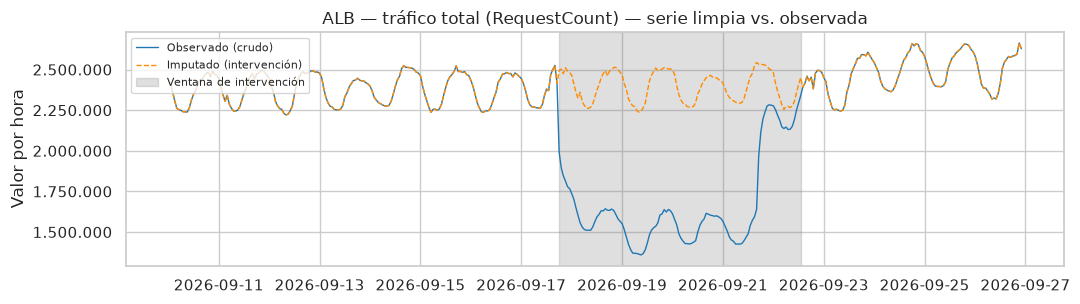

Rango relativo entre días de la semana: 1.80% de la media


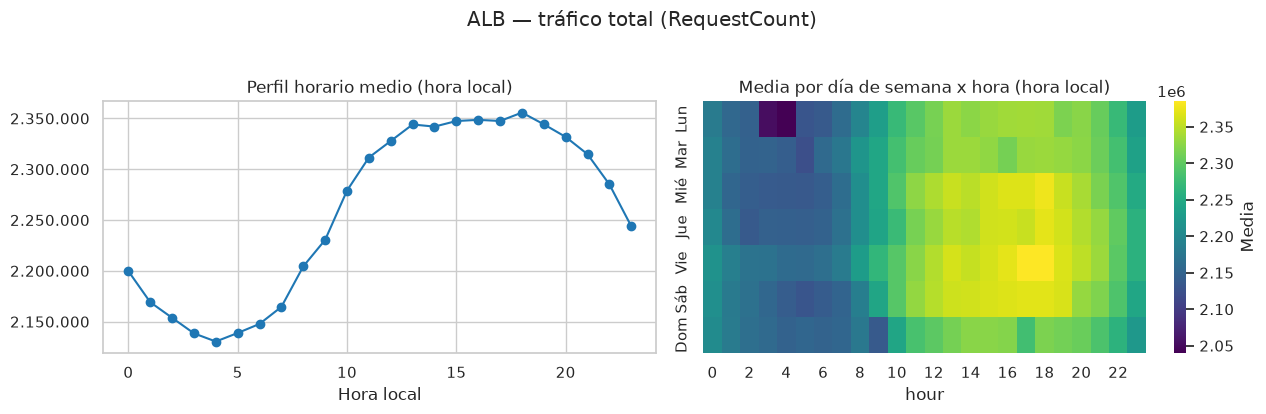

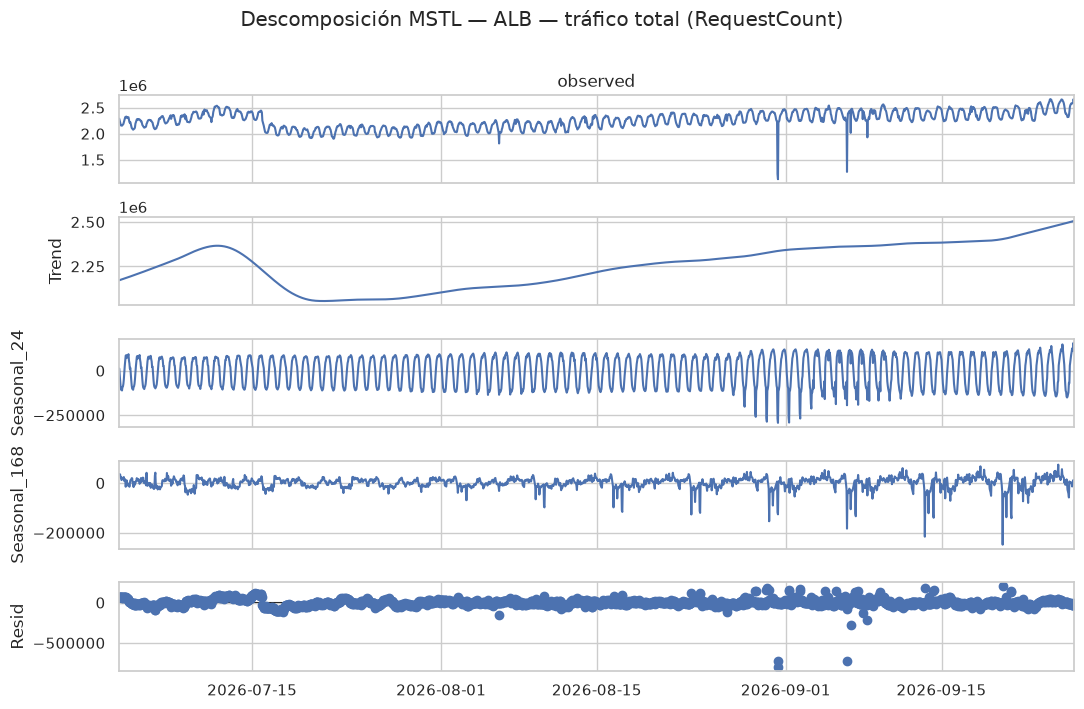

Fuerza estacional 24h = 0.771 | 168h = 0.206 | tendencia = 0.880


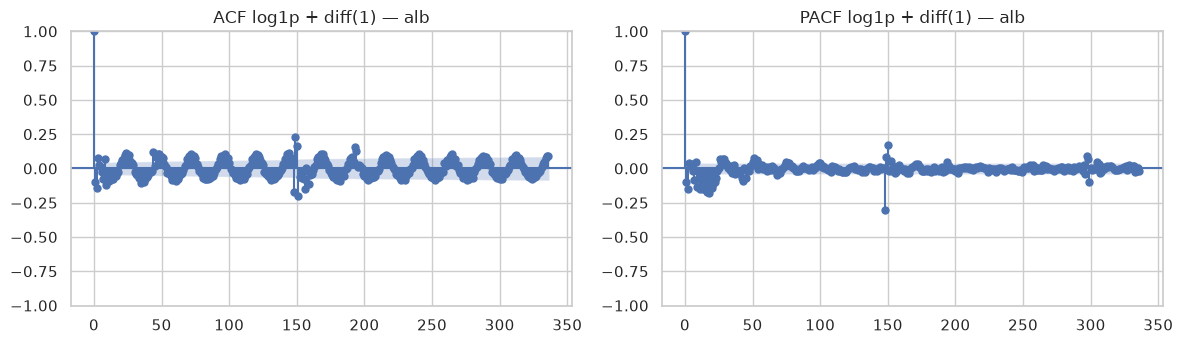

WARNING - (py.warnings._showwarnmsg) - /tmp/ipykernel_448811/3372330054.py:69: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie_, regression="c", nlags="auto")



WARNING - (py.warnings._showwarnmsg) - /tmp/ipykernel_448811/3372330054.py:69: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie_, regression="c", nlags="auto")



            transformación  ADF p-valor  KPSS p-valor
             nivel (log1p)         0.81          0.01
primera diferencia (log1p)         0.00          0.10


In [15]:
eda_alb = resumen_eda("alb")


#### Serie store_service


=== store-service — tráfico por target (RequestCountPerTarget) ===
Serie limpia: 2063 observaciones horarias, 2026-07-03 00:00:00+00:00 -> 2026-09-26 22:00:00+00:00
Horas de intervención imputadas: 116


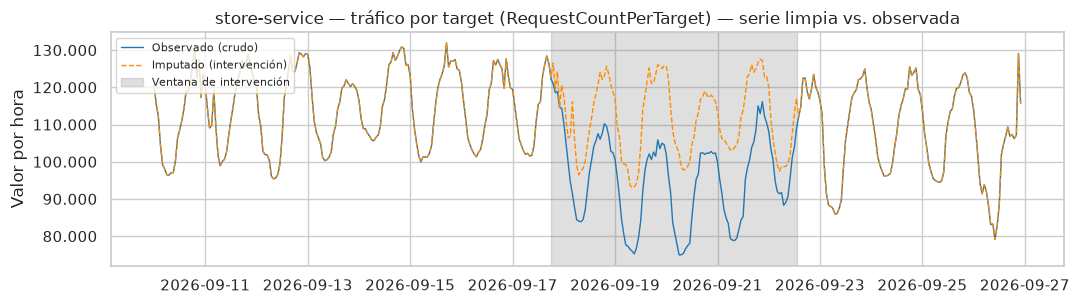

Rango relativo entre días de la semana: 2.88% de la media


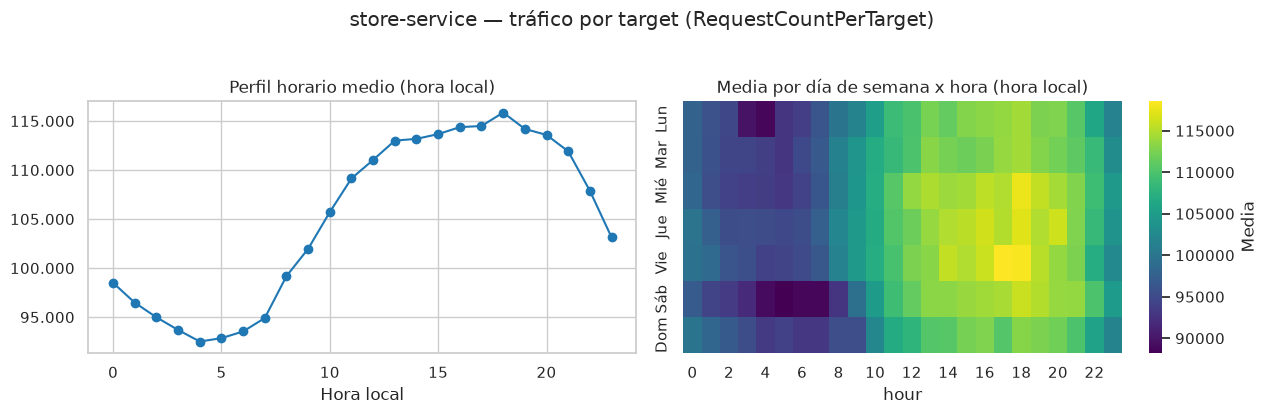

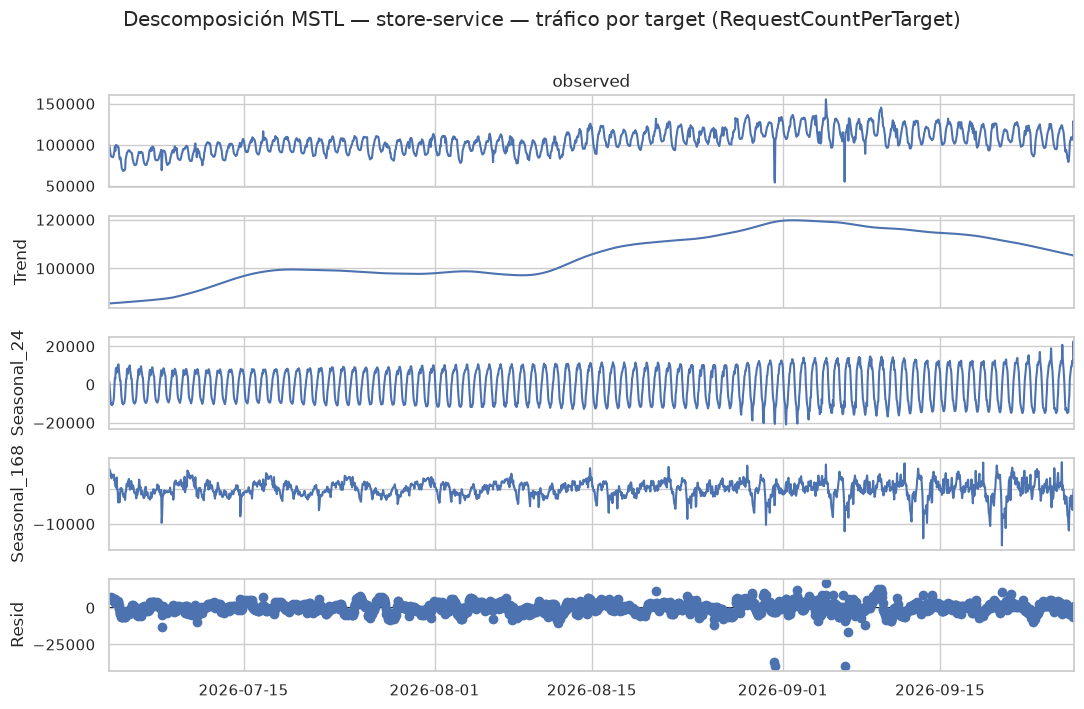

Fuerza estacional 24h = 0.846 | 168h = 0.311 | tendencia = 0.876


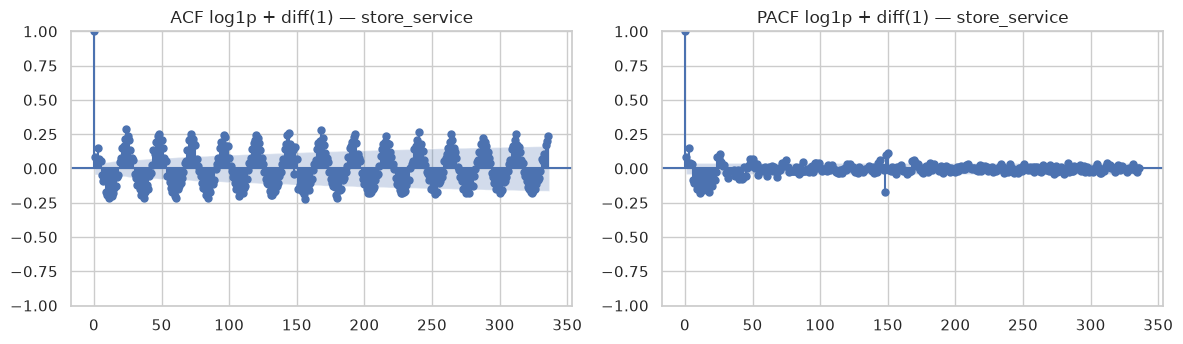

WARNING - (py.warnings._showwarnmsg) - /tmp/ipykernel_448811/3372330054.py:69: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie_, regression="c", nlags="auto")



WARNING - (py.warnings._showwarnmsg) - /tmp/ipykernel_448811/3372330054.py:69: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie_, regression="c", nlags="auto")



            transformación  ADF p-valor  KPSS p-valor
             nivel (log1p)        0.174          0.01
primera diferencia (log1p)        0.000          0.10


In [16]:
eda_store = resumen_eda("store_service")


### 1.2 Feriados argentinos y correlación cruzada ALB vs. store_service

Se compara cada feriado argentino presente en el rango limpio contra el mismo día de la semana, una semana antes, y se calcula la correlación cruzada entre ambas series (diferenciadas en `log1p`) para lags de -24 a 24 h.


In [17]:
years = range(eda_alb["limpia"].index.tz_convert(LOCAL_TZ).year.min(),
              eda_alb["limpia"].index.tz_convert(LOCAL_TZ).year.max() + 1)
feriados_ar = holidays_pkg.Argentina(years=years)
rango_local = eda_alb["limpia"].index.tz_convert(LOCAL_TZ)
feriados_en_rango = sorted({d for d in feriados_ar if rango_local.date.min() <= d <= rango_local.date.max()})
print("Feriados argentinos en el rango de la serie limpia:", feriados_en_rango)

filas_feriados = []
for nombre_serie, resultado in [("alb", eda_alb), ("store_service", eda_store)]:
    idx_local = resultado["limpia"].index.tz_convert(LOCAL_TZ)
    for feriado in feriados_en_rango:
        mascara_dia = idx_local.date == feriado
        mascara_semana_previa = idx_local.date == (feriado - pd.Timedelta(days=7))
        if mascara_dia.sum() == 0 or mascara_semana_previa.sum() == 0:
            continue
        media_feriado = resultado["limpia"][mascara_dia].mean()
        media_previa = resultado["limpia"][mascara_semana_previa].mean()
        filas_feriados.append({"serie": nombre_serie, "feriado": feriado, "ratio_%": 100 * media_feriado / media_previa})
pd.DataFrame(filas_feriados)


Feriados argentinos en el rango de la serie limpia: [datetime.date(2026, 7, 9), datetime.date(2026, 7, 10), datetime.date(2026, 8, 17)]


,serie,feriado,ratio_%
0,alb,2026-07-09,102.535039
1,alb,2026-07-10,105.957017
2,alb,2026-08-17,104.289464
3,store_service,2026-07-09,91.807309
4,store_service,2026-07-10,97.971873
5,store_service,2026-08-17,112.539821


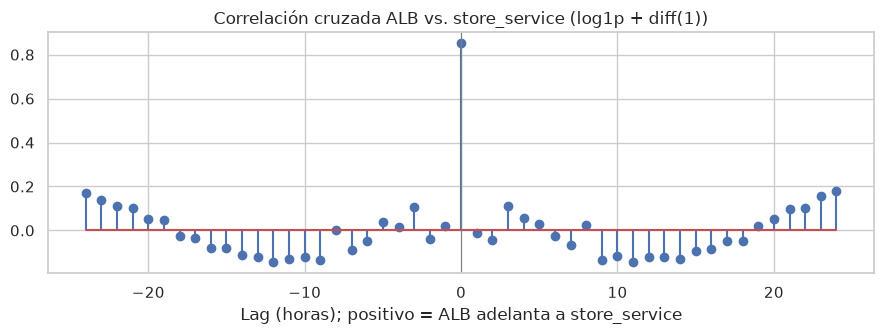

Lag con correlación máxima en valor absoluto: 0 h, corr = 0.852


In [18]:
alb_diff = np.log1p(eda_alb["limpia"]).diff().dropna()
store_diff = np.log1p(eda_store["limpia"]).diff().dropna()
idx_comun = alb_diff.index.intersection(store_diff.index)
alb_diff, store_diff = alb_diff.loc[idx_comun], store_diff.loc[idx_comun]

lag_max = 24
lags = range(-lag_max, lag_max + 1)
valores_ccf = []
for lag in lags:
    if lag >= 0:
        x, y = alb_diff.iloc[: len(alb_diff) - lag if lag else None], store_diff.shift(-lag).dropna()
    else:
        x, y = alb_diff.shift(lag).dropna(), store_diff
    idx = x.index.intersection(y.index)
    valores_ccf.append(np.corrcoef(x.loc[idx], y.loc[idx])[0, 1])
serie_ccf = pd.Series(valores_ccf, index=list(lags))
mejor_lag = serie_ccf.abs().idxmax()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.stem(serie_ccf.index, serie_ccf.values)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_title("Correlación cruzada ALB vs. store_service (log1p + diff(1))")
ax.set_xlabel("Lag (horas); positivo = ALB adelanta a store_service")
plt.tight_layout()
plt.show()
print(f"Lag con correlación máxima en valor absoluto: {mejor_lag} h, corr = {serie_ccf[mejor_lag]:.3f}")


### Conclusiones de la fase 01

El ciclo diario (periodo 24) es el componente estacional dominante en ambas series (fuerza de estacionalidad de Wang-Smith-Hyndman muy por encima del componente semanal, periodo 168) y la estacionalidad semanal es prácticamente nula después del *go-live* del balanceador (medias por día de semana difieren menos del 3% de la media en ambas series). `log1p` + primera diferencia alcanza estacionariedad para las dos series según ADF y KPSS. La correlación cruzada ALB/store_service alcanza su máximo en el lag 0 ($r \approx 0.85$), es decir, las dos series se mueven de forma contemporánea y ALB no es un indicador adelantado de store_service a resolución horaria. Solo hay tres feriados argentinos en el rango limpio, con efecto mixto (no una reducción uniforme) -- insuficiente evidencia para una corrección específica; se deja como variable de calendario (`is_holiday`) para los modelos de las fases siguientes. Estas conclusiones son la base de las decisiones de protocolo de la fase 02: estacional-naive con `m=24` (no `m=168`) como referencia principal y como base de MASE.


## Fase 02 — Protocolo de evaluación y modelos base (*baselines*)

Antes de modelos más sofisticados (fases 03 a 06), se corren métodos simples y clásicos como piso de comparación: si un modelo complejo no le gana a estos baselines, esa complejidad no se justifica. Protocolo (fijado en `evaluation.py`, Sección 1): un solo corte train/validación/test -- no *backtesting* expansivo, por presupuesto de tiempo (ver `status/02-evaluation-baselines.md`) -- con validación de 48 h terminando justo antes de la intervención conocida, y test de 105 h posteriores al *rollback*. Métricas: MAE, RMSE, MAPE y MASE (`m=24`, dado que la estacionalidad semanal es negligible, fase 01). Familias: `naive` (`naive`, `seasonal_naive_m24`, `drift`, `average`), el refit de las especificaciones SARIMA de TP1, y tres extras clásicos (Holt-Winters, MSTL+ARIMA, AutoARIMA).


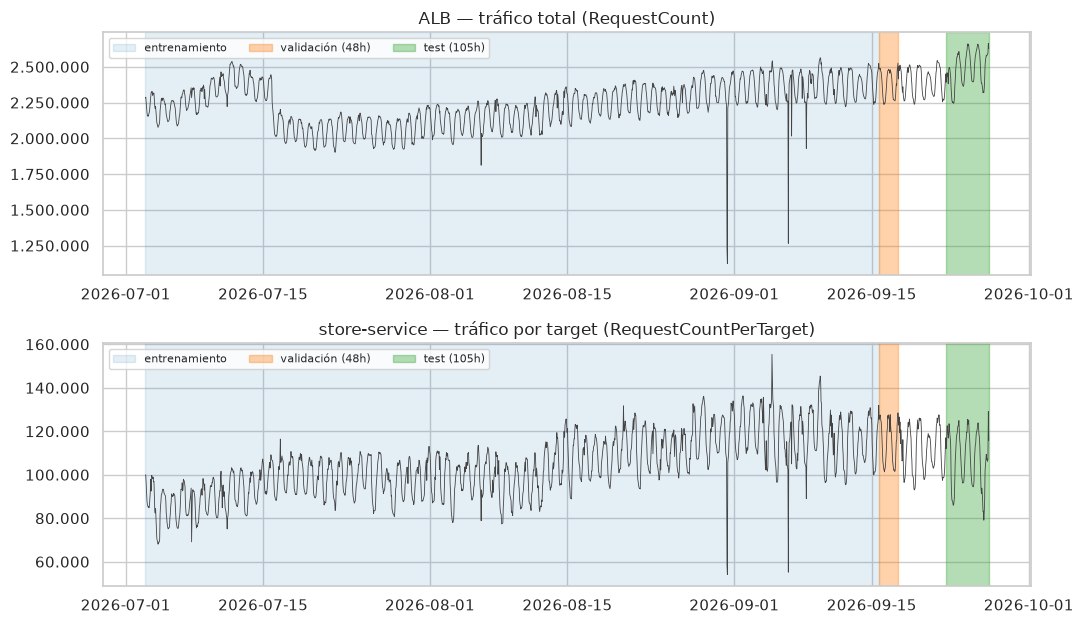

In [19]:
SERIES = {nombre: (eda_alb if nombre == "alb" else eda_store)["limpia"] for nombre in SERIES_NAMES}

fig, axes = plt.subplots(len(SERIES_NAMES), 1, figsize=(11, 3.2 * len(SERIES_NAMES)))
for ax, nombre_serie in zip(axes, SERIES_NAMES):
    s = SERIES[nombre_serie]
    train, val, test = split(s)
    ax.plot(s.index, s.values, linewidth=0.6, color="#444444")
    ax.axvspan(train.index.min(), train.index.max(), color="#1f77b4", alpha=0.12, label="entrenamiento")
    ax.axvspan(val.index.min(), val.index.max(), color="#ff7f0e", alpha=0.35, label="validación (48h)")
    ax.axvspan(test.index.min(), test.index.max(), color="#2ca02c", alpha=0.35, label="test (105h)")
    ax.set_title(SERIES_LABELS[nombre_serie])
    miles(ax)
    ax.legend(loc="upper left", fontsize=8, ncol=3)
plt.tight_layout()
plt.show()


### 2.1 Serie ALB y 2.2 Serie store_service (protocolo compartido)

El bloque de entrenamiento de abajo corre, para las dos series a la vez (mismo patrón que `notebooks/02_evaluation_baselines.ipynb`), la familia *naive* completa, el refit SARIMA de TP1 y los tres extras clásicos -- solo si `REENTRENAR = True`. Con `REENTRENAR = False` se reutiliza `results/02_baselines.csv` tal cual quedó de la última corrida real.


In [20]:
resultados_02 = ResultsTable()
if REENTRENAR:
    for nombre_serie in SERIES_NAMES:
        for nombre_modelo, fit_fn in NAIVE_MODELS.items():
            evaluate(fit_fn, model=nombre_modelo, family="naive", series_name=nombre_serie,
                      series=SERIES[nombre_serie], table=resultados_02)
        orden, orden_estacional = SARIMA_SPECS[nombre_serie]
        evaluate(make_sarima_fit(orden, orden_estacional), model=f"SARIMA{orden}x{orden_estacional}",
                  family="SARIMA (TP1 refit)", series_name=nombre_serie, series=SERIES[nombre_serie],
                  table=resultados_02)
        for nombre_modelo in ["holt_winters", "mstl_arima", "auto_arima"]:
            evaluate(CLASSICAL_MODELS[nombre_modelo], model=nombre_modelo, family="classical",
                      series_name=nombre_serie, series=SERIES[nombre_serie], table=resultados_02)
    tabla_02 = resultados_02.to_frame()
    tabla_02.to_csv(RUTA_RESULTADOS / "02_baselines.csv", index=False)
    print(f"REENTRENAR=True: se recalcularon y sobrescribieron {len(tabla_02)} filas en 02_baselines.csv")
else:
    print("REENTRENAR=False: se reutiliza results/02_baselines.csv, no se reentrena nada.")

tabla_02 = pd.read_csv(RUTA_RESULTADOS / "02_baselines.csv")
tabla_val_02 = tabla_02[tabla_02["split"] == "val"].sort_values(["series", "MAE"])
tabla_test_02 = tabla_02[tabla_02["split"] == "test"].sort_values(["series", "MAE"])
tabla_val_02


REENTRENAR=False: se reutiliza results/02_baselines.csv, no se reentrena nada.


,model,family,series,split,MAE,RMSE,MAPE_%,MASE,fit_time_s
24,auto_arima,classical,alb,val,18807.501329,25924.315981,0.796346,0.475076,97.518074
2,seasonal_naive_m24,naive,alb,val,19369.020833,26930.144566,0.802939,0.489260,0.000018
22,mstl_arima,classical,alb,val,23468.835238,28937.841532,0.984756,0.592821,0.469051
20,holt_winters,classical,alb,val,31604.807832,37185.054440,1.347190,0.798335,0.152936
16,"SARIMA(1, 1, 1)x(1, 1, 1, 24)",SARIMA (TP1 refit),alb,val,36524.567806,41805.967305,1.541340,0.922608,2.635246
0,naive,naive,alb,val,140474.229167,167933.272603,6.055218,3.548369,0.000013
4,drift,naive,alb,val,143670.973311,170774.174777,6.190009,3.629118,0.000009
6,average,naive,alb,val,149950.947255,176014.300477,6.151106,3.787750,0.000030
10,seasonal_naive_m24,naive,store_service,val,2281.852431,3009.785690,1.936704,0.480171,0.000013
30,auto_arima,classical,store_service,val,2525.880897,2976.935579,2.201689,0.531522,79.468352


### 2.3 ¿Quién gana? Ranking de validación y control de realidad en test

El gráfico de barras usa el MAPE de validación (la línea punteada marca `seasonal_naive_m24`, el piso a superar); el segundo gráfico reentrena el ganador de validación de cada serie sobre `train_and_val` y pronostica la ventana de test real (el refit más lento posible aquí es `auto_arima`, ~1 minuto; el resto es prácticamente instantáneo -- corre siempre, con cualquier valor de `REENTRENAR`, porque es la única forma de mostrar el pronóstico real contra el dato observado).


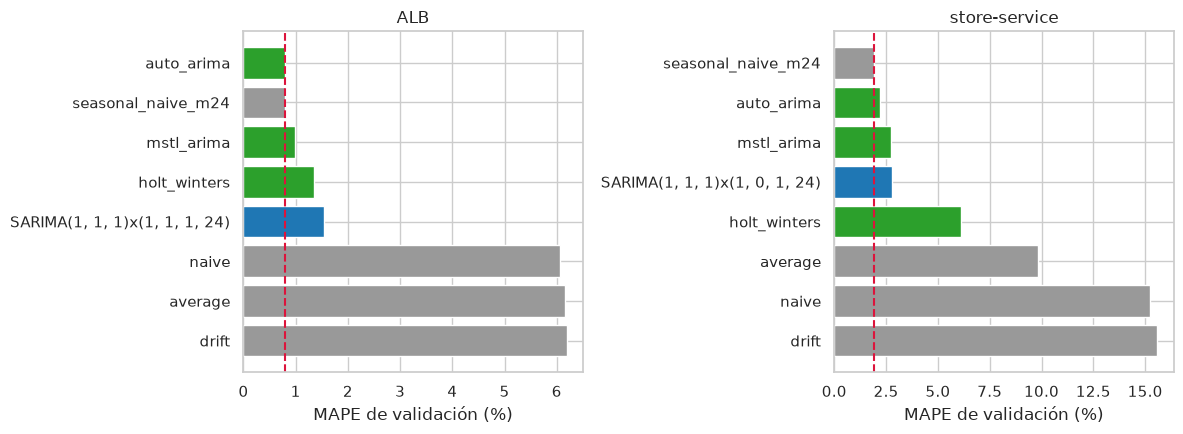

In [21]:
fig, axes = plt.subplots(1, len(SERIES_NAMES), figsize=(12, 4.5))
paleta_02 = {"naive": "#999999", "SARIMA (TP1 refit)": "#1f77b4", "classical": "#2ca02c"}
for ax, nombre_serie in zip(axes, SERIES_NAMES):
    sub = tabla_val_02[tabla_val_02["series"] == nombre_serie].sort_values("MAPE_%")
    colores = [paleta_02[f] for f in sub["family"]]
    ax.barh(sub["model"], sub["MAPE_%"], color=colores)
    mape_naive = sub.loc[sub["model"] == "seasonal_naive_m24", "MAPE_%"].iloc[0]
    ax.axvline(mape_naive, color="crimson", linestyle="--")
    ax.set_title(SERIES_LABELS[nombre_serie].split(" — ")[0])
    ax.set_xlabel("MAPE de validación (%)")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()


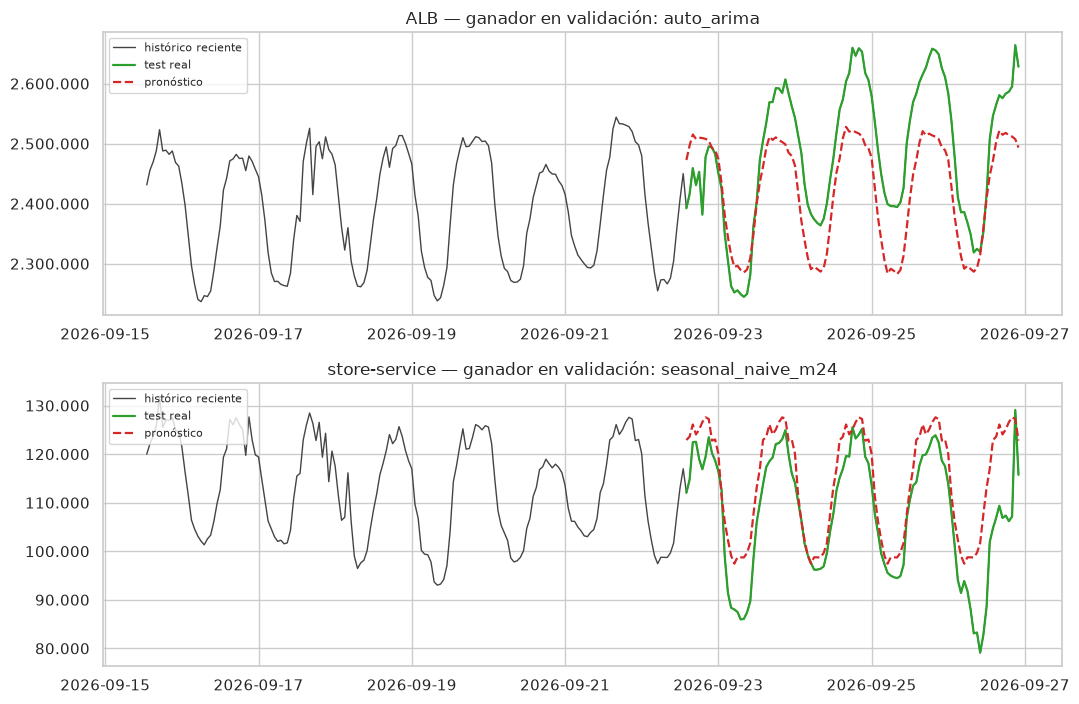

In [22]:
TODOS_LOS_AJUSTES_02 = dict(NAIVE_MODELS)
TODOS_LOS_AJUSTES_02.update(CLASSICAL_MODELS)


def ajuste_para_02(nombre_modelo, nombre_serie):
    if nombre_modelo in TODOS_LOS_AJUSTES_02:
        return TODOS_LOS_AJUSTES_02[nombre_modelo]
    orden, orden_estacional = SARIMA_SPECS[nombre_serie]
    return make_sarima_fit(orden, orden_estacional)


fig, axes = plt.subplots(len(SERIES_NAMES), 1, figsize=(11, 3.6 * len(SERIES_NAMES)))
ganadores_02 = {}
for ax, nombre_serie in zip(axes, SERIES_NAMES):
    ganador = tabla_val_02[tabla_val_02["series"] == nombre_serie].iloc[0]["model"]
    ganadores_02[nombre_serie] = ganador
    s = SERIES[nombre_serie]
    train, val, test = split(s)
    ajuste_completo = train_and_val(s)
    predictor = ajuste_para_02(ganador, nombre_serie)(ajuste_completo)
    pred_test = predictor(len(test))
    reciente = s.loc[ajuste_completo.index.max() - pd.Timedelta(hours=24 * 7):]
    ax.plot(reciente.index, reciente.values, color="#444444", linewidth=1, label="histórico reciente")
    ax.plot(test.index, test.values, color="#2ca02c", linewidth=1.6, label="test real")
    ax.plot(test.index, pred_test, color="#d62728", linewidth=1.6, linestyle="--", label="pronóstico")
    ax.set_title(f"{SERIES_LABELS[nombre_serie].split(' — ')[0]} — ganador en validación: {ganador}")
    miles(ax)
    ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


### Conclusiones de la fase 02

En **ALB**, `auto_arima` (MASE val 0.475) y `seasonal_naive_m24` (MASE val 0.489) quedan prácticamente empatados en validación, y en test se invierte: el refit SARIMA de TP1 toma la delantera (MAPE 2.42%) aunque había quedado detrás en validación. En **store_service**, `seasonal_naive_m24` gana claramente en validación (MASE 0.480) y sigue siendo fuerte en test. `seasonal_naive_m24` es una referencia genuinamente sólida en las dos series (MASE < 1 en ambos splits): cualquier modelo de las fases 03-06 que no le gane no está justificando su complejidad adicional. La divergencia entre el ranking de validación y el de test (especialmente en ALB) es la primera evidencia reportable del riesgo aceptado al usar un único corte de validación en vez de *backtesting* expansivo -- se documenta, no se oculta, y vuelve a aparecer en cada fase siguiente.


## Fase 03 — Modelos de Machine Learning

*Forecasters* de árboles y lineales (LightGBM, XGBoost, CatBoost, RandomForest, Ridge) sobre lags (1-24, 48, 168, 336) y variables de calendario, con `skforecast` `ForecasterRecursive`. Secuencia fija (ver `status/03-ml-models.md`, "Sequencing"): recursivo (5 modelos, hiperparámetros por defecto) -> ranking de validación -> estrategia *direct* solo para el #1 -> Optuna solo para el top-3 por MAE default -> *stacking* del top-3 tuneado -> ganador único por serie -> SHAP solo del ganador. Vara a vencer: `seasonal_naive_m24` (MASE < 1 en validación, fase 02).


In [23]:
import shap
from sklearn.linear_model import Ridge as _RidgeParaSHAP


def ejecutar_pipeline_ml(nombre_serie: str) -> dict:
    print(f"=== {nombre_serie} ===")
    series = SERIES[nombre_serie]
    tabla = ResultsTable()

    mase_naive_val = tabla_02.loc[
        (tabla_02["series"] == nombre_serie) & (tabla_02["model"] == "seasonal_naive_m24") & (tabla_02["split"] == "val"),
        "MASE",
    ].iloc[0]

    for nombre, ajuste in RECURSIVE_MODELS.items():
        evaluate(ajuste, model=nombre, family="ML", series_name=nombre_serie, series=series, table=tabla)

    df = tabla.to_frame()
    ranking_val = df[df["split"] == "val"][["model", "MAE", "MASE"]].sort_values("MAE").reset_index(drop=True)
    mejor_recursivo = ranking_val.iloc[0]["model"]
    candidatos_tuneo = ranking_val.head(3)["model"].tolist()

    evaluate_direct(default_builder(mejor_recursivo), model=f"{mejor_recursivo}_direct",
                     series_name=nombre_serie, series=series, table=tabla)

    parametros_tuneados: dict[str, dict] = {}
    nombres_tuneados = []
    for nombre in candidatos_tuneo:
        mejores_parametros = tune_hyperparameters(nombre, series, n_trials=20, timeout_s=120)
        parametros_tuneados[nombre] = mejores_parametros
        evaluate(make_tuned_fit(nombre, mejores_parametros), model=f"{nombre}_tuned", family="ML",
                  series_name=nombre_serie, series=series, table=tabla)
        nombres_tuneados.append(f"{nombre}_tuned")

    df = tabla.to_frame()
    val_tuneado = df[(df["split"] == "val") & (df["model"].isin(nombres_tuneados))][["model", "MAE"]].sort_values("MAE")
    top3 = [m.replace("_tuned", "") for m in val_tuneado.head(3)["model"].tolist()]
    if len(top3) >= 2:
        estimadores = []
        for nombre in top3:
            clase_est, kwargs_fijos, _ = MODEL_SPECS[nombre]
            estimadores.append((nombre, clase_est(**kwargs_fijos, **parametros_tuneados[nombre])))
        evaluate(make_stacking_fit(estimadores, cv=3), model="stacking_top3", family="ML",
                  series_name=nombre_serie, series=series, table=tabla)

    df = tabla.to_frame()
    ranking_general = df[df["split"] == "val"][["model", "MAE", "MASE"]].sort_values("MAE").reset_index(drop=True)
    ganador = ranking_general.iloc[0]["model"]
    print(f"ganador ({nombre_serie}): {ganador} | naive a vencer: {mase_naive_val:.3f}")
    return {"table": df, "winner": ganador, "tuned_params": parametros_tuneados, "series": series}


### 3.1 Serie ALB y 3.2 Serie store_service

Con `REENTRENAR = False` se reutiliza `results/03_ml.csv`; los hiperparámetros tuneados por Optuna solo existen en memoria si `REENTRENAR = True` (no se persisten en el CSV), así que la figura SHAP de la siguiente subsección se recalcula únicamente en ese caso -- de lo contrario se muestra la figura ya generada por `notebooks/03_ml_models.ipynb`.


In [24]:
resultados_03 = {}
if REENTRENAR:
    for nombre_serie in SERIES_NAMES:
        resultados_03[nombre_serie] = ejecutar_pipeline_ml(nombre_serie)
    tabla_03 = pd.concat([resultados_03[s]["table"] for s in SERIES_NAMES], ignore_index=True)
    tabla_03.to_csv(RUTA_RESULTADOS / "03_ml.csv", index=False)
    print(f"REENTRENAR=True: se recalcularon y sobrescribieron {len(tabla_03)} filas en 03_ml.csv")
else:
    print("REENTRENAR=False: se reutiliza results/03_ml.csv, no se reentrena nada.")

tabla_03 = pd.read_csv(RUTA_RESULTADOS / "03_ml.csv")
tabla_val_03 = tabla_03[tabla_03["split"] == "val"].sort_values(["series", "MAE"])
ganadores_03 = {
    nombre_serie: tabla_val_03[tabla_val_03["series"] == nombre_serie].iloc[0]["model"]
    for nombre_serie in SERIES_NAMES
}
print("Ganador por serie (menor MAE de validación):", ganadores_03)


REENTRENAR=False: se reutiliza results/03_ml.csv, no se reentrena nada.
Ganador por serie (menor MAE de validación): {'alb': 'catboost_tuned', 'store_service': 'lightgbm_tuned'}


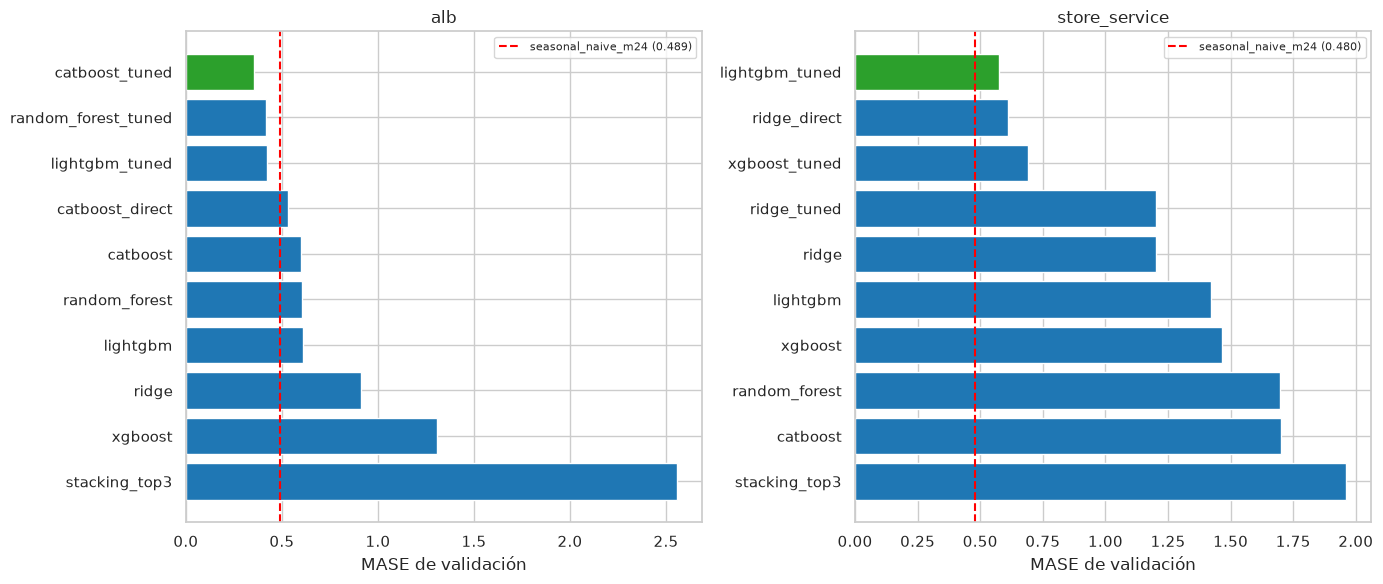

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, nombre_serie in zip(axes, SERIES_NAMES):
    ranking = tabla_val_03[tabla_val_03["series"] == nombre_serie].sort_values("MASE", ascending=False)
    mase_naive = tabla_02.loc[(tabla_02["series"] == nombre_serie) & (tabla_02["model"] == "seasonal_naive_m24") & (tabla_02["split"] == "val"), "MASE"].iloc[0]
    colores = ["#2ca02c" if m == ganadores_03[nombre_serie] else "#1f77b4" for m in ranking["model"]]
    ax.barh(ranking["model"], ranking["MASE"], color=colores)
    ax.axvline(mase_naive, color="red", linestyle="--", label=f"seasonal_naive_m24 ({mase_naive:.3f})")
    ax.set_xlabel("MASE de validación")
    ax.set_title(nombre_serie)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 3.3 SHAP del ganador único por serie (solo el ganador, por costo)


REENTRENAR=False: se muestran las figuras SHAP ya generadas por notebooks/03_ml_models.ipynb


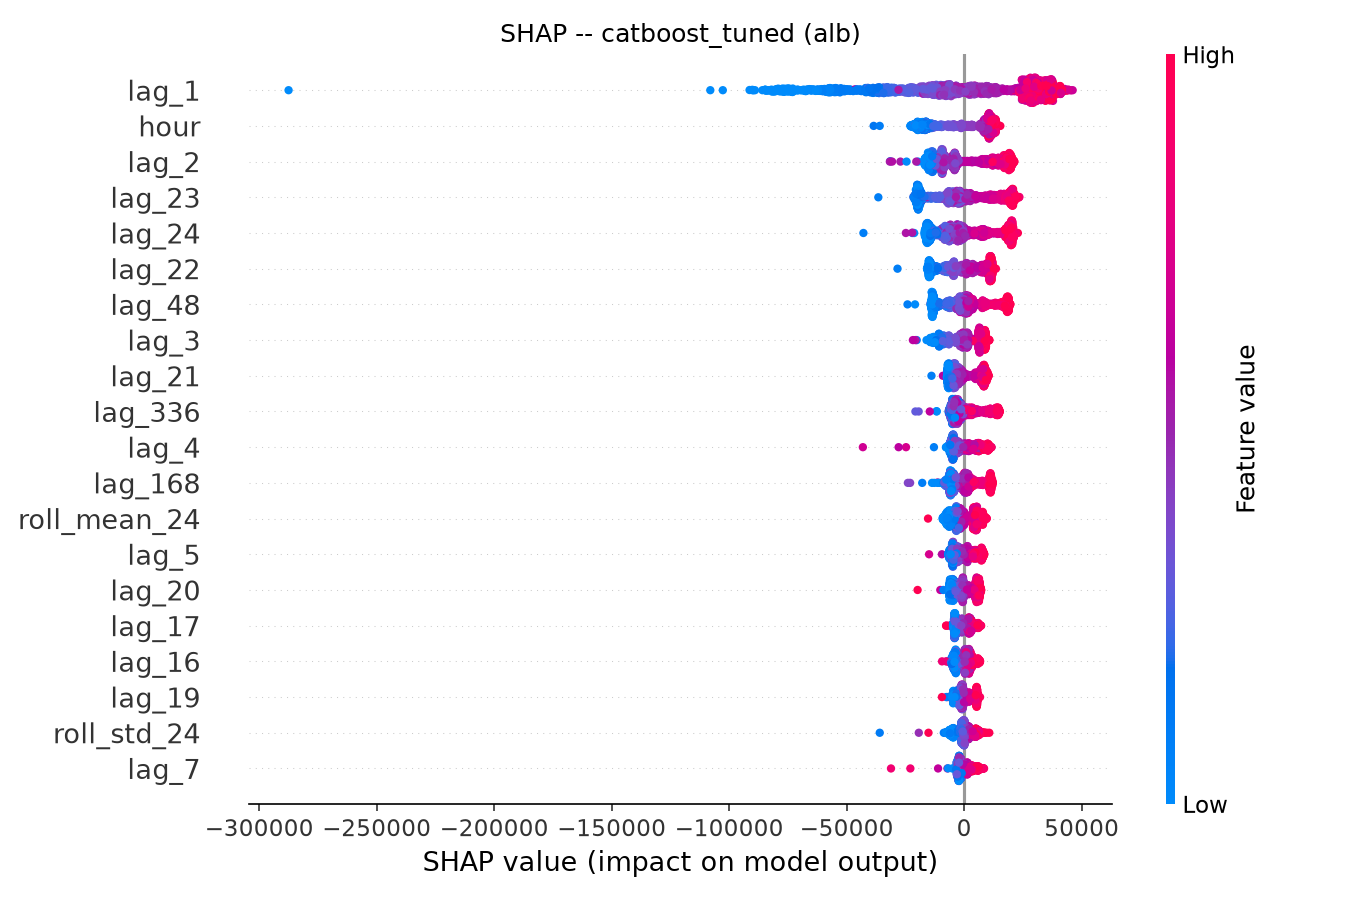

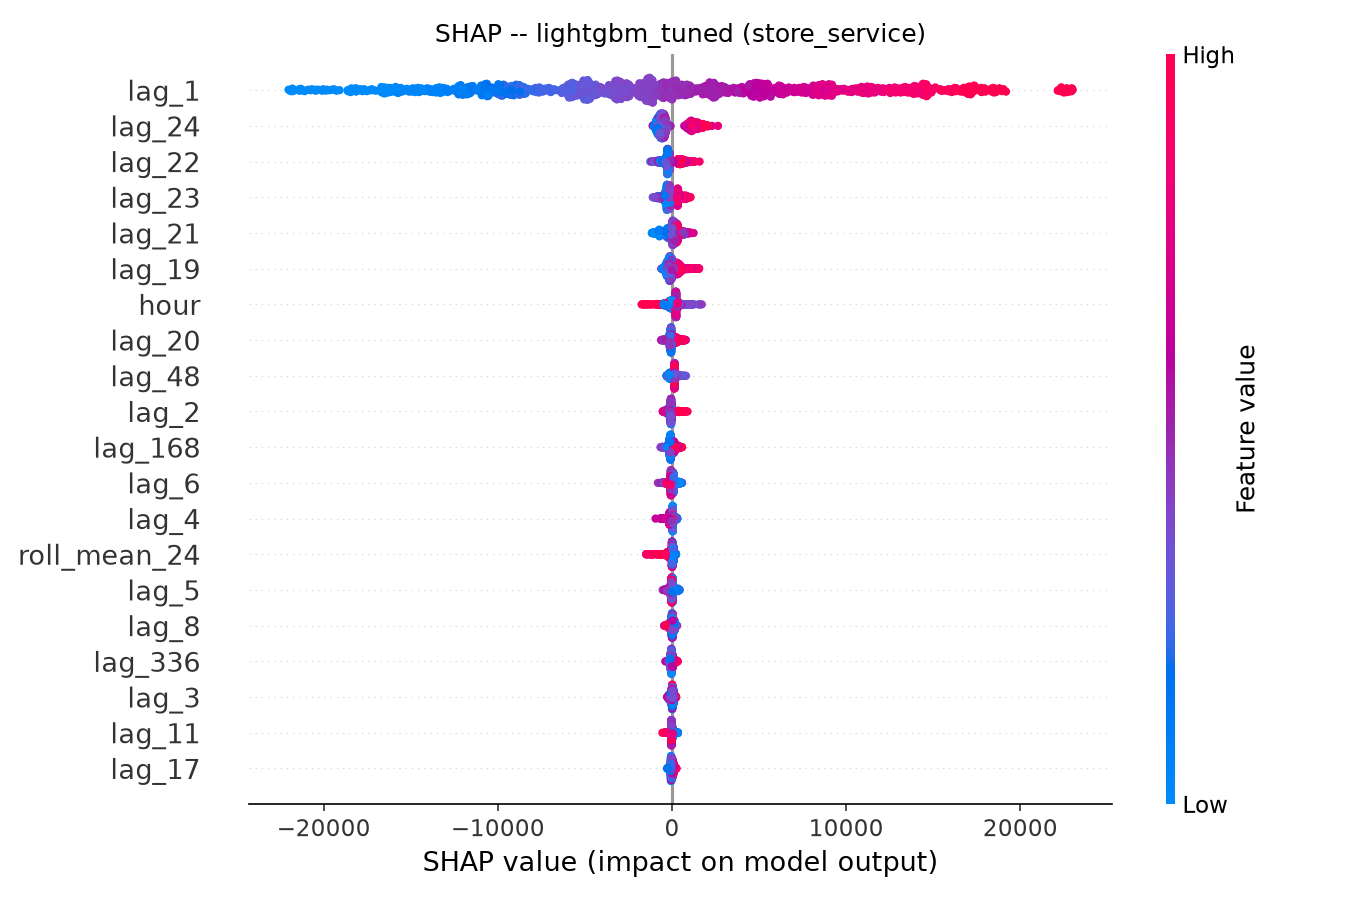

In [26]:
from IPython.display import Image, display

if REENTRENAR:
    for nombre_serie in SERIES_NAMES:
        ganador = resultados_03[nombre_serie]["winner"]
        params_tuneados = resultados_03[nombre_serie]["tuned_params"]
        series = resultados_03[nombre_serie]["series"]
        nombre_base = ganador.replace("_tuned", "").replace("_direct", "")
        if nombre_base not in MODEL_SPECS:
            print(f"SHAP omitido para {nombre_serie}: el ganador ({ganador}) es un stacking, sin un único estimador base")
            continue
        train, val, test = split(series)
        entrenamiento_completo = pd.concat([train, val])
        if nombre_base in params_tuneados:
            clase_est, kwargs_fijos, _ = MODEL_SPECS[nombre_base]
            estimador = clase_est(**kwargs_fijos, **params_tuneados[nombre_base])
        else:
            estimador = default_builder(nombre_base)()
        X_shap, y_shap = training_matrix(nombre_base, estimador, entrenamiento_completo)
        estimador.fit(X_shap, y_shap)
        explainer = shap.LinearExplainer(estimador, X_shap) if isinstance(estimador, _RidgeParaSHAP) else shap.TreeExplainer(estimador)
        valores_shap = explainer.shap_values(X_shap)
        plt.figure()
        shap.summary_plot(valores_shap, X_shap, show=False, plot_size=(9, 6))
        plt.title(f"SHAP -- {ganador} ({nombre_serie})")
        plt.tight_layout()
        plt.show()
else:
    print("REENTRENAR=False: se muestran las figuras SHAP ya generadas por notebooks/03_ml_models.ipynb")
    for nombre_serie in SERIES_NAMES:
        display(Image(filename=str(RUTA_FIGURAS_INFORME / f"03_shap_{nombre_serie}.png")))


### Conclusiones de la fase 03

En **ALB**, `catboost_tuned` gana en validación (MASE 0.353, le gana a la naive 0.489) pero pierde en test (MASE 2.313) -- la misma divergencia validación/test que ya documentó la fase 02, no un error. En **store_service**, `lightgbm_tuned` gana en validación (MASE 0.573) pero **no** logra bajar de la naive (0.480) en ningún split -- ningún modelo ML le ganó a la estacional-naive en esta serie. El *stacking* (`stacking_top3`) fue el peor modelo de toda la fase en ambas series: combinar tres modelos tuneados vía un meta-modelo lineal no ayudó en un pronóstico recursivo de 48 pasos. SHAP confirma que `lag_1`, `lag_2`, `lag_23/24` y `lag_48` dominan la importancia de *features*, consistente con la estacionalidad diaria ya cuantificada en la fase 01.


## Fase 04 — Modelos de Deep Learning

Seis arquitecturas de redes (LSTM, N-BEATS, N-HiTS, TCN, TiDE, TFT, con `darts`), escalado `log1p` + `Scaler`, covariables de calendario cíclicas y 2 semillas fijas (42, 43). **Regla de fuga de datos**: el *early stopping* nunca mira la ventana de selección de 48 h -- monitorea `val_loss` en las 168 h inmediatamente anteriores, registra la mejor época y el refit de test entrena esa cantidad fija de épocas, sin *early stopping* (ver docstring de `dl_models.py`, Sección 1, y `status/04-dl-models.md`). Con `REENTRENAR = True` esto es la fase más costosa del notebook: 6 arquitecturas x 2 semillas x 2 series x 2 ajustes (validación + test) ~28 minutos de ajuste medidos (~31 min de notebook, ver Evidencia en `status/04-dl-models.md`).


In [27]:
def ejecutar_pipeline_dl(nombre_serie: str) -> dict:
    print(f"=== {nombre_serie} ===")
    series = SERIES[nombre_serie]
    tabla_semillas = ResultsTable()
    for nombre_arquitectura in ARCHITECTURES:
        for semilla in SEEDS:
            ajuste = make_fit(nombre_arquitectura, semilla)
            evaluate(ajuste, model=f"{nombre_arquitectura}_seed{semilla}", family="DL",
                      series_name=nombre_serie, series=series, table=tabla_semillas)
    df_semillas = tabla_semillas.to_frame()
    df_semillas["architecture"] = df_semillas["model"].str.extract(r"^(.*)_seed\d+$")
    df_semillas["seed"] = df_semillas["model"].str.extract(r"_seed(\d+)$").astype(int)
    filas_principales = []
    for nombre_arquitectura in ARCHITECTURES:
        for split_ in ["val", "test"]:
            sub = df_semillas[(df_semillas["architecture"] == nombre_arquitectura) & (df_semillas["split"] == split_)]
            filas_principales.append({
                "model": nombre_arquitectura, "family": "DL", "series": nombre_serie, "split": split_,
                "MAE": sub["MAE"].mean(), "RMSE": sub["RMSE"].mean(), "MAPE_%": sub["MAPE_%"].mean(),
                "MASE": sub["MASE"].mean(), "fit_time_s": sub["fit_time_s"].sum(),
            })
    return {"series": series, "seeds_df": df_semillas, "main_df": pd.DataFrame(filas_principales)}


### 4.1 Serie ALB y 4.2 Serie store_service

Con `REENTRENAR = False` se reutilizan `results/04_dl.csv` (agregado por semilla) y `results/04_dl_seeds.csv` (por semilla) tal como quedaron de la última corrida real.


In [28]:
if REENTRENAR:
    resultados_04 = {nombre_serie: ejecutar_pipeline_dl(nombre_serie) for nombre_serie in SERIES_NAMES}
    seeds_04 = pd.concat([resultados_04[s]["seeds_df"] for s in SERIES_NAMES], ignore_index=True)
    seeds_04.to_csv(RUTA_RESULTADOS / "04_dl_seeds.csv", index=False)
    tabla_04 = pd.concat([resultados_04[s]["main_df"] for s in SERIES_NAMES], ignore_index=True)
    tabla_04.to_csv(RUTA_RESULTADOS / "04_dl.csv", index=False)
    print(f"REENTRENAR=True: se recalcularon y sobrescribieron 04_dl.csv ({len(tabla_04)} filas) y 04_dl_seeds.csv ({len(seeds_04)} filas)")
else:
    print("REENTRENAR=False: se reutilizan results/04_dl.csv y results/04_dl_seeds.csv, no se reentrena nada.")

tabla_04 = pd.read_csv(RUTA_RESULTADOS / "04_dl.csv")
seeds_04 = pd.read_csv(RUTA_RESULTADOS / "04_dl_seeds.csv")
tabla_val_04 = tabla_04[tabla_04["split"] == "val"].sort_values(["series", "MASE"])
ganadores_04 = {
    nombre_serie: tabla_val_04[tabla_val_04["series"] == nombre_serie].iloc[0]["model"]
    for nombre_serie in SERIES_NAMES
}
print("Mejor arquitectura DL por serie (menor MASE de validación):", ganadores_04)


REENTRENAR=False: se reutilizan results/04_dl.csv y results/04_dl_seeds.csv, no se reentrena nada.
Mejor arquitectura DL por serie (menor MASE de validación): {'alb': 'nhits', 'store_service': 'nbeats'}


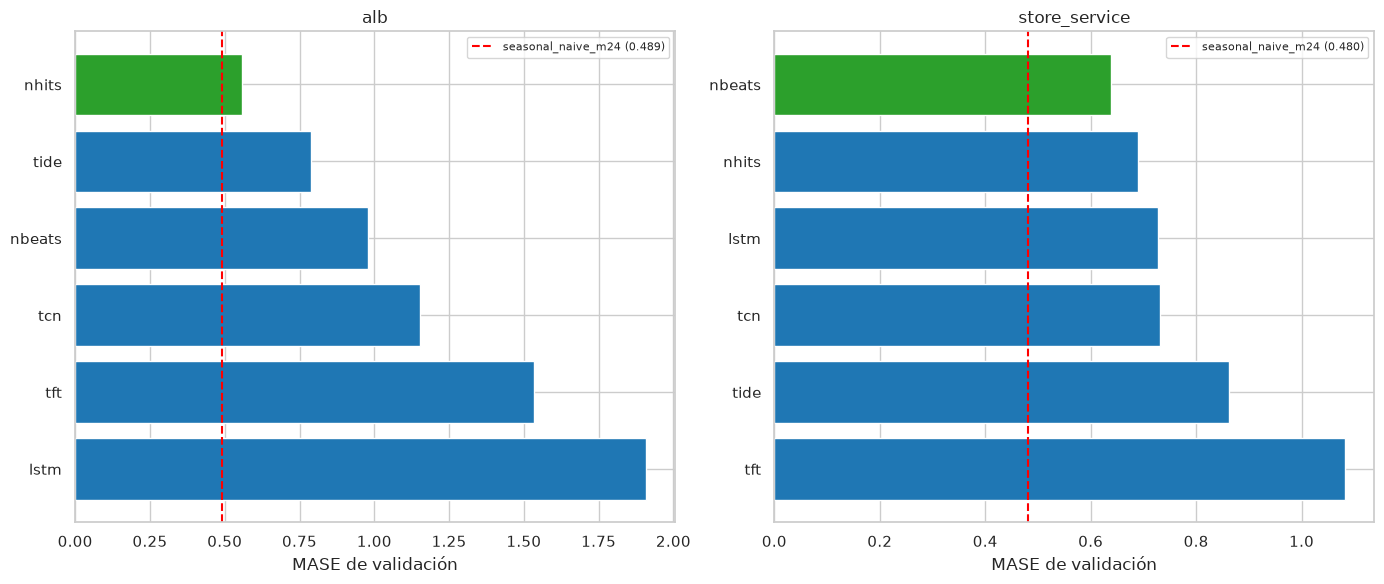

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, nombre_serie in zip(axes, SERIES_NAMES):
    ranking = tabla_val_04[tabla_val_04["series"] == nombre_serie][["model", "MASE"]].sort_values("MASE", ascending=False)
    mase_naive = tabla_02.loc[(tabla_02["series"] == nombre_serie) & (tabla_02["model"] == "seasonal_naive_m24") & (tabla_02["split"] == "val"), "MASE"].iloc[0]
    colores = ["#2ca02c" if m == ganadores_04[nombre_serie] else "#1f77b4" for m in ranking["model"]]
    ax.barh(ranking["model"], ranking["MASE"], color=colores)
    ax.axvline(mase_naive, color="red", linestyle="--", label=f"seasonal_naive_m24 ({mase_naive:.3f})")
    ax.set_xlabel("MASE de validación")
    ax.set_title(nombre_serie)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 4.3 Dispersión entre semillas, mejor época y pronóstico en test

La dispersión de MAE de validación entre las 2 semillas y la mejor época de *early stopping* se leen directamente de `04_dl_seeds.csv`/`04_dl_best_epochs.csv` (no requieren reentrenar). El pronóstico de test sí necesita un ajuste real: se reentrena únicamente la arquitectura ganadora de cada serie (no las seis), un refit de costo bajo -- entre 9 y 30 s por ajuste para cinco de las seis arquitecturas, ver `status/04-dl-models.md` -- así que se corre siempre, con cualquier valor de `REENTRENAR`.


In [30]:
dispersión = seeds_04[seeds_04["split"] == "val"].groupby(["series", "architecture"])["MAE"].agg(["mean", "std"])
dispersión["cv_%"] = 100 * dispersión["std"] / dispersión["mean"]
print(dispersión.round(3).to_string())

epocas_04 = pd.read_csv(RUTA_RESULTADOS / "04_dl_best_epochs.csv")
print(epocas_04.pivot_table(index="architecture", columns=["series", "seed"], values="best_epoch").to_string())


                                 mean        std    cv_%
series        architecture                              
alb           lstm          75584.936   6152.754   8.140
              nbeats        38805.465  18985.351  48.924
              nhits         22021.712   1925.983   8.746
              tcn           45631.827  16744.956  36.696
              tft           60751.257   2604.555   4.287
              tide          31271.073   3234.777  10.344
store_service lstm           3458.526     88.893   2.570
              nbeats         3031.391    490.909  16.194
              nhits          3276.373     63.152   1.927
              tcn            3476.895    445.549  12.815
              tft            5147.346    122.316   2.376
              tide           4094.987    976.048  23.835


series         alb       store_service      
seed            42    43            42    43
architecture                                
lstm           1.0   1.0          18.0  17.0
nbeats        83.0  97.0          34.0  45.0
nhits         21.0  42.0           6.0  16.0
tcn           10.0  23.0          51.0   9.0
tft           16.0  16.0          17.0  10.0
tide          21.0  27.0          11.0  16.0


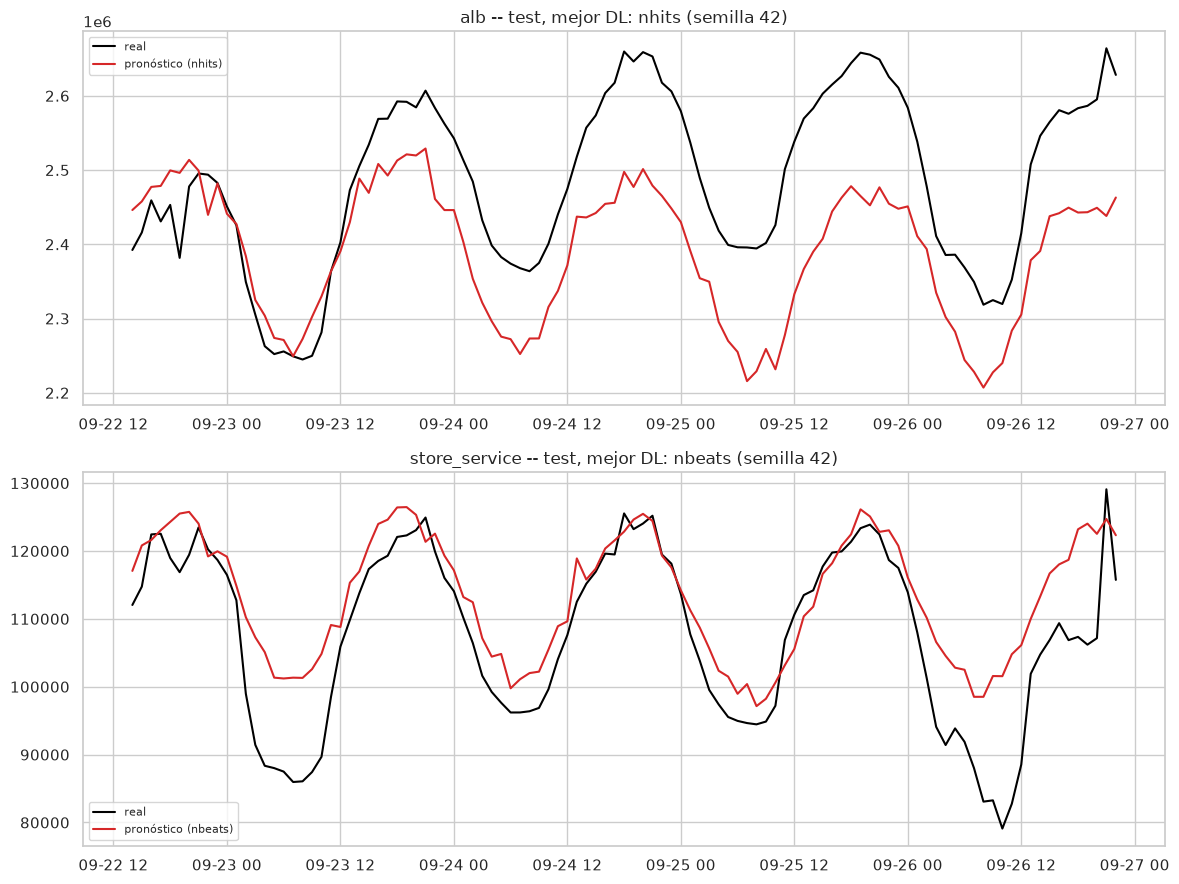

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
for ax, nombre_serie in zip(axes, SERIES_NAMES):
    ganador = ganadores_04[nombre_serie]
    semilla = int(seeds_04[(seeds_04["series"] == nombre_serie) & (seeds_04["architecture"] == ganador)]["seed"].iloc[0])
    series = SERIES[nombre_serie]
    train, val, test = split(series)
    ajuste = make_fit(ganador, semilla)
    ajuste(train)  # ajuste de validación, descartado -- solo sirve para fijar best_epoch
    pronostico_test = ajuste(train_and_val(series))(len(test))
    ax.plot(test.index, test.to_numpy(), label="real", color="black")
    ax.plot(test.index, pronostico_test, label=f"pronóstico ({ganador})", color="#d62728")
    ax.set_title(f"{nombre_serie} -- test, mejor DL: {ganador} (semilla {semilla})")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Conclusiones de la fase 04

**Ninguna arquitectura DL le gana a `seasonal_naive_m24` ni al mejor modelo de las fases 02-03 en validación**, en ninguna de las dos series: ALB, mejor DL `nhits` (MASE 0.556) vs. naive 0.489 vs. `catboost_tuned` 0.353; store_service, mejor DL `nbeats` (MASE 0.638) vs. naive 0.480. **En test la situación se invierte**: `nbeats` es el mejor modelo DL en ambas series y sí le gana tanto a la naive como al mejor modelo pre-DL (ALB: test MASE 1.744 vs. naive 1.990; store_service: 1.247 vs. 1.443) -- la misma asimetría validación/test que documentaron las fases 02 y 03. La dispersión entre semillas es alta para `lstm` y `nbeats` (CV hasta 57% en ALB) y TFT domina el costo de entrenamiento (10-30x el resto) sin ganar en ninguna serie ni split: la arquitectura más cara no es la más precisa. Los números de esta subsección ya incorporan la corrección del 2026-09-28 (restauración de los pesos de la mejor época tras *early stopping*, ver `status/04-dl-models.md`, sección Evidencia -> Corrección): antes de esa corrección, el mejor DL en validación era `nhits` con MASE 0.875 en ALB y `tcn` con 0.760 en store_service -- las cifras vigentes (0.556 y 0.638) son las que corresponden a este notebook.


## Fase 05 — Prophet, híbridos, AutoML y modelo de fundación

Familias que faltaban en la comparación: Prophet/NeuralProphet (familia `Prophet`), un híbrido MSTL + LightGBM (`Hybrid`), un ensamble de peso igual entre el mejor modelo de cada fase anterior (`Ensemble`), AutoGluon TimeSeries y AutoTS (`AutoML`) y Chronos-Bolt zero-shot (`Foundation`). TimeGPT (Nixtla) se omite por completo: requiere una API externa con clave, sin aprobación explícita para este proyecto. Regla de fuga heredada de la fase 04: ningún tuneo/*early stopping*/peso de ensamble puede mirar la ventana de selección de 48 h; el tuneo de Prophet usa las 168 h inmediatamente anteriores. Con `REENTRENAR = True` es, junto con la fase 04, la fase más costosa: ~17 minutos de ajuste medidos (~22 min de notebook, `status/05-hybrid-automl-foundation.md`), dominados por AutoGluon (300 s de límite de tiempo x 2 llamados x 2 series).


In [32]:
DEFAULT_ML_NAMES = list(RECURSIVE_MODELS)  # solo boosters/lineales sin tunear
FAMILIAS_BASELINE = ["naive", "classical", "SARIMA (TP1 refit)"]


def ajuste_baseline_para(nombre_serie, nombre_modelo):
    if nombre_modelo in NAIVE_MODELS:
        return NAIVE_MODELS[nombre_modelo]
    if nombre_modelo in CLASSICAL_MODELS:
        return CLASSICAL_MODELS[nombre_modelo]
    orden, orden_estacional = SARIMA_SPECS[nombre_serie]
    return make_sarima_fit(orden, orden_estacional)


def seleccionar_miembros_ensamble(nombre_serie):
    pool_baseline = tabla_02[(tabla_02["series"] == nombre_serie) & (tabla_02["family"].isin(FAMILIAS_BASELINE))]
    fila_baseline = pool_baseline[pool_baseline["split"] == "val"].sort_values("MAE").iloc[0]
    pool_ml = tabla_03[(tabla_03["series"] == nombre_serie) & (tabla_03["family"] == "ML") & (tabla_03["model"].isin(DEFAULT_ML_NAMES))]
    fila_ml = pool_ml[pool_ml["split"] == "val"].sort_values("MAE").iloc[0]
    pool_dl = tabla_04[(tabla_04["series"] == nombre_serie) & (tabla_04["split"] == "val")].sort_values("MAE").reset_index(drop=True)
    fila_dl = pool_dl.iloc[0]
    if fila_dl["model"] == "tft":
        fila_dl = pool_dl.iloc[1]  # tft es la arquitectura mas cara; se sustituye si ganara (no ocurrió en la práctica)
    return {
        "baseline": (fila_baseline["model"], ajuste_baseline_para(nombre_serie, fila_baseline["model"])),
        "ml": (fila_ml["model"], RECURSIVE_MODELS[fila_ml["model"]]),
        "dl": (fila_dl["model"], make_fit(fila_dl["model"], seed=SEEDS[0])),
    }


In [33]:
def ejecutar_pipeline_05(nombre_serie: str) -> dict:
    print(f"=== {nombre_serie} ===")
    series = SERIES[nombre_serie]
    tabla = ResultsTable()

    evaluate(prophet_default_fit, model="prophet_default", family="Prophet", series_name=nombre_serie, series=series, table=tabla)
    prophet_tuneado = make_prophet_tuned_fit()
    evaluate(prophet_tuneado, model="prophet_tuned", family="Prophet", series_name=nombre_serie, series=series, table=tabla)
    evaluate(neuralprophet_fit, model="neuralprophet", family="Prophet", series_name=nombre_serie, series=series, table=tabla)
    evaluate(hybrid_mstl_lightgbm_fit, model="mstl_lightgbm", family="Hybrid", series_name=nombre_serie, series=series, table=tabla)
    modelos_autogluon = evaluate_autogluon(series, series_name=nombre_serie, table=tabla)
    evaluate(autots_fit, model="autots", family="AutoML", series_name=nombre_serie, series=series, table=tabla)
    evaluate(chronos_zero_shot_fit, model="chronos_bolt_base", family="Foundation", series_name=nombre_serie, series=series, table=tabla)

    miembros = seleccionar_miembros_ensamble(nombre_serie)
    ajuste_ensamble = make_ensemble_fit([ajuste for _nombre, ajuste in miembros.values()])
    evaluate(ajuste_ensamble, model="ensemble_equal_weight", family="Ensemble", series_name=nombre_serie, series=series, table=tabla)

    df = tabla.to_frame()
    ganador = df[df["split"] == "val"].sort_values("MAE").iloc[0]["model"]
    print(f"ganador ({nombre_serie}): {ganador} | miembros de ensamble: {[n for n, _f in miembros.values()]} | AutoGluon: {modelos_autogluon}")
    return {"table": df, "series": series, "winner": ganador, "ensemble_members": miembros}


### 5.1 Serie ALB y 5.2 Serie store_service

Con `REENTRENAR = False` se reutiliza `results/05_hybrid.csv`.


In [34]:
if REENTRENAR:
    resultados_05 = {nombre_serie: ejecutar_pipeline_05(nombre_serie) for nombre_serie in SERIES_NAMES}
    tabla_05 = pd.concat([resultados_05[s]["table"] for s in SERIES_NAMES], ignore_index=True)
    tabla_05.to_csv(RUTA_RESULTADOS / "05_hybrid.csv", index=False)
    print(f"REENTRENAR=True: se recalcularon y sobrescribieron {len(tabla_05)} filas en 05_hybrid.csv")
else:
    print("REENTRENAR=False: se reutiliza results/05_hybrid.csv, no se reentrena nada.")
    resultados_05 = None

tabla_05 = pd.read_csv(RUTA_RESULTADOS / "05_hybrid.csv")
tabla_val_05 = tabla_05[tabla_05["split"] == "val"].sort_values(["series", "MASE"])
ganadores_05 = {
    nombre_serie: tabla_val_05[tabla_val_05["series"] == nombre_serie].iloc[0]["model"]
    for nombre_serie in SERIES_NAMES
}
print("Mejor modelo de fase 05 por serie:", ganadores_05)


REENTRENAR=False: se reutiliza results/05_hybrid.csv, no se reentrena nada.
Mejor modelo de fase 05 por serie: {'alb': 'ensemble_equal_weight', 'store_service': 'ensemble_equal_weight'}


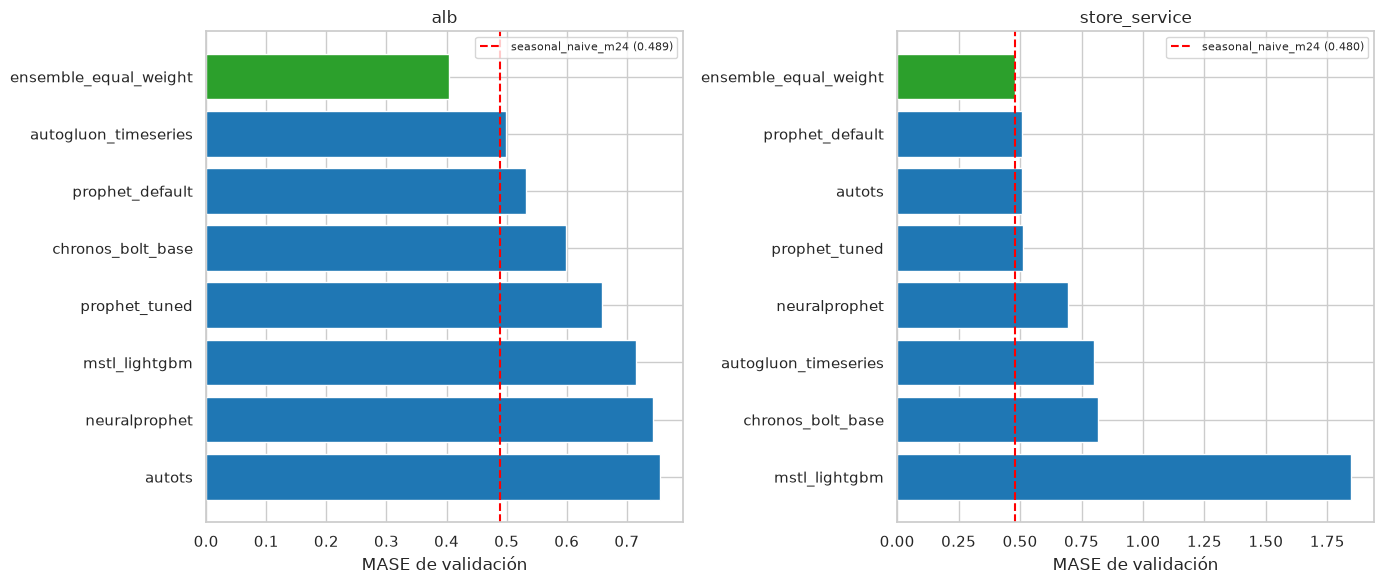

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, nombre_serie in zip(axes, SERIES_NAMES):
    ranking = tabla_val_05[tabla_val_05["series"] == nombre_serie][["model", "MASE"]].sort_values("MASE", ascending=False)
    mase_naive = tabla_02.loc[(tabla_02["series"] == nombre_serie) & (tabla_02["model"] == "seasonal_naive_m24") & (tabla_02["split"] == "val"), "MASE"].iloc[0]
    colores = ["#2ca02c" if m == ganadores_05[nombre_serie] else "#1f77b4" for m in ranking["model"]]
    ax.barh(ranking["model"], ranking["MASE"], color=colores)
    ax.axvline(mase_naive, color="red", linestyle="--", label=f"seasonal_naive_m24 ({mase_naive:.3f})")
    ax.set_xlabel("MASE de validación")
    ax.set_title(nombre_serie)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 5.3 Pronóstico en test del mejor modelo de fase 05

El ganador de las dos series es `ensemble_equal_weight`, cuyo pronóstico de test exige reentrenar sus tres miembros (uno de ellos, el `auto_arima` o el SARIMA de TP1 según la serie, cuesta ~1 minuto). Con `REENTRENAR = True` se reentrena en el momento, reutilizando los cierres (`Fit`) ya construidos en el bloque anterior. Con `REENTRENAR = False` se muestra la figura ya generada por `notebooks/05_hybrid_automl_foundation.ipynb` en vez de repetir ese costo solo para una figura.


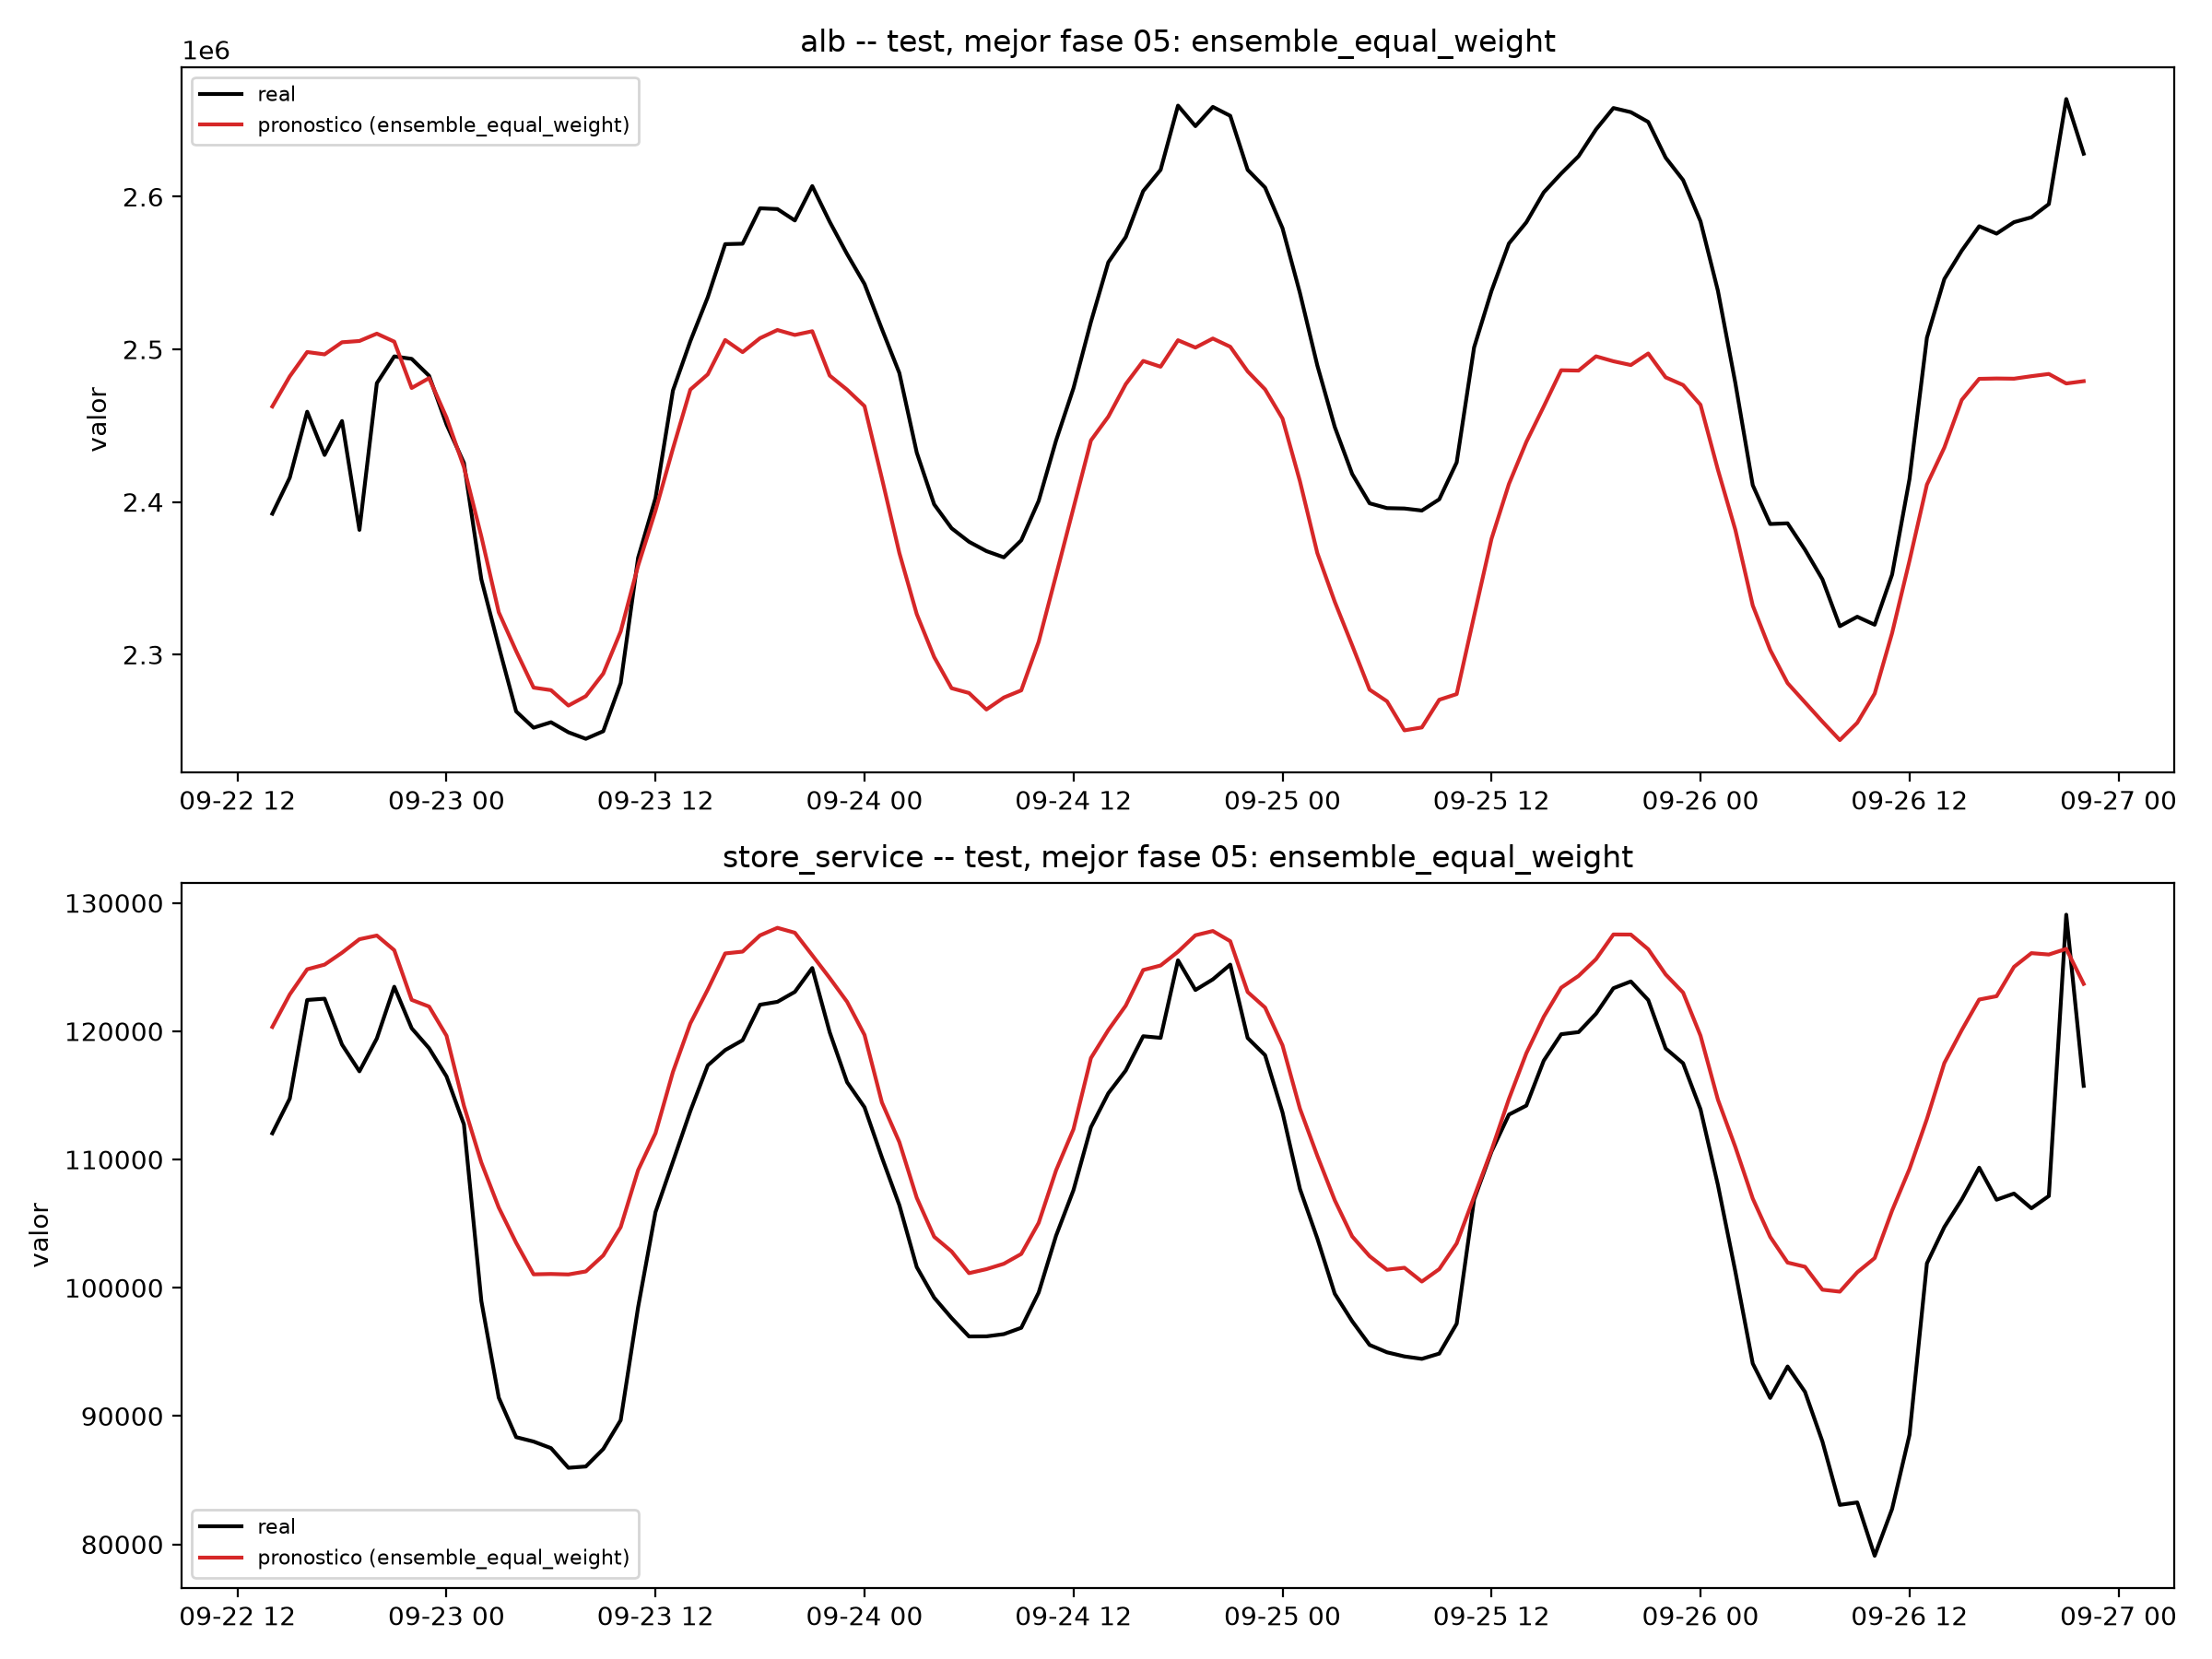

In [36]:
if REENTRENAR:
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))
    for ax, nombre_serie in zip(axes, SERIES_NAMES):
        series = SERIES[nombre_serie]
        train, val, test = split(series)
        ajuste_completo = train_and_val(series)
        ganador = resultados_05[nombre_serie]["winner"]
        miembros = resultados_05[nombre_serie]["ensemble_members"]
        ajuste_ensamble = make_ensemble_fit([ajuste for _n, ajuste in miembros.values()])
        pronostico = ajuste_ensamble(ajuste_completo)(len(test))
        ax.plot(test.index, test.to_numpy(), label="real", color="black")
        ax.plot(test.index, pronostico, label=f"pronóstico ({ganador})", color="#d62728")
        ax.set_title(f"{nombre_serie} -- test, mejor fase 05: {ganador}")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    display(Image(filename=str(RUTA_FIGURAS_INFORME / "05_test_forecast_best_model.png")))


### Conclusiones de la fase 05

En **ALB**, `ensemble_equal_weight` es el mejor modelo de la fase en validación (MASE 0.404, le gana a la naive 0.489) pero no supera a `catboost_tuned` (0.353, fase 03); `chronos_bolt_base` (0.598) es notable por ser zero-shot puro. `prophet_tuned` rinde peor que `prophet_default` en validación (0.659 vs. 0.532) pero **mejor en test** (MASE 1.578, el mejor de la fase) -- el tuneo optimiza sobre una ventana distinta de la de selección, así que no hay garantía de que transfiera. El híbrido `mstl_lightgbm` es el peor modelo del proyecto en test hasta esta fase (MASE 5.720): extrapolar la serie desestacionalizada 105 h hacia delante amplifica mucho más el error que en la ventana de 48 h de validación. En **store_service**, `ensemble_equal_weight` (0.480126) y `seasonal_naive_m24` (0.480171) quedan prácticamente empatados -- la diferencia es ruido; en test gana `neuralprophet` (MASE 1.071) a pesar de haber sido el segundo peor de su familia en validación (0.694), otra inversión validación/test. Ninguna familia de la fase 05 domina de forma consistente ambos *splits* ni ambas series -- la misma conclusión que las fases 02-04 ya establecieron.


## Fase 06 — Comparación, selección y pronóstico final

Junta los 32 modelos por serie evaluados en las fases 02 a 05 en un solo tablero, marca los modelos cuya validación está contaminada (se usó la misma ventana para elegir sus propios hiperparámetros o miembros), aplica la regla de selección acordada (menor MAE de validación entre los no contaminados, sin desempate por parsimonia), confirma qué tan estable es ese ranking en test (Spearman) y reentrena el modelo elegido -- junto con el peor, el SARIMA de TP1 y Chronos-Bolt -- sobre todos los datos limpios disponibles para pronosticar las 48 h siguientes con intervalos. Todo lo de esta subsección se calcula siempre en memoria a partir de las tablas de las fases 02-05 (`REENTRENAR` no cambia estos cálculos, que son puro pandas); solo el pronóstico final reentrena modelos reales, y solo cuando `REENTRENAR = True` se vuelve a escribir en `results/06_all_models.csv`/`results/06_final_forecast.csv`.


In [37]:
pool = load_pool()
pool = add_contamination_flags(pool)
pool = add_rank_columns(pool)
if REENTRENAR:
    pool.to_csv(RUTA_RESULTADOS / "06_all_models.csv", index=False)
    print(f"REENTRENAR=True: se recalculó y sobrescribió 06_all_models.csv ({len(pool)} filas)")
else:
    print(f"REENTRENAR=False: tablero de {len(pool)} filas calculado en memoria (no se sobrescribe 06_all_models.csv)")

for nombre_serie in SERIES_NAMES:
    contaminados = pool[(pool.series == nombre_serie) & (pool.split == "val") & (pool.val_contaminated)]
    print(f"\n=== {nombre_serie}: modelos con validación contaminada ===")
    print(contaminados[["model", "family", "MASE", "contamination_reason"]].to_string(index=False))


REENTRENAR=False: tablero de 128 filas calculado en memoria (no se sobrescribe 06_all_models.csv)

=== alb: modelos con validación contaminada ===
                model   family     MASE                                                                                                                                                                                                                                                     contamination_reason
       catboost_tuned       ML 0.353497 Hyperparameters tuned with Optuna (tsa_final.ml_models.tune_hyperparameters), scored on a TimeSeriesFold at the train/val boundary -- the same 48h window later used to rank and select models. Wins validation, then frequently loses on test (status/03-ml-models.md).
  random_forest_tuned       ML 0.416238 Hyperparameters tuned with Optuna (tsa_final.ml_models.tune_hyperparameters), scored on a TimeSeriesFold at the train/val boundary -- the same 48h window later used to rank and select models. Wins valida

### 6.1 Mejor modelo de cada familia y regla de selección

**Regla acordada**: el modelo seleccionado por serie es el de menor MAE de validación entre los modelos elegibles (no contaminados), sin desempate por parsimonia. Las métricas de test se reportan siempre, nunca se usan para seleccionar.


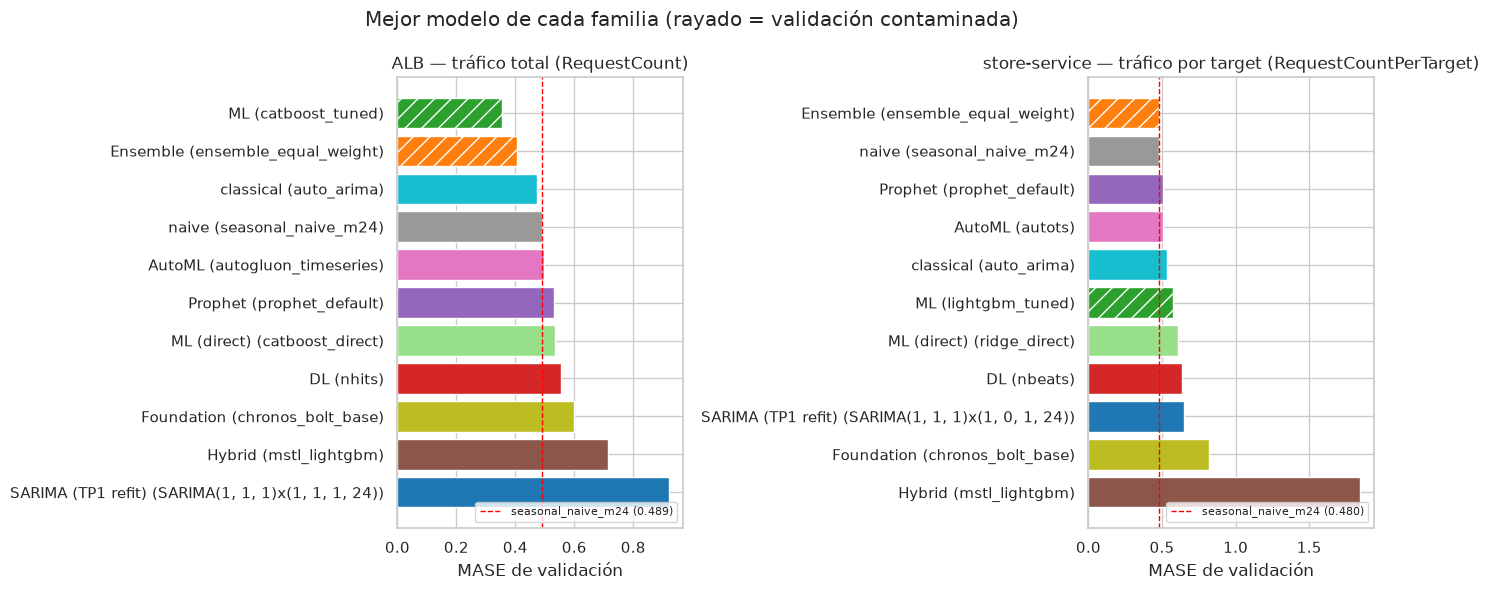

In [38]:
FAMILY_COLORS = {
    "naive": "#999999", "SARIMA (TP1 refit)": "#1f77b4", "classical": "#17becf",
    "ML": "#2ca02c", "ML (direct)": "#98df8a", "DL": "#d62728", "Prophet": "#9467bd",
    "Hybrid": "#8c564b", "AutoML": "#e377c2", "Foundation": "#bcbd22", "Ensemble": "#ff7f0e",
}

fig, axes = plt.subplots(1, len(SERIES_NAMES), figsize=(14, 6))
for ax, nombre_serie in zip(axes, SERIES_NAMES):
    bpf = best_per_family(pool, nombre_serie).sort_values("MASE", ascending=False)
    colores = [FAMILY_COLORS.get(f, "#333333") for f in bpf["family"]]
    barras = ax.barh(bpf["family"] + " (" + bpf["model"] + ")", bpf["MASE"], color=colores)
    for barra, contaminado in zip(barras, bpf["val_contaminated"]):
        barra.set_hatch("//" if contaminado else "")
    mase_naive = pool.loc[(pool.series == nombre_serie) & (pool.split == "val") & (pool.model == "seasonal_naive_m24"), "MASE"].iloc[0]
    ax.axvline(mase_naive, color="red", linestyle="--", linewidth=1, label=f"seasonal_naive_m24 ({mase_naive:.3f})")
    ax.set_xlabel("MASE de validación")
    ax.set_title(SERIES_LABELS[nombre_serie])
    ax.legend(fontsize=8, loc="lower right")
plt.suptitle("Mejor modelo de cada familia (rayado = validación contaminada)")
plt.tight_layout()
plt.show()


In [39]:
for nombre_serie in SERIES_NAMES:
    res = select_model(pool, nombre_serie)
    ref = tp1_and_foundation_reference(pool, nombre_serie)
    fila_tp1 = ref[ref.family == "SARIMA (TP1 refit)"].iloc[0]
    fila_chronos = ref[ref.family == "Foundation"].iloc[0]
    fila_test = lambda modelo: pool[(pool.series == nombre_serie) & (pool.split == "test") & (pool.model == modelo)].iloc[0]
    test_sel, test_naive, test_tp1 = fila_test(res.selected["model"]), fila_test("seasonal_naive_m24"), fila_test(fila_tp1["model"])
    print(f"\n=== {nombre_serie} ===")
    print(f"Seleccionado : {res.selected['model']:<24} val MASE={res.selected['MASE']:.3f}  test MASE={test_sel['MASE']:.3f}")
    print(f"Subcampeón   : {res.runner_up['model']:<24} val MASE={res.runner_up['MASE']:.3f}")
    print(f"Peor elegible: {res.worst['model']:<24} val MASE={res.worst['MASE']:.3f}")
    print(f"TP1 SARIMA   : {fila_tp1['model']:<24} val MASE={fila_tp1['MASE']:.3f}  test MASE={test_tp1['MASE']:.3f}")
    print(f"Chronos-Bolt : val MASE={fila_chronos['MASE']:.3f}  test MASE={fila_test('chronos_bolt_base')['MASE']:.3f}")
    print(f"Mejora sobre TP1 SARIMA   -- val: {pct_improvement(fila_tp1['MAE'], res.selected['MAE']):+.1f}%   test: {pct_improvement(test_tp1['MAE'], test_sel['MAE']):+.1f}%")
    print(f"Mejora sobre seasonal_naive_m24 -- val: {pct_improvement(pool[(pool.series == nombre_serie) & (pool.split == 'val') & (pool.model == 'seasonal_naive_m24')].iloc[0]['MAE'], res.selected['MAE']):+.1f}%   test: {pct_improvement(test_naive['MAE'], test_sel['MAE']):+.1f}%")



=== alb ===
Seleccionado : auto_arima               val MASE=0.475  test MASE=2.058
Subcampeón   : seasonal_naive_m24       val MASE=0.489
Peor elegible: average                  val MASE=3.788
TP1 SARIMA   : SARIMA(1, 1, 1)x(1, 1, 1, 24) val MASE=0.923  test MASE=1.526
Chronos-Bolt : val MASE=0.598  test MASE=2.007
Mejora sobre TP1 SARIMA   -- val: +48.5%   test: -34.9%
Mejora sobre seasonal_naive_m24 -- val: +2.9%   test: -3.4%

=== store_service ===
Seleccionado : seasonal_naive_m24       val MASE=0.480  test MASE=1.443
Subcampeón   : prophet_default          val MASE=0.506
Peor elegible: drift                    val MASE=3.582
TP1 SARIMA   : SARIMA(1, 1, 1)x(1, 0, 1, 24) val MASE=0.647  test MASE=1.426
Chronos-Bolt : val MASE=0.816  test MASE=1.673
Mejora sobre TP1 SARIMA   -- val: +25.8%   test: -1.2%
Mejora sobre seasonal_naive_m24 -- val: +0.0%   test: +0.0%


### 6.2 ¿Se sostiene el ranking en test? Correlación de Spearman

Un valor bajo confirma lo que las fases 02-05 ya venían mostrando: la ventana de validación de 48 h es una sola muestra, chica y ruidosa -- razón por la cual la regla de selección nunca usa test.


alb: Spearman (32 modelos) rho=0.237 (p=0.192) | elegibles rho=0.346 (p=0.077)
store_service: Spearman (32 modelos) rho=0.654 (p=0.000) | elegibles rho=0.692 (p=0.000)


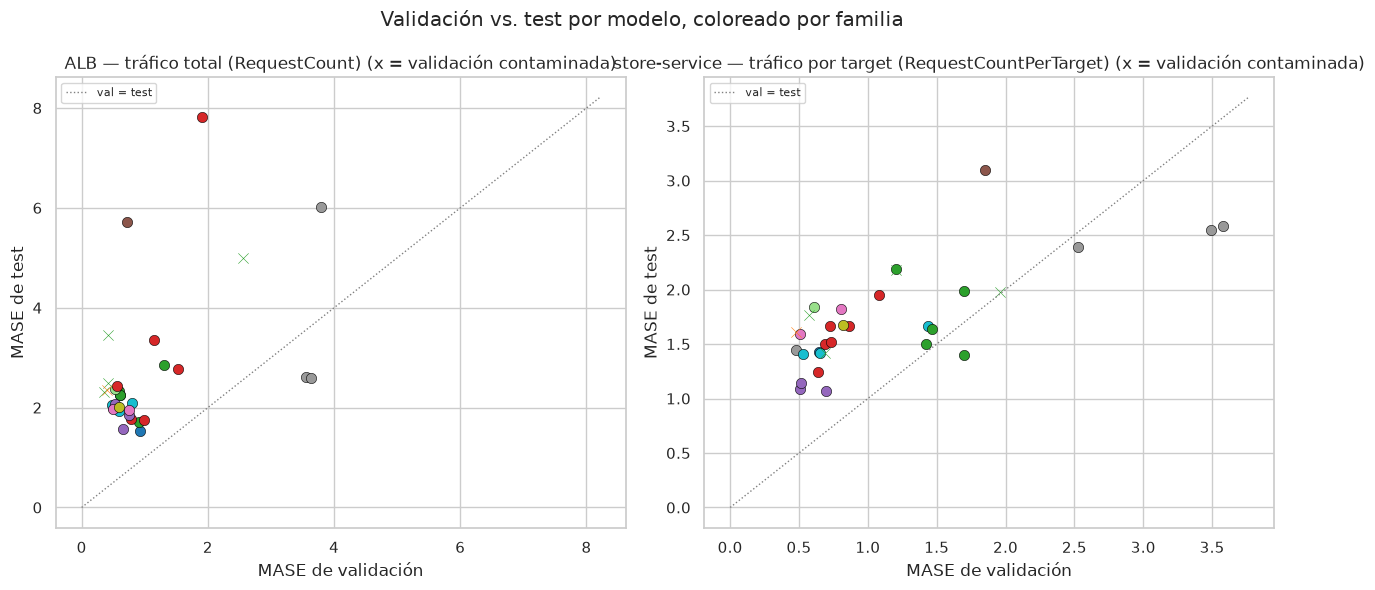

In [40]:
fig, axes = plt.subplots(1, len(SERIES_NAMES), figsize=(13, 6))
for ax, nombre_serie in zip(axes, SERIES_NAMES):
    cons_todos = val_test_consistency(pool, nombre_serie, eligible_only=False)
    cons_elegibles = val_test_consistency(pool, nombre_serie, eligible_only=True)
    print(f"{nombre_serie}: Spearman (32 modelos) rho={cons_todos.rho:.3f} (p={cons_todos.p_value:.3f}) | "
          f"elegibles rho={cons_elegibles.rho:.3f} (p={cons_elegibles.p_value:.3f})")
    val_sub = pool[(pool.series == nombre_serie) & (pool.split == "val")]
    test_sub = pool[(pool.series == nombre_serie) & (pool.split == "test")]
    merged = val_sub.merge(test_sub, on="model", suffixes=("_val", "_test"))
    for _, fila in merged.iterrows():
        marcador = "x" if fila["val_contaminated_val"] else "o"
        ax.scatter(fila["MASE_val"], fila["MASE_test"], color=FAMILY_COLORS.get(fila["family_val"], "#333333"),
                    marker=marcador, s=55, edgecolors="black", linewidths=0.4)
    limite = max(merged["MASE_val"].max(), merged["MASE_test"].max()) * 1.05
    ax.plot([0, limite], [0, limite], color="gray", linestyle=":", linewidth=1, label="val = test")
    ax.set_xlabel("MASE de validación")
    ax.set_ylabel("MASE de test")
    ax.set_title(f"{SERIES_LABELS[nombre_serie]} (x = validación contaminada)")
    ax.legend(fontsize=8)
plt.suptitle("Validación vs. test por modelo, coloreado por familia")
plt.tight_layout()
plt.show()


### 6.3 Análisis de sensibilidad (informativo — **no** es la regla de selección)

¿Quién ganaría bajo otro criterio? (a) la regla adoptada; (b) MAE de validación incluyendo contaminados; (c) MAE de test como oráculo (imposible en la práctica).


In [41]:
for nombre_serie in SERIES_NAMES:
    print(f"\n=== {nombre_serie} ===")
    print(sensitivity_table(pool, nombre_serie).to_string(index=False))



=== alb ===
                              criterion                        winner          MAE
       adopted rule (eligible, val MAE)                    auto_arima 18807.501329
including contaminated scores (val MAE)                catboost_tuned 13994.361587
      test MAE oracle (discussion only) SARIMA(1, 1, 1)x(1, 1, 1, 24) 60429.073334

=== store_service ===
                              criterion                winner         MAE
       adopted rule (eligible, val MAE)    seasonal_naive_m24 2281.852431
including contaminated scores (val MAE) ensemble_equal_weight 2281.636637
      test MAE oracle (discussion only)         neuralprophet 5090.391319


### 6.4 Comparación en la ventana de test y pronóstico final a 48 h

El resumen de test (seleccionado vs. peor vs. TP1 vs. Chronos) exige reentrenar los cuatro roles sobre `train_and_val`; el pronóstico final los reentrena de nuevo sobre todos los datos limpios disponibles. Ambos son costosos (varios refits de `auto_arima`/SARIMA por serie), así que solo se recalculan con `REENTRENAR = True` -- con `REENTRENAR = False` se muestra la figura de test ya generada por `notebooks/06_selection_forecast.ipynb` y se relee/regrafica `06_final_forecast.csv` (sin reentrenar nada, solo graficando números ya calculados).


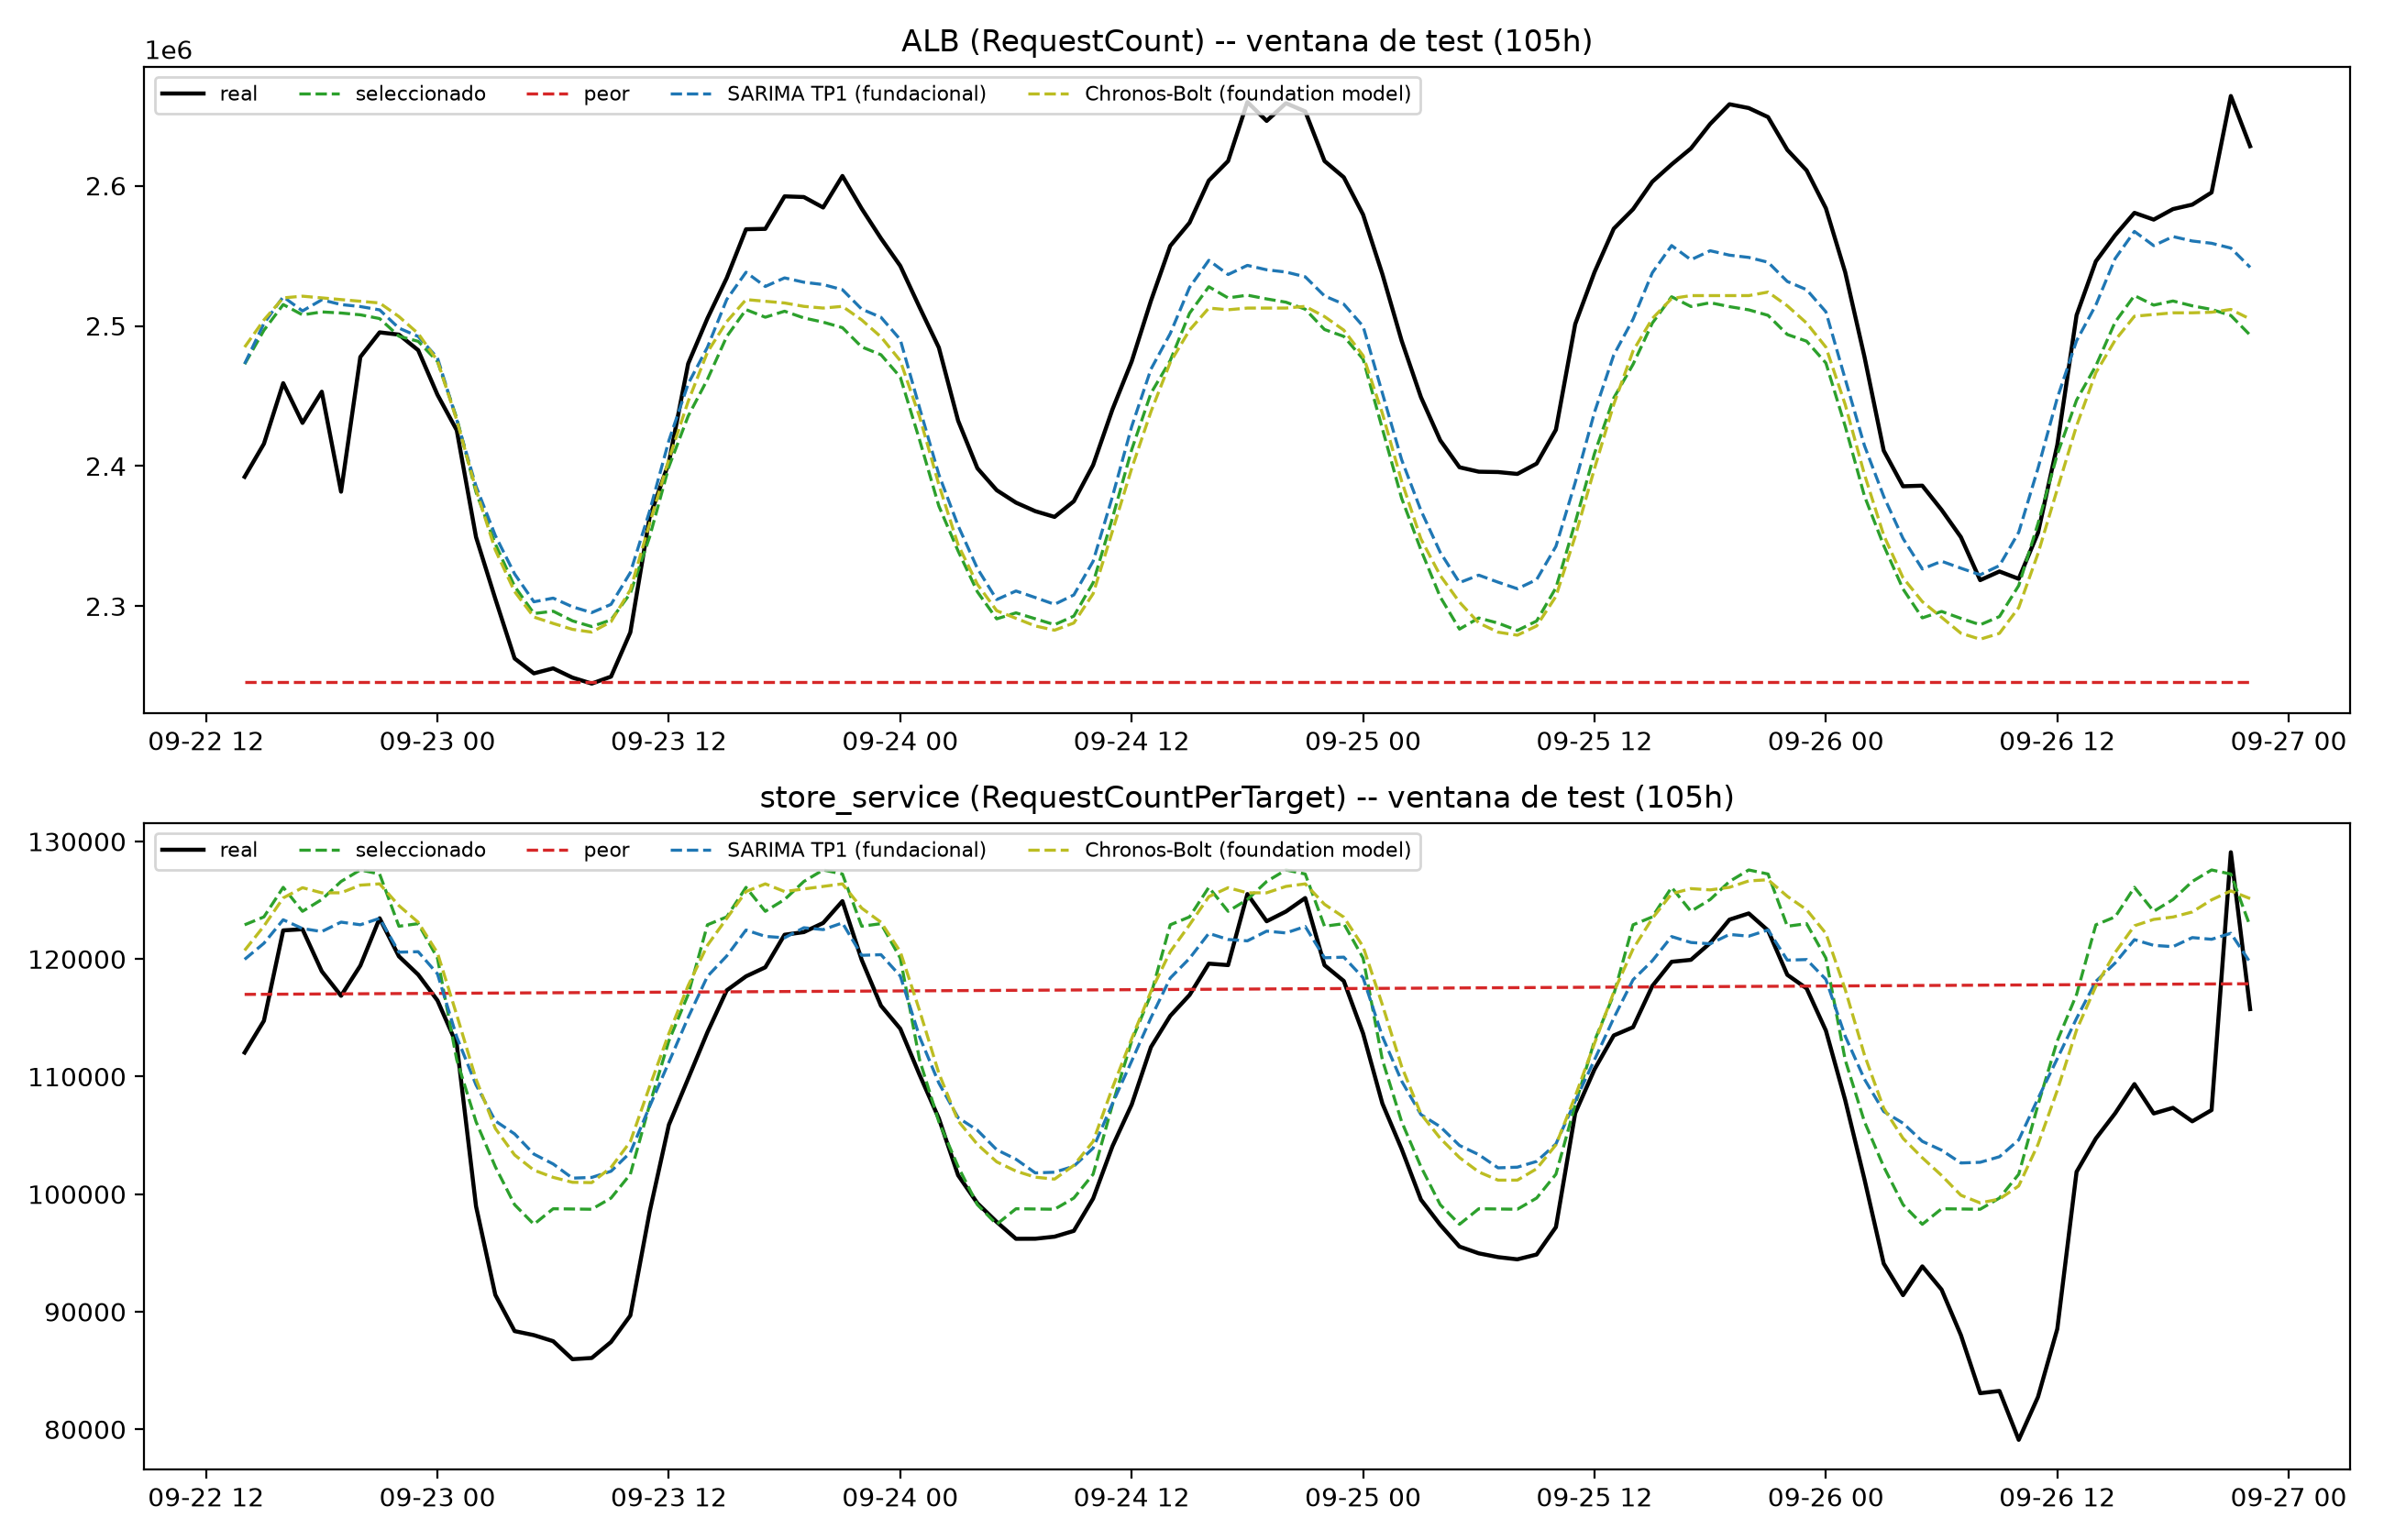

REENTRENAR=False: se reutiliza results/06_final_forecast.csv (384 filas), no se reentrena nada.


In [42]:
if REENTRENAR:
    fig, axes = plt.subplots(len(SERIES_NAMES), 1, figsize=(13, 4.2 * len(SERIES_NAMES)))
    role_labels = {"selected": "seleccionado", "worst": "peor", "tp1_foundational": "SARIMA TP1", "foundation_model": "Chronos-Bolt"}
    role_colors = {"selected": "#2ca02c", "worst": "#d62728", "tp1_foundational": "#1f77b4", "foundation_model": "#bcbd22"}
    for ax, nombre_serie in zip(axes, SERIES_NAMES):
        pronosticos, test = test_overlay_forecasts(nombre_serie)
        ax.plot(test.index, test.to_numpy(), color="black", linewidth=1.6, label="real")
        for rol, arreglo in pronosticos.items():
            ax.plot(test.index, arreglo, color=role_colors[rol], linestyle="--", linewidth=1.2, label=role_labels[rol])
        ax.set_title(f"{SERIES_LABELS[nombre_serie]} -- ventana de test (105h)")
        ax.legend(fontsize=8, ncol=4)
    plt.tight_layout()
    plt.show()

    pronostico_final = build_final_forecast_table()
    pronostico_final.to_csv(RUTA_RESULTADOS / "06_final_forecast.csv", index=False)
    print(f"REENTRENAR=True: se recalculó y sobrescribió 06_final_forecast.csv ({len(pronostico_final)} filas)")
else:
    display(Image(filename=str(RUTA_FIGURAS_INFORME / "06_test_overlay_forecast.png")))
    pronostico_final = pd.read_csv(RUTA_RESULTADOS / "06_final_forecast.csv", parse_dates=["timestamp"])
    print(f"REENTRENAR=False: se reutiliza results/06_final_forecast.csv ({len(pronostico_final)} filas), no se reentrena nada.")


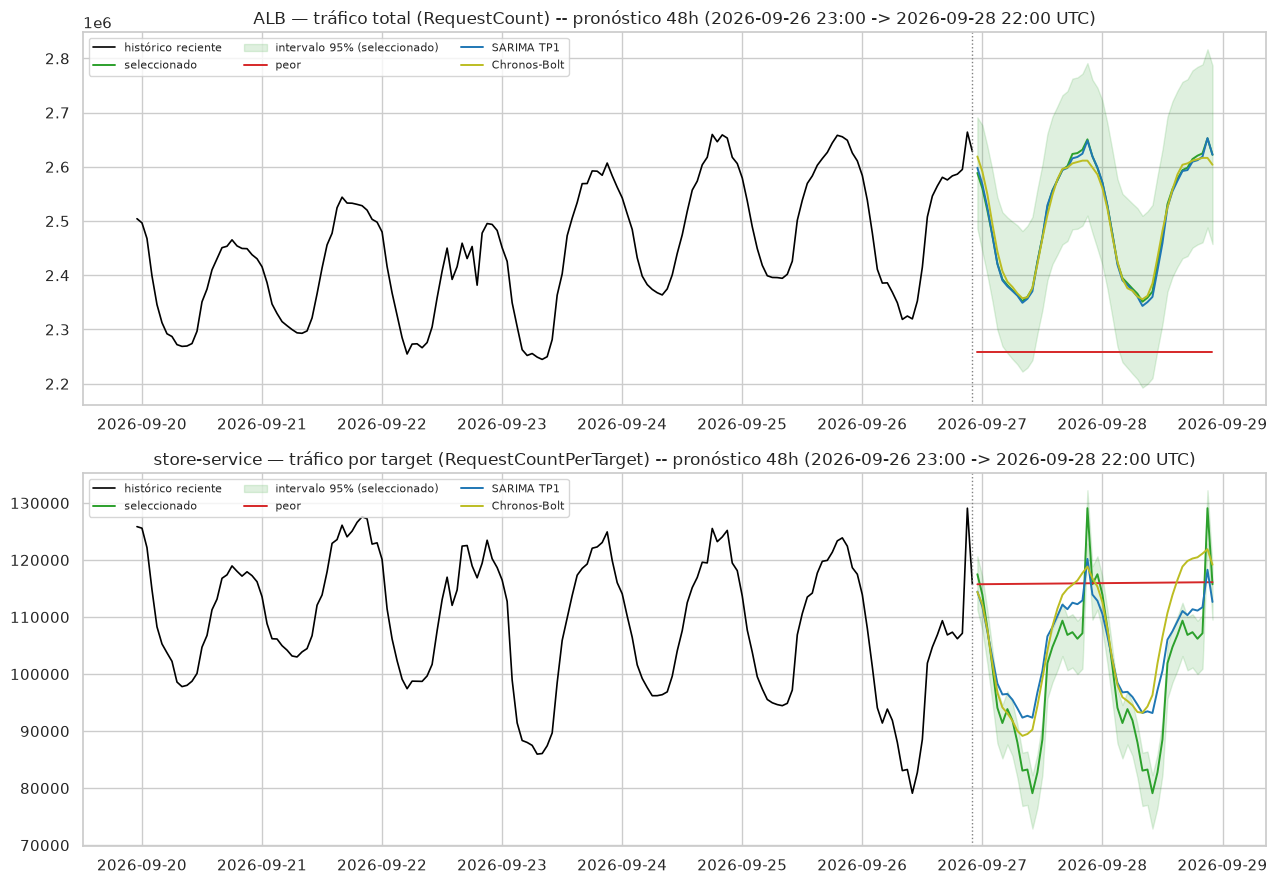

In [43]:
role_labels = {"selected": "seleccionado", "worst": "peor", "tp1_foundational": "SARIMA TP1", "foundation_model": "Chronos-Bolt"}
role_colors = {"selected": "#2ca02c", "worst": "#d62728", "tp1_foundational": "#1f77b4", "foundation_model": "#bcbd22"}

fig, axes = plt.subplots(len(SERIES_NAMES), 1, figsize=(13, 4.5 * len(SERIES_NAMES)))
horas_historial = 7 * 24
for ax, nombre_serie in zip(axes, SERIES_NAMES):
    historial = SERIES[nombre_serie].iloc[-horas_historial:]
    ax.plot(historial.index, historial.to_numpy(), color="black", linewidth=1.2, label="histórico reciente")
    sub = pronostico_final[pronostico_final.series == nombre_serie]
    for rol in ("selected", "worst", "tp1_foundational", "foundation_model"):
        df_rol = sub[sub.role == rol].sort_values("timestamp")
        ax.plot(df_rol.timestamp, df_rol.yhat, color=role_colors[rol], linewidth=1.4, label=role_labels[rol])
        if rol == "selected":
            tiene_95 = df_rol["lower_95"].notna().all()
            col_inf, col_sup = ("lower_95", "upper_95") if tiene_95 else ("lower_80", "upper_80")
            ax.fill_between(df_rol.timestamp, df_rol[col_inf], df_rol[col_sup], color=role_colors[rol], alpha=0.15,
                              label=f"intervalo {'95' if tiene_95 else '80'}% (seleccionado)")
    ax.axvline(historial.index[-1], color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{SERIES_LABELS[nombre_serie]} -- pronóstico 48h (2026-09-26 23:00 -> 2026-09-28 22:00 UTC)")
    ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()


### Conclusiones de la fase 06

**ALB**: seleccionado `auto_arima` (val MAE 18.807,5; MASE 0,475), apenas por debajo de `seasonal_naive_m24` (subcampeón, 0,489) y `autogluon_timeseries` (tercero, 0,499) -- una diferencia pequeña, no una goleada. Le gana al SARIMA fundacional de TP1 por 48,5% en validación, pero en test la relación se invierte: pierde contra el SARIMA de TP1 (-34,9%, el mejor modelo de los 32 en test, MASE 1,526) y contra la naive estacional (-3,4%). `catboost_tuned` (el "ganador" si se permitiera la contaminación) tiene MASE de validación mucho mejor (0,353) pero colapsa en test (2,313) -- justo el riesgo que la regla busca evitar. Peor modelo elegible: `average` (MASE 3,79).

**store_service**: seleccionado, literalmente, `seasonal_naive_m24` -- ningún modelo más sofisticado logró bajarle el MAE de validación sin contaminar. `ensemble_equal_weight` queda estadísticamente empatado pero excluido por construcción. Mejora sobre el SARIMA de TP1: +25,8% en validación, revertida a -1,2% en test (inconsistencia mucho más leve que en ALB). Peor modelo elegible: `drift` (MASE 3,58).

**¿Le ganaron los modelos avanzados al enfoque de TP1?** En validación, sí en las dos series -- pero el que gana termina siendo un modelo clásico (`auto_arima`) o la naive estacional, no ML/DL/AutoML. En test, no: el SARIMA fundacional de TP1 iguala o supera al modelo seleccionado en ambas series. Bajo el único criterio válido para elegir sin ver el futuro (MAE de validación, sin contaminar), los modelos más sofisticados de las fases 03-05 no superaron a los baselines clásicos y a la naive estacional en ninguna de las dos series -- el hallazgo más consistente de todo el proyecto, no una sorpresa de esta fase en particular. La correlación de Spearman validación/test, baja-a-moderada en ambas series, es una confirmación numérica adicional de que la ventana de validación única de 48 h es ruidosa (limitación del protocolo, aceptada por presupuesto de tiempo desde la fase 02 -- no evidencia de que el test debería usarse para elegir).


# 3. Serie pública adicional: visitas horarias de Wikipedia en español

**¿Qué es y por qué está acá?** La consigna pide tres series (`consignas.md`, punto 1). Además de `alb` y `store_service` (infraestructura de BodegaAI) se incorpora una serie **pública**: las visitas por hora de usuarios a Wikipedia en español (API de métricas de páginas vistas de Wikimedia, proyecto `es.wikipedia`, acceso `all-access`, agente `user`; datos bajo licencia CC0). Comparte con las otras dos el mismo calendario (2.063 horas del 2026-07-03 al 2026-09-26, sin huecos), el ciclo diario y las mismas ventanas de la fase 02 (validación de 48 h, test de 105 h), pero es tráfico externo, sin el deploy/rollback del 17 al 22 de septiembre y con una autocorrelación semanal (rezago 168) mucho más alta.

**Alcance, dicho sin rodeos.** Es un *baseline de contraste*, no una réplica de las Secciones 2.1-2.6: seis modelos de cinco familias con **hiperparámetros por defecto**, sin Deep Learning, sin AutoML, sin Chronos y sin búsqueda de hiperparámetros. La regla de selección es la misma (menor MAE de validación) y los resultados de `alb` y `store_service` **no se recalculan**. Por eso esta serie **no** se agrega a `SERIES_NAMES`: las funciones de las Secciones 2.x asumen las 32 configuraciones por serie y sus tablas persistidas.

**Datos.** `data/wikipedia-es-pageviews-hourly-since-2026-05-01.csv` (mismas columnas que los CSV de AWS). Se descarga de `https://wikimedia.org/api/rest_v1/metrics/pageviews/aggregate/es.wikipedia/all-access/user/hourly/2026050100/2026092622`; el repositorio incluye el script `experiments/00_download_wikipedia_es.py`. El registro `wikipedia_es` de `SERIES_REGISTRY` (Sección 1, `data.py`) la marca con `"intervention": "no"`, de modo que `load_clean` no le aplica la imputación del rollback.


## 3.1 La serie y su estructura frente a las de BodegaAI

La primera tabla compara la autocorrelación del logaritmo en los rezagos 24 (ciclo diario) y 168 (ciclo semanal). En Wikipedia casi no decae entre 24 y 168 horas; en ALB baja claramente. La segunda tabla muestra que la relación con las series de BodegaAI es de contexto (mismo ritmo diario) y no de dependencia: los cambios a 24 h prácticamente no están correlacionados.


wikipedia_es: 2063 horas, 2026-07-03 00:00:00+00:00 -> 2026-09-26 22:00:00+00:00
train 1794 h | val 48 h | test 105 h

               autocorr_rezago_24  autocorr_rezago_168
serie                                                 
alb                         0.838                0.614
store_service               0.863                0.809
wikipedia_es                0.958                0.956

               corr_niveles  corr_cambios_24h
contra                                       
alb                   0.407            -0.011
store_service         0.493             0.012


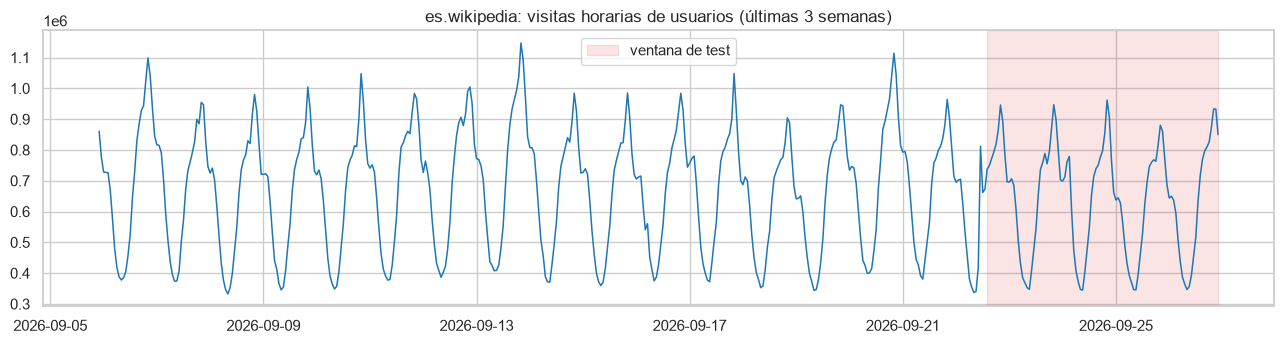

In [44]:
NOMBRE_WIKI = "wikipedia_es"

wiki = load_clean(NOMBRE_WIKI)  # sin imputación de intervención (registro: "intervention": "no")
wiki_train, wiki_val, wiki_test = split(wiki)
print(f"{NOMBRE_WIKI}: {len(wiki)} horas, {wiki.index[0]} -> {wiki.index[-1]}")
print(f"train {len(wiki_train)} h | val {len(wiki_val)} h | test {len(wiki_test)} h")

filas = []
for nombre in [*SERIES_NAMES, NOMBRE_WIKI]:
    x = np.log(load_clean(nombre).astype(float))
    filas.append({"serie": nombre, "autocorr_rezago_24": x.autocorr(24), "autocorr_rezago_168": x.autocorr(168)})
estructura = pd.DataFrame(filas).set_index("serie").round(3)
print()
print(estructura.to_string())

relacion = []
for nombre in SERIES_NAMES:
    conjunta = pd.concat(
        [np.log(load_clean(nombre).astype(float)).rename("x"), np.log(wiki.astype(float)).rename("w")], axis=1
    ).dropna()
    relacion.append({
        "contra": nombre,
        "corr_niveles": conjunta["x"].corr(conjunta["w"]),
        "corr_cambios_24h": conjunta["x"].diff(24).corr(conjunta["w"].diff(24)),
    })
print()
print(pd.DataFrame(relacion).set_index("contra").round(3).to_string())

fig, ax = plt.subplots(figsize=(13, 3.6))
reciente = wiki.loc[wiki.index[-1] - pd.Timedelta(days=21):]
ax.plot(reciente.index, reciente.to_numpy(), color="#1f77b4", lw=1.1)
ax.axvspan(wiki_test.index[0], wiki_test.index[-1], color="#d62728", alpha=0.12, label="ventana de test")
ax.set_title("es.wikipedia: visitas horarias de usuarios (últimas 3 semanas)")
ax.legend()
fig.tight_layout()
plt.show()


## 3.2 Seis modelos rápidos con hiperparámetros por defecto

`seasonal_naive_m24` (naive), `holt_winters` (clásico), `SARIMA(1, 1, 1)x(1, 1, 1, 24)` (la especificación de ALB del TP1, **no ajustada a esta serie**), `ridge` y `lightgbm` (recursivos, con rezagos de hasta 336 h y calendario) y `prophet_default`. Mismo protocolo de la fase 02: un ajuste sobre `train` para validar (48 h) y otro sobre `train + val + tramo de intervención` para el test (105 h). MASE con m=24. Con `REENTRENAR = False` se reutiliza `results/07_wikipedia.csv` si existe; si no existe, o con `REENTRENAR = True`, se ajustan los seis modelos (unos 15 segundos en total).


In [45]:
ARCHIVO_RESULTADOS_07 = RUTA_RESULTADOS / "07_wikipedia.csv"
ARCHIVO_PRONOSTICO_07 = RUTA_RESULTADOS / "07_wikipedia_forecast.csv"

modelos_wiki = [
    ("seasonal_naive_m24", "naive", NAIVE_MODELS["seasonal_naive_m24"]),
    ("holt_winters", "classical", CLASSICAL_MODELS["holt_winters"]),
    ("SARIMA(1, 1, 1)x(1, 1, 1, 24)", "SARIMA (TP1 refit)", make_sarima_fit((1, 1, 1), (1, 1, 1, 24))),
    ("ridge", "ML", RECURSIVE_MODELS["ridge"]),
    ("lightgbm", "ML", RECURSIVE_MODELS["lightgbm"]),
    ("prophet_default", "Prophet", prophet_default_fit),
]

if REENTRENAR or not ARCHIVO_RESULTADOS_07.exists():
    tabla_wiki = ResultsTable()
    for nombre, familia, ajuste in modelos_wiki:
        evaluate(ajuste, model=nombre, family=familia, series_name=NOMBRE_WIKI, series=wiki, table=tabla_wiki)
    res_wiki = tabla_wiki.to_frame()
    res_wiki.to_csv(ARCHIVO_RESULTADOS_07, index=False)
else:
    res_wiki = pd.read_csv(ARCHIVO_RESULTADOS_07)

columnas = ["model", "family", "MAE", "MAPE_%", "MASE", "fit_time_s"]
for ventana, etiqueta in [("val", "Validación (48 h)"), ("test", "Test (105 h)")]:
    print(f"\n{etiqueta}")
    print(res_wiki[res_wiki["split"] == ventana].sort_values("MAE")[columnas].round(3).to_string(index=False))



Validación (48 h)
                        model             family       MAE  MAPE_%  MASE  fit_time_s
           seasonal_naive_m24              naive 21146.771   3.519 0.438       0.000
              prophet_default            Prophet 31597.995   4.748 0.655       0.175
                     lightgbm                 ML 35076.467   5.574 0.727       0.417
SARIMA(1, 1, 1)x(1, 1, 1, 24) SARIMA (TP1 refit) 49383.801   8.724 1.023       3.501
                 holt_winters          classical 55195.648   9.534 1.143       0.206
                        ridge                 ML 65234.874  10.562 1.351       0.091

Test (105 h)
                        model             family        MAE  MAPE_%  MASE  fit_time_s
                        ridge                 ML  37830.596   6.482 0.784       0.004
           seasonal_naive_m24              naive  44587.781   7.835 0.924       0.000
              prophet_default            Prophet  54035.336   8.398 1.119       0.124
                     lightgb

## 3.3 Selección, desacuerdo validación/test y pronóstico de 48 h

Misma regla que en el resto del proyecto: **el modelo seleccionado es el de menor MAE de validación**. Se reporta además el mejor y el peor en test. La validación es una sola ventana de 48 h y el test una sola de 105 h: si los rankings discrepan, se dice, no se elige por test. El pronóstico final reajusta el modelo seleccionado con toda la historia disponible y proyecta 48 horas fuera de muestra (sin intervalos de predicción).


Seleccionado por validación : seasonal_naive_m24 (MAE val 21,147)
Mejor en test               : ridge (MAE test 37,831)
Peor en test                : SARIMA(1, 1, 1)x(1, 1, 1, 24) (MAE test 121,297)
Correlación de Spearman entre rankings val y test (6 modelos): 0.09

Pronóstico final: 48 h desde 2026-09-26 23:00:00+00:00 hasta 2026-09-28 22:00:00+00:00


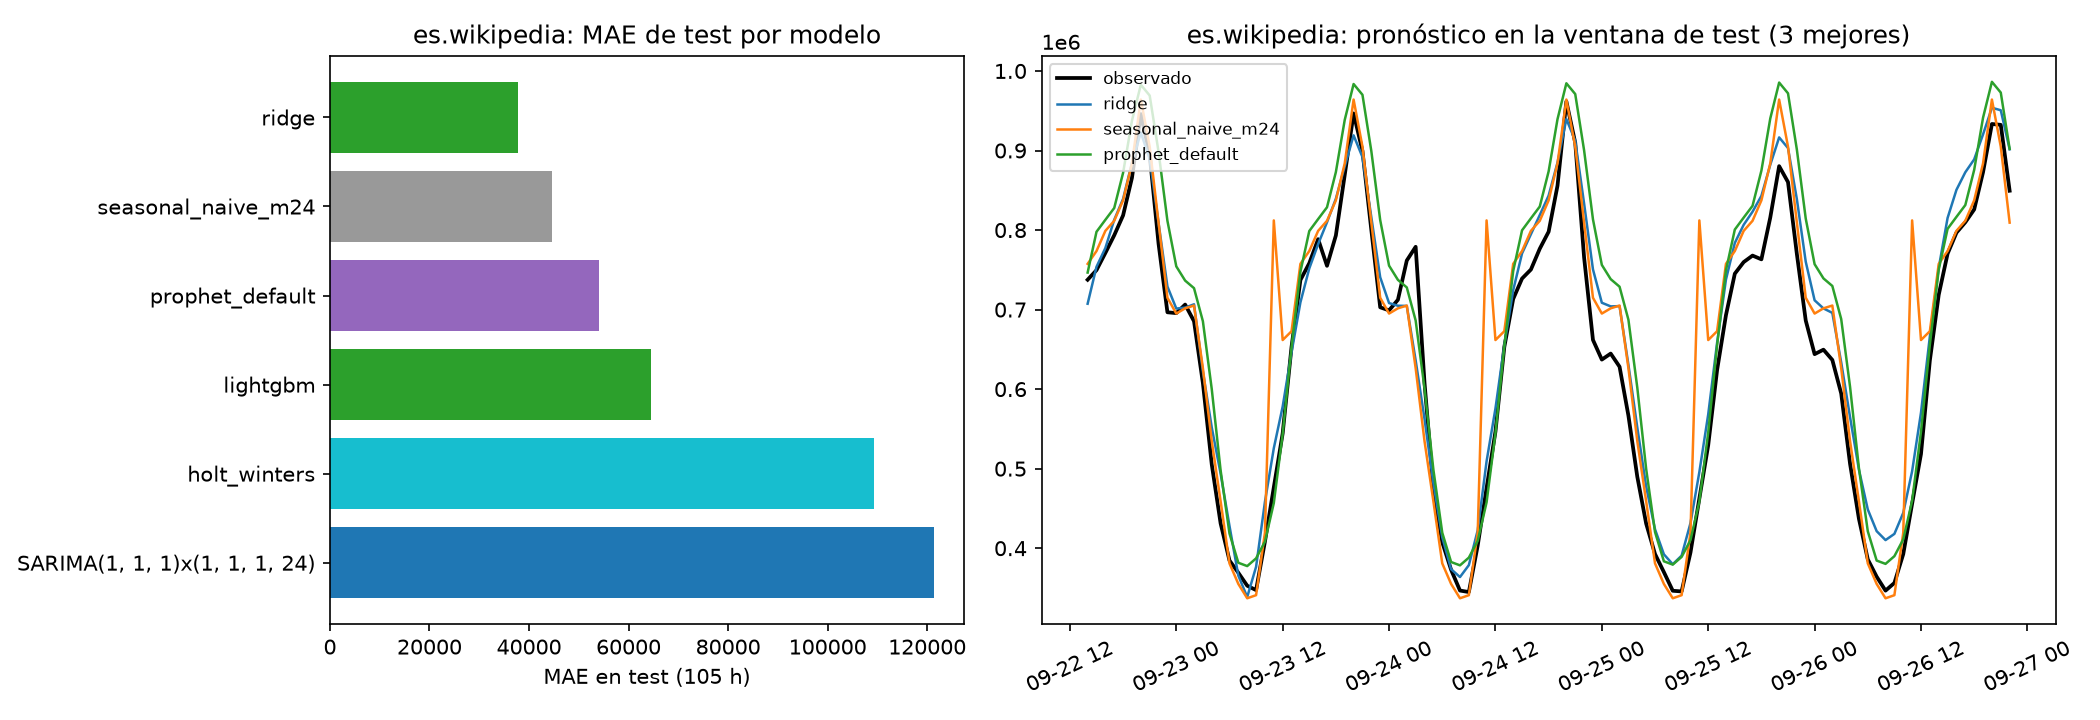

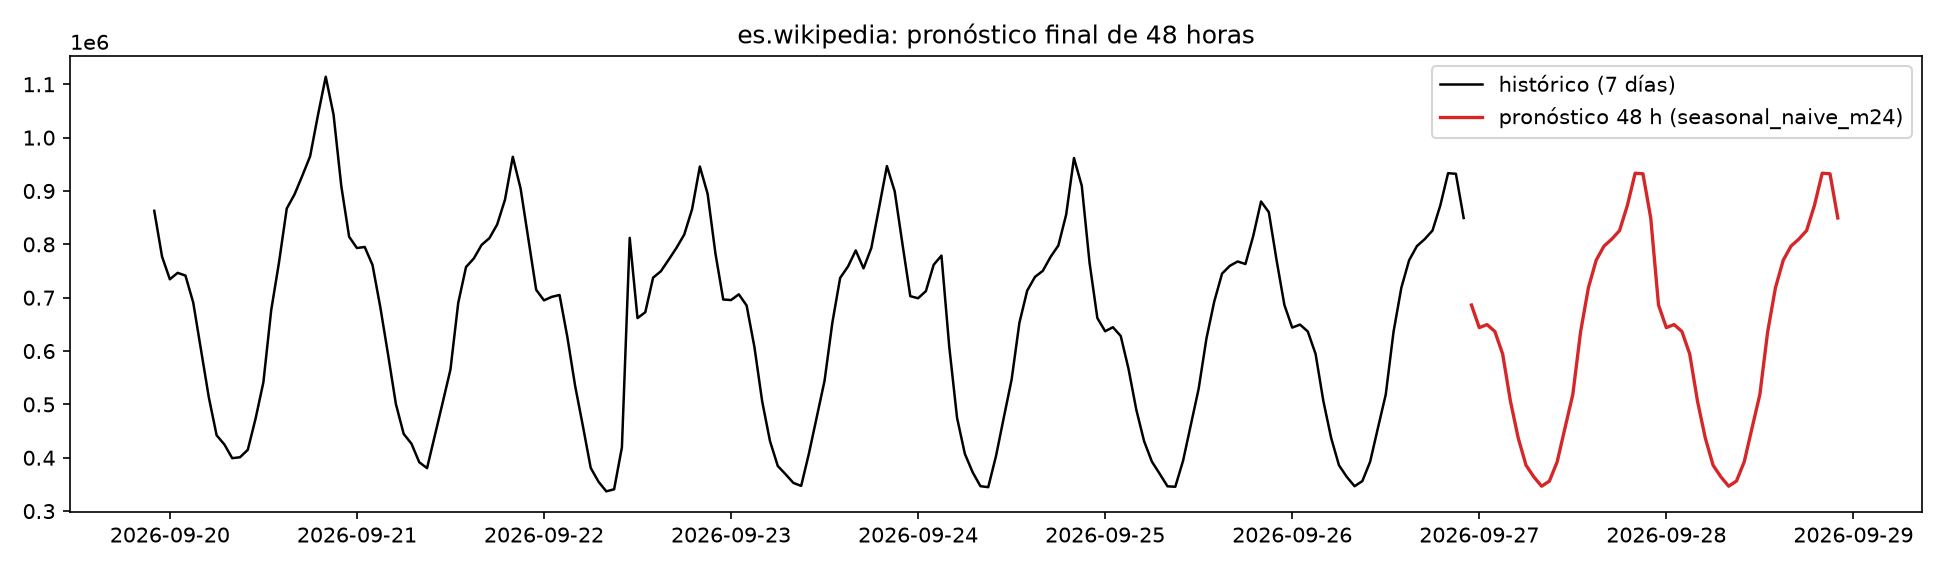

In [46]:
rank_val = res_wiki[res_wiki["split"] == "val"].sort_values("MAE").reset_index(drop=True)
rank_test = res_wiki[res_wiki["split"] == "test"].sort_values("MAE").reset_index(drop=True)
seleccionado_wiki = rank_val.loc[0, "model"]
print(f"Seleccionado por validación : {seleccionado_wiki} (MAE val {rank_val.loc[0, 'MAE']:,.0f})")
print(f"Mejor en test               : {rank_test.loc[0, 'model']} (MAE test {rank_test.loc[0, 'MAE']:,.0f})")
print(f"Peor en test                : {rank_test.iloc[-1]['model']} (MAE test {rank_test.iloc[-1]['MAE']:,.0f})")

unidos = rank_val[["model", "MAE"]].merge(rank_test[["model", "MAE"]], on="model", suffixes=("_val", "_test"))
rho_wiki = unidos["MAE_val"].rank().corr(unidos["MAE_test"].rank())
print(f"Correlación de Spearman entre rankings val y test (6 modelos): {rho_wiki:.2f}")

horizonte_wiki = 48
if REENTRENAR or not ARCHIVO_PRONOSTICO_07.exists():
    ajuste_por_nombre = {nombre: ajuste for nombre, _, ajuste in modelos_wiki}
    indice_futuro = pd.date_range(wiki.index[-1] + pd.Timedelta(hours=1), periods=horizonte_wiki, freq="h", tz="UTC")
    pron_wiki = pd.DataFrame({
        "timestamp": indice_futuro,
        "series": NOMBRE_WIKI,
        "role": "selected",
        "model": seleccionado_wiki,
        "yhat": ajuste_por_nombre[seleccionado_wiki](wiki)(horizonte_wiki),
    })
    pron_wiki.to_csv(ARCHIVO_PRONOSTICO_07, index=False)
else:
    pron_wiki = pd.read_csv(ARCHIVO_PRONOSTICO_07, parse_dates=["timestamp"])
print(f"\nPronóstico final: {len(pron_wiki)} h desde {pron_wiki['timestamp'].iloc[0]} hasta {pron_wiki['timestamp'].iloc[-1]}")

# Figuras del informe (solo lectura, como en la Sección 2.3): MAE de test y pronóstico en test de los 3 mejores,
# y pronóstico final de 48 h.
from IPython.display import Image, display

for archivo_figura in ["07_wikipedia_test.png", "07_wikipedia_forecast.png"]:
    ruta_figura = RUTA_FIGURAS_INFORME / archivo_figura
    if ruta_figura.exists():
        display(Image(filename=str(ruta_figura)))
    else:
        print(f"(figura no encontrada: {ruta_figura})")

assert len(wiki) == 2063
assert len(res_wiki) == len(modelos_wiki) * 2
assert len(pron_wiki) == horizonte_wiki and pron_wiki["yhat"].notna().all()


## 3.4 Comparación de los seis modelos comunes en las tres series

La tabla reúne el MASE de validación y de test de los seis modelos que se ejecutaron sobre las tres series (para `alb` y `store_service` se toman de `results/06_all_models.csv`, la batería completa de 32 configuraciones; para `wikipedia_es`, de los resultados de la sección 3.2). El SARIMA usa la especificación de ALB en `alb` y en `wikipedia_es`, y la del servicio POS API del TP1 en `store_service`. Es una lectura descriptiva: no se recalcula ninguna serie.


In [47]:
pool_06 = pd.read_csv(RUTA_RESULTADOS / "06_all_models.csv")
MODELOS_COMUNES = ["seasonal_naive_m24", "prophet_default", "lightgbm", "SARIMA (TP1 refit)", "ridge", "holt_winters"]


def mase_comun(df, modelo, ventana):
    if modelo == "SARIMA (TP1 refit)":
        filas = df[df["family"] == "SARIMA (TP1 refit)"]
    else:
        filas = df[df["model"] == modelo]
    return float(filas[filas["split"] == ventana]["MASE"].iloc[0])


comparacion_tres = {}
for serie, df_serie in [
    ("alb", pool_06[pool_06["series"] == "alb"]),
    ("store_service", pool_06[pool_06["series"] == "store_service"]),
    (NOMBRE_WIKI, res_wiki),
]:
    for ventana in ("val", "test"):
        comparacion_tres[(serie, ventana)] = {m: mase_comun(df_serie, m, ventana) for m in MODELOS_COMUNES}

tabla_tres = pd.DataFrame(comparacion_tres).loc[MODELOS_COMUNES]
print("MASE (menor es mejor)")
print(tabla_tres.round(3).to_string())
print("\nMejor modelo por columna:")
print(tabla_tres.idxmin().to_string())


MASE (menor es mejor)
                      alb        store_service        wikipedia_es       
                      val   test           val   test          val   test
seasonal_naive_m24  0.489  1.990         0.480  1.443        0.438  0.924
prophet_default     0.532  2.065         0.506  1.083        0.655  1.119
lightgbm            0.609  2.261         1.423  1.501        0.727  1.338
SARIMA (TP1 refit)  0.923  1.526         0.647  1.426        1.023  2.513
ridge               0.913  1.704         1.201  2.189        1.351  0.784
holt_winters        0.798  2.094         1.439  1.665        1.143  2.264

Mejor modelo por columna:
alb            val     seasonal_naive_m24
               test    SARIMA (TP1 refit)
store_service  val     seasonal_naive_m24
               test       prophet_default
wikipedia_es   val     seasonal_naive_m24
               test                 ridge


### Conclusiones de la sección 3

Por la regla de selección adoptada, el modelo seleccionado es la referencia estacional ingenua (`seasonal_naive_m24`, MAE de validación 21.146,77; MASE 0,438), seguida por Prophet (0,655) y LightGBM (0,727). En test, en cambio, el mejor modelo es `ridge` (MASE 0,784), la referencia ingenua queda segunda (0,924) y el SARIMA del TP1 es el peor (MASE 2,513), precedido por Holt-Winters (2,264). La correlación de Spearman entre ambos rankings, sobre solo seis modelos, es 0,09: el desacuerdo validación/test de las series de BodegaAI se repite y, con una sola ventana de cada tipo, no permite declarar un ganador firme.

El contraste principal es que el SARIMA del TP1 fue el mejor modelo de test en ALB (MASE 1,526) y es el peor en Wikipedia: el desempeño relativo del enfoque clásico depende de la serie. Holt-Winters y SARIMA, que solo usan estacionalidad de período 24, ocupan los últimos lugares, mientras que `ridge` usa rezagos de hasta 336 h y calendario y Prophet incluye por defecto un componente semanal; es una explicación plausible, **no contrastada en este trabajo**. Entre los seis modelos comunes a las tres series (sección 3.4), la referencia estacional ingenua tiene el menor MASE de validación en todas, pero ningún modelo es el mejor en test en más de una serie (SARIMA en ALB, Prophet en store_service y Ridge en Wikipedia). Límites: seis modelos sin ajuste de hiperparámetros, SARIMA con la especificación de ALB, una sola ventana de validación de 48 h y una de test de 105 h, y pronóstico final sin intervalos de predicción. Ridge y LightGBM reciben como variable exógena la marca de intervención del despliegue, que vale 1 entre el 17 y el 22 de septiembre aunque esta serie no fue afectada; con la marca en cero, el MASE de prueba de Ridge pasa de 0,784 a 0,756 y el de LightGBM no cambia, sin alterar el orden de los modelos ni el de validación.


# 4. Conclusiones generales y limitaciones

## Síntesis por serie

**ALB**: el modelo seleccionado (`auto_arima`, MASE de validación 0,475) le gana al refit SARIMA de TP1 en validación por 48,5%, pero pierde contra él en test por 34,9% -- el SARIMA fundacional de TP1 termina siendo el mejor de los 32 modelos evaluados en la ventana de test real. **store_service**: el modelo seleccionado es la propia `seasonal_naive_m24` -- ningún modelo ML, DL, Prophet, AutoML o de fundación logró bajarle el MAE de validación de forma no contaminada; en test, NeuralProphet gana (MASE 1,071) a pesar de haber sido el 14° de 32 en validación, evidencia de que el modelo que hubiera elegido la regla honesta no es el mejor en test, pero tampoco había forma de saberlo sin ver el futuro. **wikipedia_es** (serie pública, Sección 3, seis modelos sin ajuste de hiperparámetros): la regla de validación elige `seasonal_naive_m24`, pero en test gana `ridge` (MASE 0,784) y el SARIMA del TP1 es el peor (2,513): el desempeño relativo del enfoque clásico depende de la serie (mejor en ALB, peor en Wikipedia).

## Consistencia entre validación y test

La correlación de Spearman entre el ranking de validación y el de test es baja y no significativa en ALB ($\rho=0.237$, $p=0.192$, sobre 32 modelos) y moderada y significativa en store_service ($\rho=0.654$, $p<0.001$). En ambas series, y en cada fase desde la 02, el modelo que gana en la ventana de validación de 48 h no es necesariamente el que mejor pronostica la ventana de test de 105 h -- la conclusión transversal más consistente de todo el proyecto es que el enfoque clásico de TP1 (SARIMA) no fue superado de forma confiable por los modelos de ML/DL/AutoML/fundación más sofisticados de las fases 03 a 05, bajo el único criterio honesto disponible para elegir un modelo sin conocer el futuro.

## Límites del trabajo

1. Una sola ventana de validación de 48 h (no *backtesting* expansivo de múltiples ventanas), decidida por presupuesto de tiempo frente a ~15-32 modelos por serie, varios de ellos costosos de entrenar (fase 02, `status/02-evaluation-baselines.md`) -- la causa principal de la divergencia validación/test documentada en cada fase.
2. Historia acotada: ~86 días de régimen estable (2.063 observaciones horarias por serie), insuficiente para estimar estacionalidad anual y limitante para arquitecturas DL de mayor capacidad.
3. Existen modelos con validación contaminada (tuneados o seleccionados sobre la misma ventana de validación); se muestran en las tablas completas pero se excluyen de la regla de selección, nunca al revés.
4. Posible anomalía sin verificar en las últimas horas observadas de `store_service` (20:00-22:00 UTC del 2026-09-26); no se investigó en profundidad si se trata de un artefacto de exportación de datos o de una señal real.
5. La estacionalidad semanal (periodo 168), documentada como negligible en la fase 01, no se explotó como componente principal en ningún modelo -- una limitación conocida de TP1 que, con ~13 semanas de historia disponibles, podría revisarse con más datos.
6. La serie pública de Wikipedia (Sección 3) se evaluó como contraste acotado: seis modelos por defecto, sin DL, AutoML ni fundación, con el SARIMA de ALB, una ventana de validación de 48 h y una de test de 105 h; no es comparable uno a uno con las 32 configuraciones de las series de BodegaAI.

## Líneas de trabajo futuro

Validación cruzada de múltiples orígenes (*origin*) en el sentido de Hyndman & Athanasopoulos, en vez de un único corte, si el presupuesto de tiempo lo permite; extender la historia disponible más allá de los ~86 días actuales; y extender a la serie pública de Wikipedia (Sección 3) la batería completa de las fases 03 a 06.
